# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

## Integrantes
- Abagnale, Florencia
- Karlen, Paula
- Luna, Ana Maria
- Pintos, Mauricio José

## <font color=blue> Trabajo Práctico N° 3
## Aprendizaje Supervisado: Modelos de Clasificación

### Entregable (consigna)

1. Preparación de los datos para aplicar modelos de clasificación.
2. Creación de un modelo baseline.
3. Predicción de modelos lineales.
4. Predicción de modelos basados en árboles de decisión.
5. Ajuste por hiperparámetros.

Seguimos las reglas generales de la mentoría: después de cada gráfico o cálculo describimos qué hicimos y a qué conclusión llegamos (celdas **Comentario:**), dejamos solo los análisis relevantes y entregamos un notebook que corre de punta a punta en Colab o en local.

Partimos del dataset que dejó nuestro **TP2** (`dataset_curado_fraude.csv`: 192.516 transacciones, 716 clientes, 32 variables predictoras ya curadas y codificadas).

**Reproducibilidad y tiempo de ejecución:** los resultados son deterministas con `SEED = 42` y `XGB_JOBS = 2` fijos (XGBoost con `tree_method='hist'` cambia levemente con la cantidad de hilos, por eso la fijamos). Con otras versiones de las librerías (la primera celda imprime las usadas) los números pueden variar en el segundo o tercer decimal. El notebook tarda entre 12 y 14 minutos en una máquina de 12 núcleos; en Google Colab (2 vCPU) estimamos entre 25 y 35 minutos (no lo medimos), porque las búsquedas de hiperparámetros se paralelizan.

### Cómo está organizado

| Sección | Qué hacemos | Punto de la consigna |
|---|---|---|
| 1 | Carga, chequeos, set de variables, partición train/test, métricas | 1 |
| 2 | Baselines: modelos ingenuos y reglas de negocio | 2 |
| 3 | Regresión Logística (con y sin pesos de clase) | 3 |
| 4 | Árbol, árbol legible, Random Forest, Gradient Boosting, XGBoost | 4 |
| 5 | Hiperparámetros, técnicas de desbalance, umbral de decisión, ablación del PCA | 5 |
| 6 | Comparación final, elección del modelo, incertidumbre (bootstrap) | extra (rigor) |
| 7 | Lectura de negocio: segmentos, presupuesto de alertas, montos, costos | extra (rigor) |
| 8 | **¿Qué tan confiable es esta evaluación?** Partición por cliente y temporal | extra (rigor) |
| 9 | **Consideraciones éticas y de uso responsable**: equidad, costo humano de los errores, validez, privacidad, explicabilidad, model card | extra (rigor) |
| 10 | Conclusiones | |

## Resumen ejecutivo

- **Modelo elegido: XGBoost ajustado, con umbral 0,2661** elegido con predicciones out-of-fold del entrenamiento (sin mirar test). En la partición aleatoria 80/20 que pide la consigna logra **precision 0,7767, recall 0,6987, F1 0,7357** (IC 95% [0,690, 0,779]) y **AUC-PR 0,8011** (IC [0,754, 0,845]). Para comparar: la mejor regla de negocio ("dólares y e-commerce", elegida con el F1 en train) tiene F1 0,2894, la regresión logística ajustada 0,4974 y el Random Forest ajustado 0,664. XGBoost le gana al Random Forest en AUC-PR out-of-fold en train (0,7719 contra 0,6683; diferencia de 0,1036 con IC 95% por cliente [0,0715, 0,1393]), que es lo que decide la elección, y también en test (bootstrap pareado, solo como reporte); la comparación es con el presupuesto de búsqueda que usamos (8 configuraciones para el Random Forest y 10 para XGBoost).
- **Lectura de negocio:** si el equipo solo puede revisar el 1% de las transacciones con mayor score (386 alertas sobre 38.504), se detecta el **84,52% de los fraudes**. Funciona mejor en dólares (F1 0,837) y e-commerce (0,785), y peor en operaciones presenciales (0,444, con solo 34 fraudes). En dinero, el modelo detecta el 59,3% del monto defraudado en pesos y el 64,9% en dólares (reportados por separado).
- **Desbalance:** ni los pesos de clase ni SMOTE mejoran la calidad del ranking (AUC-PR de XGBoost entre 0,739 y 0,7479); lo que cambian es el punto de operación. El submuestreo empeora (0,5634). Con el **umbral** (0,2661 en vez de 0,5) el F1 pasa de 0,7255 a 0,7357: una mejora chica, pero lograda sin tocar el entrenamiento.
- **Cuidado con el número:** con una partición **por cliente** el F1 baja a 0,357 (contra 0,739 con 5 folds aleatorios) y el AUC-PR a 0,291; con una partición **temporal** (entrenar ene-ago, evaluar nov-dic) el F1 es 0,102 y el AUC-PR 0,238, y el F1 queda por debajo del de la regla de negocio (0,331). Son dos causas distintas. En la partición por cliente la causa principal es que el modelo reconoce clientes (sus fraudes vienen en ráfagas de un día): sin las variables del cliente, el F1 aleatorio baja de 0,739 a 0,340. La caída temporal, en cambio, no se explica por esas variables (sacarlas no la mejora): el entrenamiento ene-ago tiene solo 61 fraudes, y con un solo año no podemos decir si el fraude cambió o si la muestra se armó así (sección 8.4).
- **Uso responsable (sección 9):** el modelo tiene que **priorizar alertas para revisión humana, no bloquear**: con la tasa de fraude de la muestra 1 de cada 4,5 alertas es una operación legítima, y si el fraude real fuera 10 veces menos frecuente la precisión bajaría de 77,7% a 25,7%. En equidad, por edad el tramo 18–35 queda menos protegido (recall de 50,0%, con un intervalo muy ancho: [30,4–66,7]) y los tramos 36–50 y 66+ cargan con más falsas alarmas (FPR de 0,17% contra 0,05% en 18–35); por sexo, ninguna brecha supera el ruido.
- **Qué recomendamos:** el modelo sirve para **priorizar alertas** donde se concentra el riesgo (dólares, e-commerce), pero **no está listo para producción** sin más historia (el 71% del fraude de la muestra es de diciembre) y sin validación por cliente y por fecha. Las consideraciones éticas están en la sección 9 y los próximos pasos en la sección 10.

# 0. Librerías, configuración y carga de archivos

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
import textwrap
import matplotlib.colors as mcolors
import sklearn, xgboost, imblearn

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import (train_test_split, StratifiedKFold, StratifiedGroupKFold, GridSearchCV,
                                     RandomizedSearchCV, cross_val_predict, validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore', category=FutureWarning)   # avisos de deprecación de librerías; no afectan los resultados

SEED = 42                       # una sola semilla para todo el notebook
np.random.seed(SEED)
N_JOBS = os.cpu_count() or 2    # núcleos disponibles (en Colab suelen ser 2)
XGB_JOBS = 2                    # hilos de XGBoost: FIJOS (con tree_method='hist' el resultado cambia levemente con la cantidad de hilos; 2 es lo que tiene Colab)
T_INICIO = time.time()

# --- Paleta del proyecto (orden fijo) y estilo de gráficos ---
AZUL, NARANJA, AQUA, AMARILLO = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
MAGENTA, VERDE, VIOLETA, ROJO = '#e87ba4', '#008300', '#4a3aa7', '#e34948'
PALETA = [AZUL, NARANJA, AQUA, AMARILLO, MAGENTA, VERDE, VIOLETA, ROJO]
GRIS, GRIS_CLARO = '#6e6e6e', '#d9d9d9'
COLOR_METRICA = {'accuracy': '#a0a0a0', 'precision': AQUA, 'recall': AMARILLO, 'f1': VIOLETA}   # mismo color para la misma métrica en todo el notebook (azul y naranja quedan reservados para la clase)
# Un color fijo por modelo en todos los gráficos de modelos (se toman de la paleta en orden, saltando azul y naranja, que son de la clase)
COLOR_MODELO = {'Logística': AQUA, 'Árbol': AMARILLO, 'Random Forest': MAGENTA, 'HistGradientBoosting': VERDE, 'XGBoost': VIOLETA,
                'Regla': '#4d4d4d', 'Baseline': '#4d4d4d'}


def color_modelo(nombre):
    for clave, c in COLOR_MODELO.items():
        if clave in nombre:
            return c
    return GRIS


def etiqueta_corta(nombre):
    return nombre.replace('HistGradientBoosting', 'HistGB')


class RandomForestDeterminista(RandomForestClassifier):
    """RandomForestClassifier que predice con un solo hilo: con varios, el orden en que se suman los árboles cambia el último decimal
    y puede mover predicciones cuya probabilidad cae justo en el umbral. El entrenamiento sí usa todos los núcleos."""
    def predict_proba(self, X):
        n = self.n_jobs
        self.n_jobs = 1
        try:
            return super().predict_proba(X)
        finally:
            self.n_jobs = n

CMAP_DIVERGENTE = LinearSegmentedColormap.from_list('azul_gris_rojo', [AZUL, GRIS_CLARO, ROJO])

plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': 'white', 'font.size': 10.5,
    'axes.grid': True, 'grid.color': GRIS_CLARO, 'grid.alpha': 0.55, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#555555',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'axes.labelsize': 10.5,
    'axes.labelcolor': '#333333', 'text.color': '#222222', 'xtick.color': '#444444', 'ytick.color': '#444444',
    'legend.frameon': False, 'legend.fontsize': 9.5})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print(f"Núcleos disponibles: {N_JOBS} | hilos de XGBoost (fijos): {XGB_JOBS} | SEED = {SEED}")
print(f"Versiones: scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__} | imbalanced-learn {imblearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

Núcleos disponibles: 12 | hilos de XGBoost (fijos): 2 | SEED = 42
Versiones: scikit-learn 1.9.0 | xgboost 3.4.1 | imbalanced-learn 0.14.2 | pandas 2.3.2 | numpy 2.3.2


In [2]:
def ubicar_archivo(nombre, subcarpeta=None):
    """Devuelve la ruta de `nombre`: 1) directorio actual, 2) `subcarpeta/` si se indica, 3) subida manual (solo Colab)."""
    candidatos = [nombre] + ([os.path.join(subcarpeta, nombre)] if subcarpeta else [])
    for ruta in candidatos:
        if os.path.exists(ruta):
            return ruta
    try:
        from google.colab import files          # este módulo solo existe en Google Colab
    except ImportError:
        raise FileNotFoundError(f"No encontré '{nombre}' en {candidatos}. Copialo junto al notebook y volvé a correr la celda.")
    print(f"No encontré '{nombre}': subilo desde tu computadora. (Si los archivos pesados te cortan la subida, es más estable montar Drive "
          "con `from google.colab import drive; drive.mount('/content/drive')` y copiarlos al directorio actual.)")
    files.upload()
    if not os.path.exists(nombre):
        raise FileNotFoundError(f"No se subió '{nombre}'.")
    return nombre

# 1. Preparación de los datos para aplicar modelos de clasificación

Este notebook arranca donde terminó el TP2: el dataset ya está limpio (sin duplicados ni nulos), con las variables nuevas construidas **sin fuga temporal** (ventanas expansivas por cliente) y las categóricas codificadas con One-Hot. Lo que el TP2 dejó explícitamente para esta etapa, y por lo tanto nos toca resolver acá, es: **la partición en entrenamiento/evaluación, el escalado, el tratamiento del desbalance y los modelos**.

### 1.1 Carga y chequeos del dataset

In [3]:
ruta_csv = ubicar_archivo('dataset_curado_fraude.csv')
df = pd.read_csv(ruta_csv)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print("Tipos de dato al leer:", df.dtypes.astype(str).value_counts().to_dict())
print(f"Nulos totales: {int(df.isna().sum().sum())} | Filas duplicadas: {int(df.duplicated().sum())}")
print(f"Clientes distintos: {df['Cliente_Id'].nunique()}")
print("Valores del target:", sorted(df['Es_Fraude'].unique().tolist()))

# Las 9 dummies del One-Hot llegan como bool: las pasamos a int (0/1) para que todos los modelos las traten como numéricas.
cols_bool = df.select_dtypes(include='bool').columns.tolist()
df[cols_bool] = df[cols_bool].astype(int)
print(f"\nConvertimos {len(cols_bool)} columnas bool -> int. Tipos ahora:", df.dtypes.astype(str).value_counts().to_dict())

y = df['Es_Fraude'].astype(int)
X = df.drop(columns=['Cliente_Id', 'Es_Fraude'])        # Cliente_Id es un identificador: NO es una variable predictora
print(f"\nX: {X.shape[0]:,} filas x {X.shape[1]} variables predictoras | y: {y.shape[0]:,}")

balance = pd.DataFrame({'transacciones': y.value_counts().sort_index()})
balance['%'] = balance['transacciones'] / len(y) * 100
balance.index = ['No Fraude (0)', 'Fraude (1)']
print("\nBalance de clases:")
print(balance.to_string(formatters={'transacciones': '{:,.0f}'.format, '%': '{:.3f}'.format}))
print(f"\nPor cada fraude hay {(y == 0).sum() / (y == 1).sum():.0f} transacciones legítimas.")

Filas: 192,516 | Columnas: 34
Tipos de dato al leer: {'float64': 16, 'int64': 9, 'bool': 9}
Nulos totales: 0 | Filas duplicadas: 0
Clientes distintos: 716
Valores del target: [0, 1]

Convertimos 9 columnas bool -> int. Tipos ahora: {'int64': 18, 'float64': 16}

X: 192,516 filas x 32 variables predictoras | y: 192,516

Balance de clases:
              transacciones      %
No Fraude (0)       191,320 99.379
Fraude (1)            1,196  0.621

Por cada fraude hay 160 transacciones legítimas.


**Comentario:** el dataset llega tal como lo dejó el TP2: **192.516 filas y 34 columnas** (el identificador `Cliente_Id`, el target `Es_Fraude` y 32 variables predictoras), **sin nulos ni duplicados** y con **716 clientes**. Las 9 dummies del One-Hot venían como `bool` y las pasamos a `int` (quedan 18 columnas enteras y 16 decimales). Separamos `Cliente_Id` de las variables predictoras: es un identificador, y usarlo como feature le permitiría al modelo memorizar clientes en lugar de aprender patrones de fraude. Lo conservamos aparte porque lo vamos a necesitar en la sección 8.

El desbalance es el esperado: **1.196 fraudes contra 191.320 transacciones legítimas (0,621%)**, es decir, 160 legítimas por cada fraude.

### 1.2 Lo que más condiciona el problema: desbalance y `SIN_RUBRO`

Antes de entrenar nada conviene mirar dos hechos del dataset que van a condicionar cómo leemos *todas* las métricas: el desbalance extremo y el hecho de que las transacciones **sin rubro** (`Categoria_Rubro_SIN_RUBRO = 1`: retiros, transferencias, operaciones internas) no tienen ningún fraude.

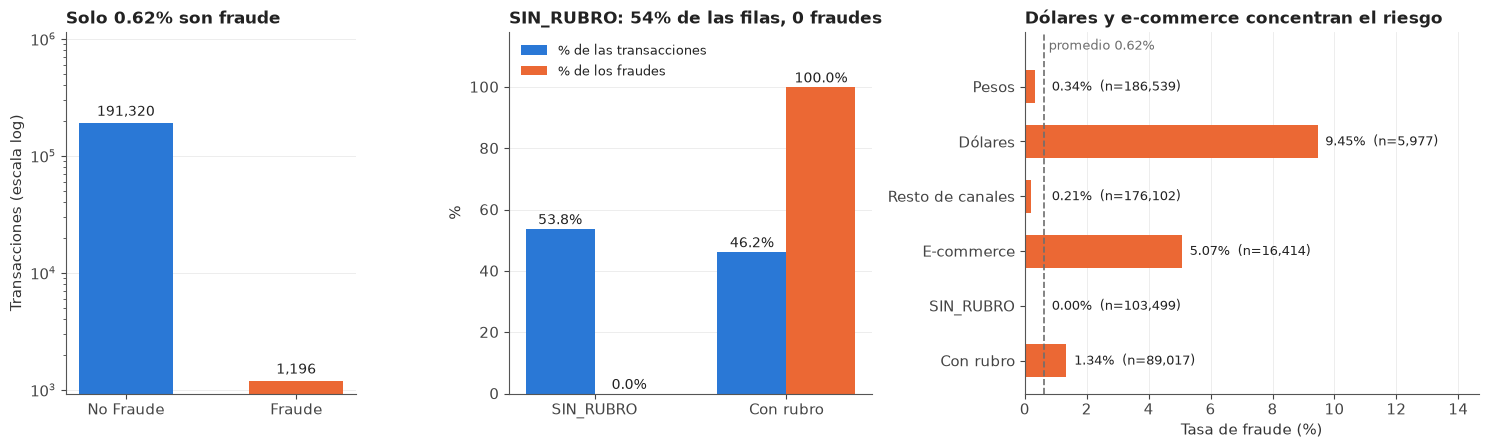

Fraudes en SIN_RUBRO: 0 de 103,499 filas | Tasa de fraude en el resto: 1.34% (1,196 de 89,017)
Pesos              0.3400
Dólares            9.4500
Resto de canales   0.2100
E-commerce         5.0700
SIN_RUBRO          0.0000
Con rubro          1.3400


In [4]:
col_sin_rubro = 'Categoria_Rubro_SIN_RUBRO'
col_ecom = 'TipoTerminal_Agrupamiento_Compras y E-commerce'
tasa_global = y.mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={'width_ratios': [0.8, 1, 1.25]})

# (A) desbalance
ax = axes[0]
cuentas = y.value_counts().sort_index()
ax.bar(['No Fraude', 'Fraude'], cuentas.values, color=[AZUL, NARANJA], width=0.55)
ax.set_yscale('log')
for i, v in enumerate(cuentas.values):
    ax.text(i, v * 1.15, f"{v:,}", ha='center', fontsize=10)
ax.set_ylim(top=cuentas.max() * 6)
ax.set_ylabel('Transacciones (escala log)')
ax.set_title(f'Solo {tasa_global:.2f}% son fraude')
ax.grid(axis='x', visible=False)

# (B) SIN_RUBRO: % de filas vs % de fraudes
ax = axes[1]
es_sr = X[col_sin_rubro] == 1
pct_filas = [es_sr.mean() * 100, (~es_sr).mean() * 100]
pct_fraude = [y[es_sr].sum() / y.sum() * 100, y[~es_sr].sum() / y.sum() * 100]
xx = np.arange(2); w = 0.36
b1 = ax.bar(xx - w / 2, pct_filas, w, color=AZUL, label='% de las transacciones')
b2 = ax.bar(xx + w / 2, pct_fraude, w, color=NARANJA, label='% de los fraudes')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{b.get_height():.1f}%", ha='center', fontsize=10)
ax.set_xticks(xx); ax.set_xticklabels(['SIN_RUBRO', 'Con rubro'])
ax.set_ylim(0, 118); ax.set_ylabel('%')
ax.set_title('SIN_RUBRO: 54% de las filas, 0 fraudes')
ax.legend(loc='upper left'); ax.grid(axis='x', visible=False)

# (C) tasa de fraude por segmento
ax = axes[2]
segmentos = {
    'Pesos': X['Trx_Moneda'] == 0, 'Dólares': X['Trx_Moneda'] == 1,
    'Resto de canales': X[col_ecom] == 0, 'E-commerce': X[col_ecom] == 1,
    'SIN_RUBRO': es_sr, 'Con rubro': ~es_sr}
tasas = pd.Series({k: y[m].mean() * 100 for k, m in segmentos.items()})
ns = pd.Series({k: int(m.sum()) for k, m in segmentos.items()})
pos = np.arange(len(tasas))[::-1]
ax.barh(pos, tasas.values, color=NARANJA, height=0.6)
ax.axvline(tasa_global, color=GRIS, ls='--', lw=1.2)
ax.text(tasa_global + 0.15, pos.max() + 0.62, f'promedio {tasa_global:.2f}%', color=GRIS, fontsize=9, va='bottom')
for p, (k, v) in zip(pos, tasas.items()):
    ax.text(max(v, tasa_global) + 0.25, p, f"{v:.2f}%  (n={ns[k]:,})", va='center', fontsize=9.5)
ax.set_yticks(pos); ax.set_yticklabels(tasas.index)
ax.set_xlim(0, tasas.max() * 1.55); ax.set_ylim(-0.6, pos.max() + 1.0)
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Dólares y e-commerce concentran el riesgo')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print(f"Fraudes en SIN_RUBRO: {int(y[es_sr].sum())} de {int(es_sr.sum()):,} filas | Tasa de fraude en el resto: {y[~es_sr].mean()*100:.2f}% ({int(y[~es_sr].sum()):,} de {int((~es_sr).sum()):,})")
print(tasas.round(2).to_string())

**Comentario:** los tres gráficos muestran lo que más va a condicionar la lectura de las métricas:

- **Desbalance** (izquierda): el 0,62% de fraude hace que el accuracy sea inútil y que cualquier modelo tenga que "encontrar una aguja en un pajar".
- **`SIN_RUBRO` no tiene ningún fraude** (centro): es el 53,8% de las transacciones pero el 0% de los fraudes. Todo el problema real vive en las 89.017 transacciones con rubro, donde la tasa de fraude sube a 1,34% (1.196 casos). Para un modelo, esas 103.499 filas son negativos triviales: **inflan la AUC-ROC** (la tasa de falsos positivos se diluye) pero no inflan igual el F1 ni la AUC-PR. Por eso la AUC-PR va a ser nuestra métrica principal.
- **El riesgo está concentrado** (derecha): las operaciones en **dólares** tienen una tasa de fraude de 9,45% (contra 0,34% en pesos) y las de **e-commerce** de 5,07% (contra 0,21% en el resto de los canales). Es el insumo de las reglas de negocio de la sección 2.

### 1.3 Dos sets de variables: ¿qué entra en cada familia de modelos?

El TP2 dejó 32 variables predictoras. Algunas son **versiones distintas de la misma información**:

- `Trx_Importe` y `Cliente_GastoPromedio` tienen una cola larguísima (importes de millones, mezclando pesos y dólares); el TP2 ya creó sus versiones `_log`, que comprimen la cola.
- `Cliente_DiaSemanaFavorito` y `Cliente_HoraFavorita` son números que en realidad son *cíclicos* (el domingo está pegado al lunes; las 23 hs a las 0 hs); el TP2 ya las codificó como seno/coseno.

Para los **modelos lineales** conservar las dos versiones es un problema: los coeficientes se reparten de forma inestable entre variables que dicen lo mismo (colinealidad) y las versiones crudas distorsionan el ajuste (cola larga, ciclicidad tratada como una recta). Para los **árboles** no molesta: sus cortes solo dependen del orden de los valores, así que una transformación monótona como el log no cambia nada, y pueden usar todo. Por eso armamos dos sets.

,variable cruda (solo árboles),versión que usan los lineales,asimetría cruda,asimetría versión,Spearman entre ambas,valores distintos (cruda),valores distintos (versión)
0,Trx_Importe,Trx_Importe_log,35.4660,-1.6430,1.0000,46409,46409
1,Cliente_GastoPromedio,Cliente_GastoPromedio_log,6.0710,-2.0040,1.0000,190767,190767
2,Cliente_DiaSemanaFavorito,Cliente_DiaFav_sin / _cos,NaN,NaN,NaN,7,7
3,Cliente_HoraFavorita,Cliente_HoraFav_sin / _cos,NaN,NaN,NaN,24,24



features_arboles: 32 variables | features_lineales: 28 variables


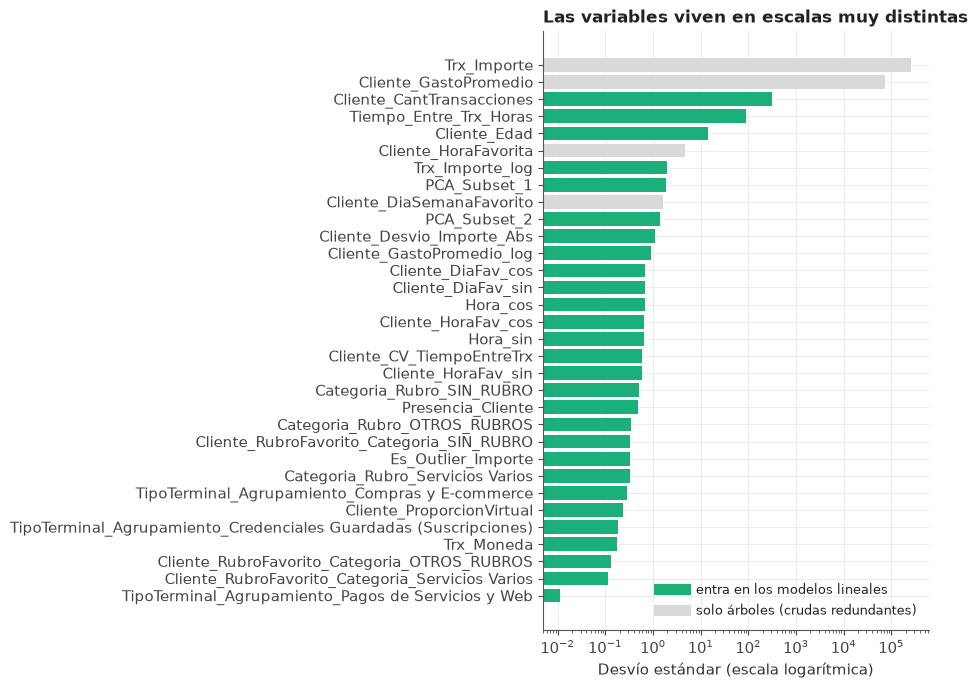

Desvío estándar mínimo: 0.011 (TipoTerminal_Agrupamiento_Pagos de Servicios y Web) | máximo: 258,986 (Trx_Importe)


In [5]:
redundancias = pd.DataFrame([
    ('Trx_Importe',               'Trx_Importe_log',           X['Trx_Importe'].skew(),               X['Trx_Importe_log'].skew(),
     X['Trx_Importe'].corr(X['Trx_Importe_log'], method='spearman')),
    ('Cliente_GastoPromedio',     'Cliente_GastoPromedio_log', X['Cliente_GastoPromedio'].skew(),     X['Cliente_GastoPromedio_log'].skew(),
     X['Cliente_GastoPromedio'].corr(X['Cliente_GastoPromedio_log'], method='spearman')),
    ('Cliente_DiaSemanaFavorito', 'Cliente_DiaFav_sin / _cos', np.nan, np.nan, np.nan),
    ('Cliente_HoraFavorita',      'Cliente_HoraFav_sin / _cos', np.nan, np.nan, np.nan)],
    columns=['variable cruda (solo árboles)', 'versión que usan los lineales', 'asimetría cruda', 'asimetría versión', 'Spearman entre ambas'])
# para las cíclicas: la cruda y el par seno/coseno tienen exactamente la misma cantidad de valores distintos (misma información)
redundancias['valores distintos (cruda)'] = [X[c].nunique() for c in ['Trx_Importe', 'Cliente_GastoPromedio', 'Cliente_DiaSemanaFavorito', 'Cliente_HoraFavorita']]
redundancias['valores distintos (versión)'] = [
    X['Trx_Importe_log'].nunique(), X['Cliente_GastoPromedio_log'].nunique(),
    X[['Cliente_DiaFav_sin', 'Cliente_DiaFav_cos']].drop_duplicates().shape[0],
    X[['Cliente_HoraFav_sin', 'Cliente_HoraFav_cos']].drop_duplicates().shape[0]]
display(redundancias.round(3))

features_arboles = X.columns.tolist()                                                  # los árboles usan todo
crudos_redundantes = ['Trx_Importe', 'Cliente_GastoPromedio', 'Cliente_DiaSemanaFavorito', 'Cliente_HoraFavorita']
features_lineales = [c for c in features_arboles if c not in crudos_redundantes]       # los lineales, sin los crudos redundantes
print(f"\nfeatures_arboles: {len(features_arboles)} variables | features_lineales: {len(features_lineales)} variables")

# Escalas muy distintas entre variables: la razón por la que los modelos lineales siempre van con escalado
desvios = X[features_arboles].std().sort_values()
fig, ax = plt.subplots(figsize=(9.5, 7))
colores = [color_modelo('Logística') if c in features_lineales else GRIS_CLARO for c in desvios.index]
ax.barh(desvios.index, desvios.values, color=colores)
ax.set_xscale('log')
ax.set_xlabel('Desvío estándar (escala logarítmica)')
ax.set_title('Las variables viven en escalas muy distintas')
ax.legend(handles=[Line2D([0], [0], color=color_modelo('Logística'), lw=8, label='entra en los modelos lineales'),
                   Line2D([0], [0], color=GRIS_CLARO, lw=8, label='solo árboles (crudas redundantes)')], loc='lower right')
plt.tight_layout(); plt.show()
print(f"Desvío estándar mínimo: {desvios.min():.3f} ({desvios.idxmin()}) | máximo: {desvios.max():,.0f} ({desvios.idxmax()})")

**Comentario:** la tabla confirma que las versiones `_log` son *la misma información* pero con otra forma: la correlación de Spearman con la variable cruda es 1,0 (el log no cambia el orden de los valores) y la asimetría baja de 35,47 a -1,64 en el importe y de 6,07 a -2,00 en el gasto promedio, es decir, la cola larguísima desaparece. Con las variables cíclicas pasa algo parecido: el día favorito (7 valores distintos) y la hora favorita (24 valores) tienen exactamente la misma cantidad de combinaciones únicas que su par seno/coseno, así que no hay información nueva en la versión cruda.

El gráfico muestra por qué el escalado es obligatorio para los modelos lineales: el desvío estándar va de 0,011 (`TipoTerminal_Agrupamiento_Pagos de Servicios y Web`) a 258.986 (`Trx_Importe`), una diferencia de siete órdenes de magnitud. Quedan así **`features_arboles` (32 variables) y `features_lineales` (28 variables)**.

### 1.4 Partición entrenamiento / evaluación

La consigna pide una partición clásica; usamos **80% entrenamiento / 20% evaluación, aleatoria y estratificada** por la variable objetivo (para que ambas partes mantengan la misma tasa de fraude) y con `random_state=SEED`. Es la partición que usamos para *comparar modelos* a lo largo de todo el notebook. (En la sección 8 vamos a medir cuánto de lo que ven estos números sobrevive cuando la partición se hace por cliente o por fecha.)

Los conjuntos conservan el **índice original del CSV**, lo que nos va a permitir más adelante cruzarlos con la fecha y el cliente de cada transacción.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

resumen_split = pd.DataFrame({
    'filas': [len(X_train), len(X_test)],
    'fraudes': [int(y_train.sum()), int(y_test.sum())],
    'tasa de fraude (%)': [y_train.mean() * 100, y_test.mean() * 100]}, index=['Entrenamiento (80%)', 'Evaluación (20%)'])
print(resumen_split.to_string(formatters={'filas': '{:,.0f}'.format, 'fraudes': '{:,.0f}'.format, 'tasa de fraude (%)': '{:.3f}'.format}))
print(f"\nClientes en train: {df.loc[X_train.index, 'Cliente_Id'].nunique()} | clientes en test: {df.loc[X_test.index, 'Cliente_Id'].nunique()} | clientes en ambos: {len(set(df.loc[X_train.index, 'Cliente_Id']) & set(df.loc[X_test.index, 'Cliente_Id']))}")
print("Índices originales conservados:", X_train.index[:5].tolist(), "...")
ratio_desb = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Cociente legítimas/fraudes en train: {ratio_desb:.1f}")

                      filas fraudes tasa de fraude (%)
Entrenamiento (80%) 154,012     957              0.621
Evaluación (20%)     38,504     239              0.621

Clientes en train: 716 | clientes en test: 699 | clientes en ambos: 699
Índices originales conservados: [126132, 178414, 170574, 103561, 191269] ...
Cociente legítimas/fraudes en train: 159.9


**Comentario:** la partición deja **154.012 transacciones para entrenar (957 fraudes) y 38.504 para evaluar (239 fraudes)**, con la misma tasa de fraude (0,621%) en ambos lados gracias a la estratificación. Dos datos para tener presentes: (1) el conjunto de evaluación tiene apenas 239 casos positivos, así que cualquier métrica de fraude va a tener bastante ruido (lo cuantificamos en la sección 6.3); (2) **los 699 clientes del test también están en el entrenamiento**: la partición aleatoria reparte las transacciones de un mismo cliente entre ambos conjuntos. Eso es lo que la consigna pide y lo usamos para comparar modelos, pero en la sección 8 vamos a ver qué implica.

### 1.5 Escalado dentro de un `Pipeline` y una advertencia heredada del TP2

**Escalado.** Los modelos lineales (y todo lo que usa distancias, como SMOTE) necesitan variables en escalas comparables. Pero escalar *antes* de dividir en folds de validación cruzada es una fuga sutil: la media y el desvío de cada fold de validación habrían influido en el escalado con el que se lo evalúa. Por eso **el `StandardScaler` va siempre dentro de un `Pipeline`**: se ajusta solo con los datos de entrenamiento (o solo con los folds de entrenamiento durante la validación cruzada) y recién después se aplica a validación/test.

**Advertencia sobre el PCA del TP2.** El `StandardScaler` + `PCA` que generaron `PCA_Subset_1` y `PCA_Subset_2` se ajustaron sobre el dataset **completo**, antes de cualquier partición. Es una técnica no supervisada (no mira `Es_Fraude`), así que no es fuga del target, pero sí es *transductiva*: los componentes "vieron" también las filas que ahora son de test. Además, el subconjunto de variables del PCA incluía el **mes** de la transacción (en dummies). Lo vamos a tratar con una **ablación** en la sección 5.6 (con y sin PCA) y a revisarlo de nuevo en la evaluación temporal de la sección 8.

### 1.6 Métricas: qué medimos y por qué

Con 0,62% de fraude, **el accuracy no sirve**: un modelo que diga siempre "no es fraude" acierta el 99,4% de las veces y no detecta nada. Para cada modelo reportamos, sobre la clase *Fraude*:

- **Precision**: de lo que el modelo marca como fraude, ¿cuánto lo es realmente? (cuántas falsas alarmas genera, es decir, a cuántos clientes legítimos molestamos).
- **Recall**: de los fraudes reales, ¿cuántos detecta? (cuánto fraude deja pasar).
- **F1**: media armónica de ambas; resume el equilibrio en un solo número *para un umbral de decisión dado*.
- **AUC-PR** (área bajo la curva precision-recall, `average_precision`): evalúa el *ranking* de los scores en todos los umbrales posibles. **Es nuestra métrica principal**: no depende del umbral y es sensible a lo que importa acá (encontrar los pocos fraudes). Su "piso" es la tasa de fraude (0,6%), no 0,5.
- **AUC-ROC**: la reportamos por completitud, pero hay que leerla con cuidado. Como el 54% de las transacciones (`SIN_RUBRO`) son negativos triviales, la tasa de falsos positivos se diluye y la AUC-ROC sale altísima aun con modelos mediocres.
- **Matriz de confusión**: para ver los cuatro tipos de resultado en cantidades concretas.

Todas las funciones de abajo evalúan **siempre sobre `y_test`** y guardan lo que calculan en el diccionario `resultados`, que usamos para la tabla comparativa final.

In [7]:
resultados = {}     # nombre -> métricas sobre TEST (alimenta la tabla comparativa de la sección 6)
scores_test = {}    # nombre -> score continuo sobre TEST (curvas PR/ROC y bootstrap)
preds_test = {}     # nombre -> predicción binaria sobre TEST
info_train = {}     # nombre -> métricas sobre TRAIN (para mostrar sobreajuste)

def calcular_metricas(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'auc_roc': roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
            'auc_pr': average_precision_score(y_true, y_score) if y_score is not None else np.nan,
            'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)}

def registrar(nombre, y_pred, y_score=None, umbral=None, grupo=''):
    """Calcula las métricas sobre y_test y las guarda en `resultados`."""
    y_pred = np.asarray(y_pred).astype(int)
    m = calcular_metricas(y_test, y_pred, y_score)
    m['umbral'] = umbral
    m['grupo'] = grupo
    resultados[nombre] = m
    preds_test[nombre] = y_pred
    if y_score is not None:
        scores_test[nombre] = np.asarray(y_score)
    return m

def registrar_train(nombre, y_pred_tr, y_score_tr):
    info_train[nombre] = {'f1': f1_score(y_train, y_pred_tr, zero_division=0),
                          'auc_pr': average_precision_score(y_train, y_score_tr)}

def reportar(nombre):
    m = resultados[nombre]
    umbral = f" | umbral {m['umbral']:.3f}" if m.get('umbral') is not None else ""
    auc = f" | AUC-PR {m['auc_pr']:.4f} | AUC-ROC {m['auc_roc']:.4f}" if not np.isnan(m['auc_pr']) else ""
    print(f"{nombre}{umbral}\n   accuracy {m['accuracy']:.4f} (engañosa) | precision {m['precision']:.4f} | recall {m['recall']:.4f} | F1 {m['f1']:.4f}{auc}"
          f"\n   verdaderos+ {m['tp']} | falsos+ {m['fp']:,} | falsos- {m['fn']} | verdaderos- {m['tn']:,}")

def graficar_matriz_confusion(ax, nombre, titulo=None):
    """Matriz de confusión: el color es el % de cada fila real (así los fraudes no quedan invisibles) y el texto es la cantidad."""
    m = resultados[nombre]
    cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    etiquetas = np.array([[f"{cm[i, j]:,}\n({pct[i, j]*100:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(pct, annot=etiquetas, fmt='', cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax, linewidths=2, linecolor='white',
                xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'], annot_kws={'size': 10})
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo or nombre, fontsize=10.5); ax.grid(False)

def umbral_optimo_f1(y_true, score):
    """Umbral que maximiza el F1 sobre un conjunto de predicciones. Usarlo SOLO con predicciones out-of-fold de train, nunca con test."""
    prec, rec, thr = precision_recall_curve(y_true, score)
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    i = int(np.argmax(f1))
    return float(thr[i]), float(f1[i])

# 2. Creación de un modelo baseline

Un baseline es el piso contra el cual medimos todo lo demás: si un modelo sofisticado no supera a una regla que cualquiera en el banco podría aplicar sin Machine Learning, no vale la pena su complejidad. Probamos dos tipos:

1. **Modelos ingenuos** (`DummyClassifier`): "siempre No Fraude" y "azar con las proporciones del train".
2. **Reglas de negocio** derivadas del EDA de los TP1 y TP2 (no se ajustan con datos, son criterios fijos): marcar como fraude toda transacción *en dólares*, toda *compra e-commerce*, *dólares o e-commerce*, y *dólares y e-commerce a la vez*.

In [8]:
# --- Modelos ingenuos ---
ingenuo = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
registrar('Baseline: siempre "No Fraude"', ingenuo.predict(X_test), grupo='Baseline')

azar = DummyClassifier(strategy='stratified', random_state=SEED).fit(X_train, y_train)
registrar('Baseline: azar estratificado', azar.predict(X_test), grupo='Baseline')

# --- Reglas de negocio (criterios fijos tomados del EDA, no entrenados). Son funciones de un DataFrame de variables ---
FUNC_REGLAS = {
    'Regla: en dólares': lambda D: D['Trx_Moneda'] == 1,
    'Regla: e-commerce': lambda D: D[col_ecom] == 1,
    'Regla: dólares o e-commerce': lambda D: (D['Trx_Moneda'] == 1) | (D[col_ecom] == 1),
    'Regla: dólares y e-commerce': lambda D: (D['Trx_Moneda'] == 1) & (D[col_ecom] == 1)}
for nombre, regla in FUNC_REGLAS.items():
    registrar(nombre, regla(X_test).astype(int), grupo='Baseline')

for nombre in resultados:
    reportar(nombre)
    print()

Baseline: siempre "No Fraude"
   accuracy 0.9938 (engañosa) | precision 0.0000 | recall 0.0000 | F1 0.0000
   verdaderos+ 0 | falsos+ 0 | falsos- 239 | verdaderos- 38,265

Baseline: azar estratificado
   accuracy 0.9877 (engañosa) | precision 0.0042 | recall 0.0042 | F1 0.0042
   verdaderos+ 1 | falsos+ 235 | falsos- 238 | verdaderos- 38,030

Regla: en dólares
   accuracy 0.9707 (engañosa) | precision 0.1089 | recall 0.5188 | F1 0.1800
   verdaderos+ 124 | falsos+ 1,015 | falsos- 115 | verdaderos- 37,250

Regla: e-commerce
   accuracy 0.9177 (engañosa) | precision 0.0512 | recall 0.6987 | F1 0.0954
   verdaderos+ 167 | falsos+ 3,096 | falsos- 72 | verdaderos- 35,169

Regla: dólares o e-commerce
   accuracy 0.8983 (engañosa) | precision 0.0519 | recall 0.8912 | F1 0.0981
   verdaderos+ 213 | falsos+ 3,889 | falsos- 26 | verdaderos- 34,376

Regla: dólares y e-commerce
   accuracy 0.9901 (engañosa) | precision 0.2600 | recall 0.3264 | F1 0.2894
   verdaderos+ 78 | falsos+ 222 | falsos- 16

,accuracy,precision,recall,f1,transacciones marcadas,% del total marcado
"Baseline: siempre ""No Fraude""",0.9938,0.0000,0.0000,0.0000,0,0.0000
Baseline: azar estratificado,0.9877,0.0042,0.0042,0.0042,236,0.6129
Regla: en dólares,0.9707,0.1089,0.5188,0.1800,1139,2.9581
Regla: e-commerce,0.9177,0.0512,0.6987,0.0954,3263,8.4744
Regla: dólares o e-commerce,0.8983,0.0519,0.8912,0.0981,4102,10.6534
Regla: dólares y e-commerce,0.9901,0.2600,0.3264,0.2894,300,0.7791


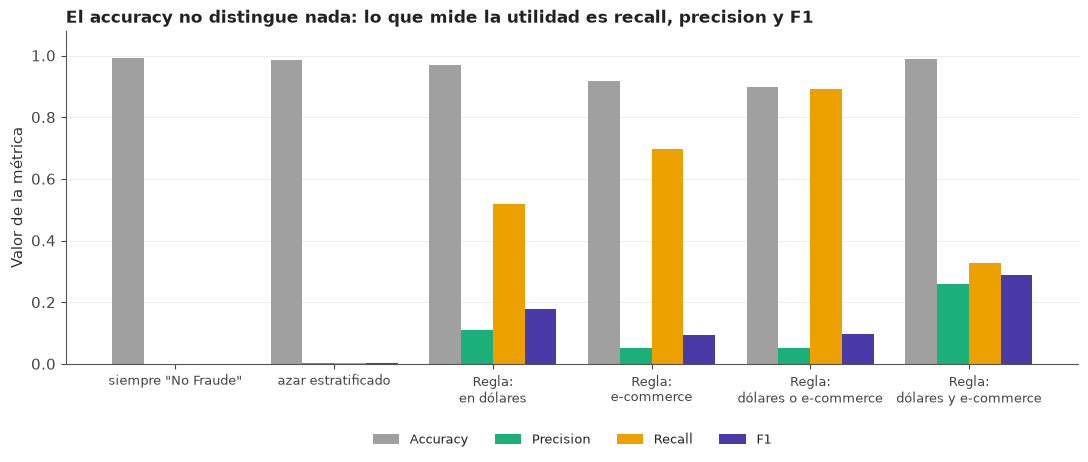

In [9]:
base = pd.DataFrame(resultados).T.loc[:, ['accuracy', 'precision', 'recall', 'f1']].astype(float)
base['transacciones marcadas'] = [int(preds_test[n].sum()) for n in base.index]
base['% del total marcado'] = base['transacciones marcadas'] / len(y_test) * 100
display(base.round(4))

fig, ax = plt.subplots(figsize=(11, 4.8))
nombres = base.index.tolist()
xx = np.arange(len(nombres)); w = 0.2
for i, met in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    ax.bar(xx + (i - 1.5) * w, base[met], w, color=COLOR_METRICA[met], label=met.capitalize() if met != 'f1' else 'F1')
ax.set_xticks(xx); ax.set_xticklabels([n.replace('Baseline: ', '').replace('Regla: ', 'Regla:\n') for n in nombres], fontsize=9)
ax.set_ylim(0, 1.08); ax.set_ylabel('Valor de la métrica')
ax.set_title('El accuracy no distingue nada: lo que mide la utilidad es recall, precision y F1')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.17))
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

**Comentario:** el baseline ingenuo ("siempre No Fraude") tiene un **accuracy de 0,9938** y, sin embargo, **recall 0 y F1 0**: no detecta ni un solo fraude. El azar estratificado llega apenas a un F1 de 0,0042. Es la mejor demostración de por qué el accuracy no sirve acá.

Las reglas de negocio ya hacen algo útil sin entrenar nada, pero muestran el dilema precision/recall en estado puro: "dólares o e-commerce" **detecta el 89,1% de los fraudes** (recall 0,8912) pero marca el 10,65% de todas las transacciones, así que su precision es de solo 0,0519 (3.889 falsas alarmas para 213 fraudes). En el otro extremo, "dólares y e-commerce" es la más precisa (precision 0,26) pero deja pasar dos tercios del fraude (recall 0,3264). La mejor regla por F1 es **"dólares y e-commerce" con F1 = 0,2894**: ese es el piso que cualquier modelo tiene que superar para justificar su existencia. (La elegimos con el F1 en **train**, entre cuatro reglas fijas que no se ajustan con datos; en la sección 6.2 se ve que es la misma que ganaría mirando el test, así que es una vara exigente y no está sesgada por haber mirado test.)

# 3. Predicción con modelos lineales

Usamos **Regresión Logística**: combina linealmente las variables y devuelve una probabilidad, lo que nos permite mover el umbral de decisión más adelante. Entrena sobre `features_lineales` (28 variables, sin las crudas redundantes) y **siempre dentro de un `Pipeline` con `StandardScaler`**.

Probamos dos versiones, para ver el efecto del desbalance sobre un modelo simple:

- **Sin pesos**: la regresión logística "pura", que aprende con las proporciones reales (0,6% fraude).
- **Balanceada** (`class_weight='balanced'`): cada fraude pesa ~160 veces más que una transacción legítima en la función de pérdida. Es la forma más simple de decirle al modelo "prestá más atención a la clase minoritaria".

En esta sección ambas usan el umbral por defecto (0,5); el ajuste del umbral llega en la sección 5.

Reg. Logística (sin pesos) | umbral 0.500
   accuracy 0.9943 (engañosa) | precision 0.6329 | recall 0.2092 | F1 0.3145 | AUC-PR 0.4595 | AUC-ROC 0.9831
   verdaderos+ 50 | falsos+ 29 | falsos- 189 | verdaderos- 38,236
   en entrenamiento: F1 0.2882 | AUC-PR 0.4386



Reg. Logística (balanceada) | umbral 0.500
   accuracy 0.9421 (engañosa) | precision 0.0919 | recall 0.9372 | F1 0.1674 | AUC-PR 0.4137 | AUC-ROC 0.9862
   verdaderos+ 224 | falsos+ 2,213 | falsos- 15 | verdaderos- 36,052
   en entrenamiento: F1 0.1664 | AUC-PR 0.3813



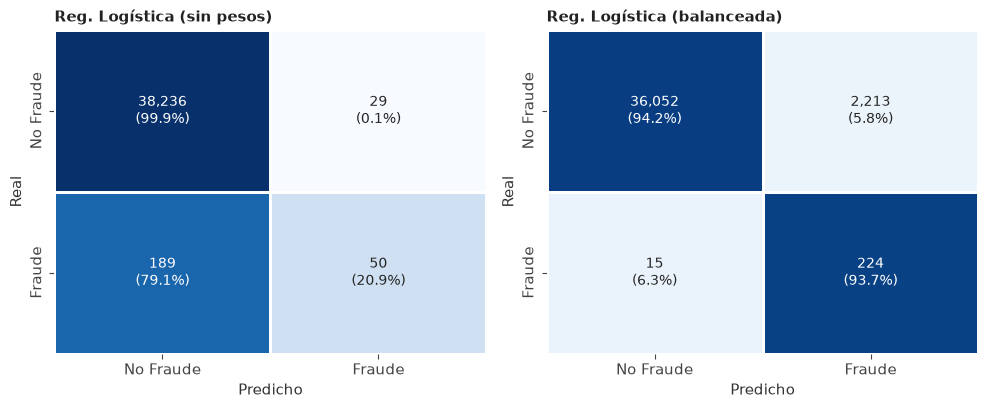

In [10]:
def armar_logreg(**kw):
    return Pipeline([('escalado', StandardScaler()), ('modelo', LogisticRegression(max_iter=2000, **kw))])

modelos_lineales = {'Reg. Logística (sin pesos)': armar_logreg(),
                    'Reg. Logística (balanceada)': armar_logreg(class_weight='balanced')}

for nombre, pipe in modelos_lineales.items():
    pipe.fit(X_train[features_lineales], y_train)
    s_te = pipe.predict_proba(X_test[features_lineales])[:, 1]
    s_tr = pipe.predict_proba(X_train[features_lineales])[:, 1]
    registrar(nombre, s_te >= 0.5, s_te, umbral=0.5, grupo='Lineal')
    registrar_train(nombre, s_tr >= 0.5, s_tr)
    reportar(nombre)
    print(f"   en entrenamiento: F1 {info_train[nombre]['f1']:.4f} | AUC-PR {info_train[nombre]['auc_pr']:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, nombre in zip(axes, modelos_lineales):
    graficar_matriz_confusion(ax, nombre)
plt.tight_layout(); plt.show()

**Comentario:** el mismo modelo con y sin pesos queda en dos puntos de operación opuestos. **Sin pesos** (umbral 0,5) es conservador: precision 0,6329 pero recall 0,2092 (detecta 50 de 239 fraudes), F1 = 0,3145. **Balanceada** invierte el trade-off: recall 0,9372 (224 de 239) pero precision 0,0919, con 2.213 falsas alarmas, F1 = 0,1674. El `class_weight='balanced'` no hizo al modelo "mejor": lo empujó a alertar mucho más (en la sección 5.4 vamos a ver que, midiendo el *ranking*, en realidad quedó un poco peor).

No hay sobreajuste: el F1 en entrenamiento (0,2882 y 0,1664) es parecido al de evaluación, como es esperable en un modelo simple. Pero la AUC-PR es modesta (0,4595 y 0,4137): la regresión logística ordena a los fraudes razonablemente bien, no los separa con claridad.

### 3.1 ¿Qué variables empujan hacia "fraude"?

Una ventaja de la regresión logística es que se puede leer. Como las variables están estandarizadas, los coeficientes son comparables: **rojo = empuja hacia Fraude, azul = empuja hacia No Fraude** (por cada desvío estándar de la variable). Hay que leerlos con cuidado: los componentes `PCA_Subset_1/2` son *combinaciones lineales de otras variables que también están en el modelo* (moneda, canal, rubro, importe, mes...), así que hay colinealidad por construcción y los coeficientes se reparten de forma poco interpretable. Para verlo, graficamos el modelo balanceado **con** los dos componentes PCA (28 variables) y **sin** ellos (26 variables).

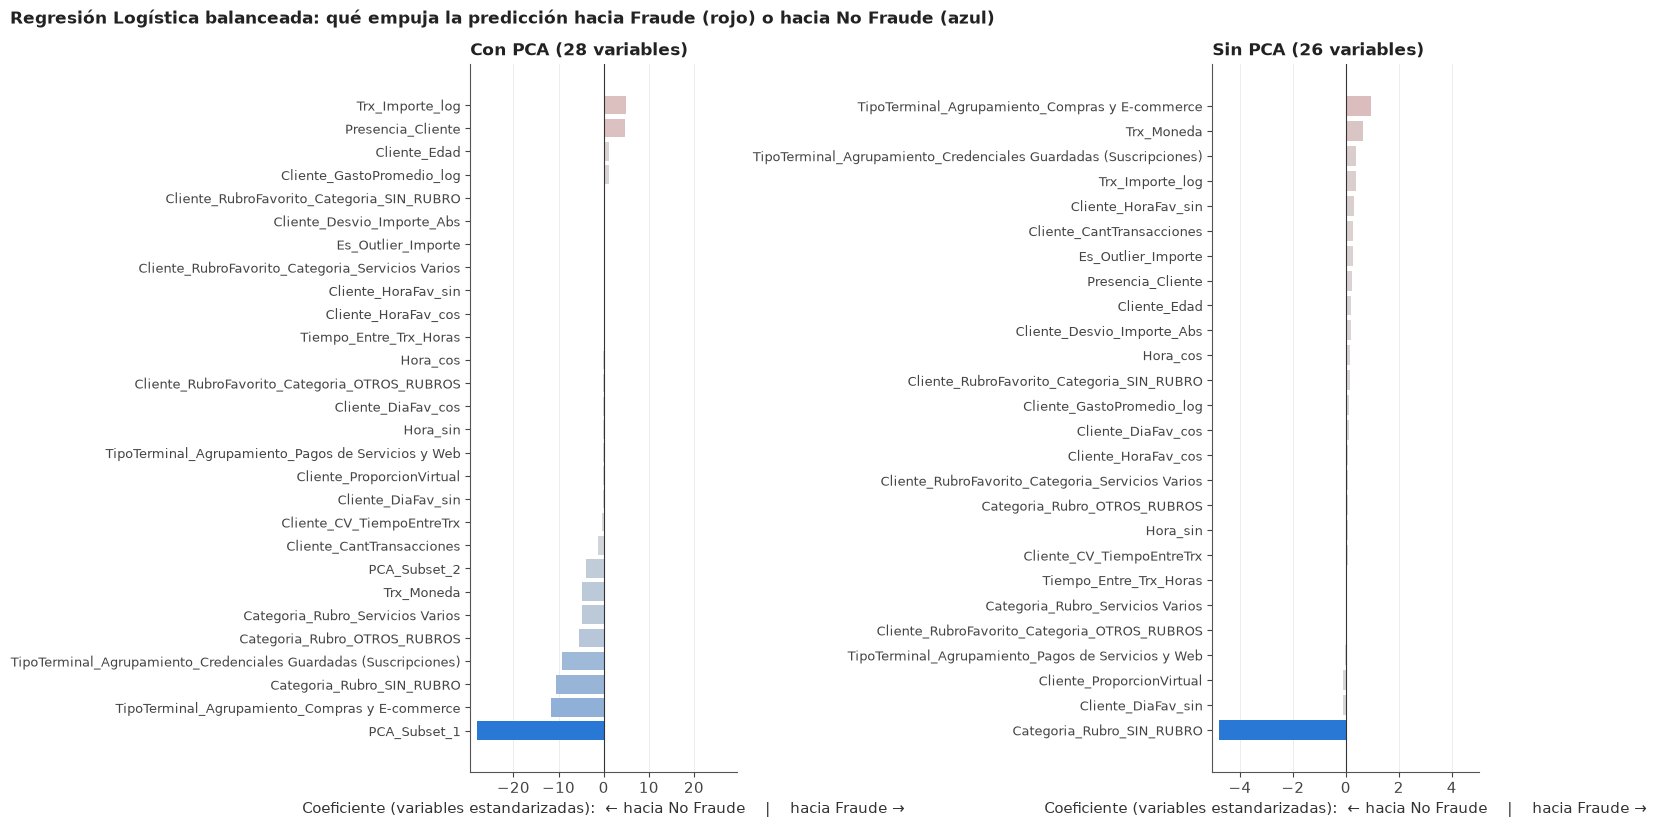

Los 6 coeficientes más grandes en valor absoluto, CON PCA:
PCA_Subset_1                                                       -28.1530
TipoTerminal_Agrupamiento_Compras y E-commerce                     -11.7680
Categoria_Rubro_SIN_RUBRO                                          -10.4950
TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)    -9.2870
Categoria_Rubro_OTROS_RUBROS                                        -5.4980
Trx_Importe_log                                                      4.8910

Los 6 coeficientes más grandes en valor absoluto, SIN PCA:
Categoria_Rubro_SIN_RUBRO                                          -4.7990
TipoTerminal_Agrupamiento_Compras y E-commerce                      0.9360
Trx_Moneda                                                          0.6500
TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)    0.3950
Trx_Importe_log                                                     0.3680
Cliente_HoraFav_sin                               

In [11]:
coef_con = pd.Series(modelos_lineales['Reg. Logística (balanceada)'].named_steps['modelo'].coef_[0], index=features_lineales)
feats_sin_pca = [c for c in features_lineales if not c.startswith('PCA_')]
lr_sin_pca = armar_logreg(class_weight='balanced').fit(X_train[feats_sin_pca], y_train)      # solo para interpretar (no entra en la comparación)
coef_sin = pd.Series(lr_sin_pca.named_steps['modelo'].coef_[0], index=feats_sin_pca)

fig, axes = plt.subplots(1, 2, figsize=(15, 8.4))
for ax, serie, titulo in zip(axes, [coef_con, coef_sin], [f'Con PCA ({len(coef_con)} variables)', f'Sin PCA ({len(coef_sin)} variables)']):
    serie = serie.sort_values()
    lim = float(np.abs(serie.values).max())
    ax.barh(serie.index, serie.values, color=[CMAP_DIVERGENTE((v / lim + 1) / 2) for v in serie.values])
    ax.axvline(0, color='#333333', lw=0.8)
    ax.set_xlim(-lim * 1.05, lim * 1.05)
    ax.set_title(titulo)
    ax.set_xlabel('Coeficiente (variables estandarizadas):  ← hacia No Fraude    |    hacia Fraude →')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', visible=False)
plt.suptitle('Regresión Logística balanceada: qué empuja la predicción hacia Fraude (rojo) o hacia No Fraude (azul)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("Los 6 coeficientes más grandes en valor absoluto, CON PCA:")
print(coef_con.reindex(coef_con.abs().sort_values(ascending=False).index).head(6).round(3).to_string())
print("\nLos 6 coeficientes más grandes en valor absoluto, SIN PCA:")
print(coef_sin.reindex(coef_sin.abs().sort_values(ascending=False).index).head(6).round(3).to_string())
print(f"\nDe referencia, AUC-PR en test del modelo sin PCA: {average_precision_score(y_test, lr_sin_pca.predict_proba(X_test[feats_sin_pca])[:, 1]):.4f} (con PCA: {resultados['Reg. Logística (balanceada)']['auc_pr']:.4f})")

**Comentario:** el gráfico de la izquierda (con PCA) es un buen ejemplo de por qué hay que desconfiar de los coeficientes cuando hay colinealidad. `PCA_Subset_1` recibe un coeficiente enorme (-28,153) y las variables de las que está hecho el PCA aparecen con signos que no tienen sentido de negocio: `TipoTerminal_Agrupamiento_Compras y E-commerce` (-11,768) y `Categoria_Rubro_SIN_RUBRO` (-10,495) parecen "proteger" contra el fraude, cuando sabemos que e-commerce es de los canales más riesgosos. No es que el modelo esté mal, es que el PCA ya contiene a esas variables (y al mes), y los coeficientes se compensan entre sí.

Sin los componentes PCA (derecha) los coeficientes recuperan el sentido: `Categoria_Rubro_SIN_RUBRO` es de lejos lo que más empuja hacia "No Fraude" (-4,799, coherente con sus 0 fraudes) y e-commerce (+0,936), dólares (+0,650) y credenciales guardadas (+0,395) empujan hacia "Fraude", tal como había mostrado el EDA. Pero hay un costo: **sin PCA la AUC-PR en test cae de 0,4137 a 0,237**. El PCA está aportando mucha señal a un modelo lineal, y como incluye el mes de la transacción, sospechamos que una parte de esa señal es "calendario" (lo vamos a investigar en las secciones 5.6 y 8).

### 3.2 Curvas ROC y Precision-Recall

El umbral de 0,5 no es sagrado: las curvas muestran el desempeño del *ranking* de scores para todos los umbrales posibles. En la curva PR dibujamos también como puntos las **reglas de negocio** de la sección 2 (que tienen un único punto de operación).

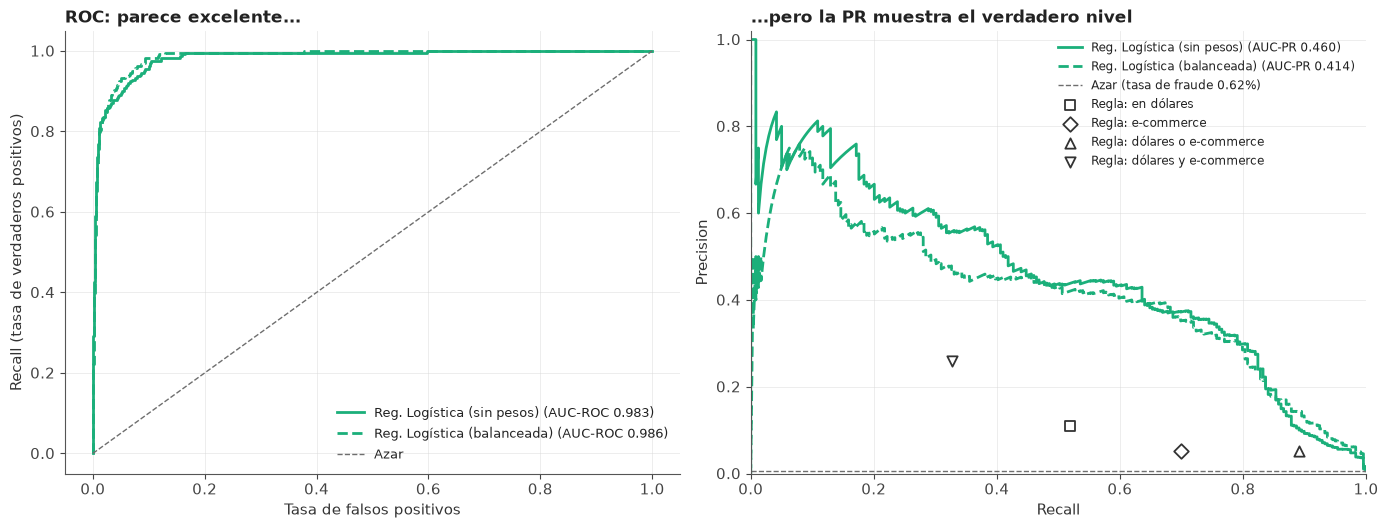

Reg. Logística (sin pesos): precision máxima con recall >= 0,50: 0.446 | con recall >= 0,80: 0.300
Reg. Logística (balanceada): precision máxima con recall >= 0,50: 0.430 | con recall >= 0,80: 0.286
Regla: en dólares (recall 0.5188, precision 0.1089) -> precision de los modelos con ese recall: Reg. Logística (sin pesos) 0.446 | Reg. Logística (balanceada) 0.425
Regla: e-commerce (recall 0.6987, precision 0.0512) -> precision de los modelos con ese recall: Reg. Logística (sin pesos) 0.375 | Reg. Logística (balanceada) 0.362
Regla: dólares o e-commerce (recall 0.8912, precision 0.0519) -> precision de los modelos con ese recall: Reg. Logística (sin pesos) 0.105 | Reg. Logística (balanceada) 0.144
Regla: dólares y e-commerce (recall 0.3264, precision 0.2600) -> precision de los modelos con ese recall: Reg. Logística (sin pesos) 0.569 | Reg. Logística (balanceada) 0.479


In [12]:
def curvas_roc_pr(nombres, titulo_roc='Curva ROC', titulo_pr='Curva Precision-Recall', mostrar_reglas=True, figsize=(14, 5.4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for i, nombre in enumerate(nombres):
        fpr, tpr, _ = roc_curve(y_test, scores_test[nombre])
        pr, rc, _ = precision_recall_curve(y_test, scores_test[nombre])
        estilo = '--' if 'balanceada' in nombre else '-'
        axes[0].plot(fpr, tpr, color=color_modelo(nombre), ls=estilo, lw=2, label=f"{nombre} (AUC-ROC {resultados[nombre]['auc_roc']:.3f})")
        axes[1].plot(rc, pr, color=color_modelo(nombre), ls=estilo, lw=2, label=f"{nombre} (AUC-PR {resultados[nombre]['auc_pr']:.3f})")
    axes[0].plot([0, 1], [0, 1], ls='--', color=GRIS, lw=1, label='Azar')
    axes[0].set_xlabel('Tasa de falsos positivos'); axes[0].set_ylabel('Recall (tasa de verdaderos positivos)')
    axes[0].set_title(titulo_roc); axes[0].legend(loc='lower right')
    prev = float(y_test.mean())
    axes[1].axhline(prev, ls='--', color=GRIS, lw=1, label=f'Azar (tasa de fraude {prev:.2%})')
    if mostrar_reglas:
        marcadores = ['s', 'D', '^', 'v']
        for j, nombre in enumerate([n for n in resultados if n.startswith('Regla')]):
            axes[1].scatter(resultados[nombre]['recall'], resultados[nombre]['precision'], marker=marcadores[j % 4], s=55,
                            color='white', edgecolor='#333333', linewidth=1.3, zorder=5, label=nombre)
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title(titulo_pr)
    axes[1].set_xlim(0, 1.0); axes[1].set_ylim(0, 1.02); axes[1].legend(loc='upper right', fontsize=8.5)
    plt.tight_layout(); plt.show()
    curvas = {n: precision_recall_curve(y_test, scores_test[n])[:2] for n in nombres}
    for nombre in nombres:      # lectura numérica de la curva PR: mejor precision que se puede lograr exigiendo cierto recall
        pr, rc = curvas[nombre]
        print(f"{nombre}: precision máxima con recall >= 0,50: {pr[rc >= 0.5].max():.3f} | con recall >= 0,80: {pr[rc >= 0.8].max():.3f}")
    if mostrar_reglas:          # ¿qué precision logra cada modelo con el MISMO recall que cada regla?
        for regla in [n for n in resultados if n.startswith('Regla')]:
            r_, p_ = resultados[regla]['recall'], resultados[regla]['precision']
            comparacion = ' | '.join(f"{n} {curvas[n][0][curvas[n][1] >= r_].max():.3f}" for n in nombres)
            print(f"{regla} (recall {r_:.4f}, precision {p_:.4f}) -> precision de los modelos con ese recall: {comparacion}")

curvas_roc_pr(list(modelos_lineales), titulo_roc='ROC: parece excelente...', titulo_pr='...pero la PR muestra el verdadero nivel')

**Comentario:** acá se ve lo que anticipamos sobre la AUC-ROC. Las dos curvas ROC son casi perfectas (**AUC-ROC de 0,983 y 0,986**), pero las curvas precision-recall cuentan otra historia (**AUC-PR de 0,460 y 0,414**): si se exige detectar al menos la mitad de los fraudes, la mejor precision que logra el modelo sin pesos es 0,446 (0,430 el balanceado), es decir, más de una falsa alarma por cada acierto, y con recall de 0,80 baja a 0,300 y 0,286. La ROC se ve tan bien porque los 103.499 negativos de `SIN_RUBRO` (más todo lo trivial) llevan a la tasa de falsos positivos a casi cero. **No hay que dejarse engañar por una AUC-ROC de 0,98.**

También se ve que **la regresión logística le gana a las cuatro reglas de negocio**: con el mismo recall que cada regla, el modelo logra más precision. Con el recall de la regla "dólares y e-commerce" (0,3264) la logística sin pesos llega a una precision de 0,569 (0,479 la balanceada) contra 0,26 de la regla; con el de "en dólares" (0,5188), a 0,446 contra 0,1089; y con el de "dólares o e-commerce" (0,8912), a 0,105 contra 0,0519. Es la primera evidencia de que combinar variables aporta algo más que cualquier criterio de una sola pregunta.

# 4. Predicción con modelos basados en árboles de decisión

Un árbol divide el espacio de variables con una secuencia de preguntas ("¿es en dólares? ¿es e-commerce? ¿el importe supera tal valor?"). Captura relaciones **no lineales e interacciones** sin tener que especificarlas a mano, y no necesita variables escaladas. Usan `features_arboles` (las 32 variables).

### 4.1 Árbol sin restricciones: el caso típico de sobreajuste

Árbol sin restricciones | umbral 0.500
   accuracy 0.9945 (engañosa) | precision 0.5592 | recall 0.5732 | F1 0.5661 | AUC-PR 0.3232 | AUC-ROC 0.7852
   verdaderos+ 137 | falsos+ 108 | falsos- 102 | verdaderos- 38,157
   profundidad alcanzada: 26 | hojas: 725
   en entrenamiento: F1 1.0000 | AUC-PR 1.0000


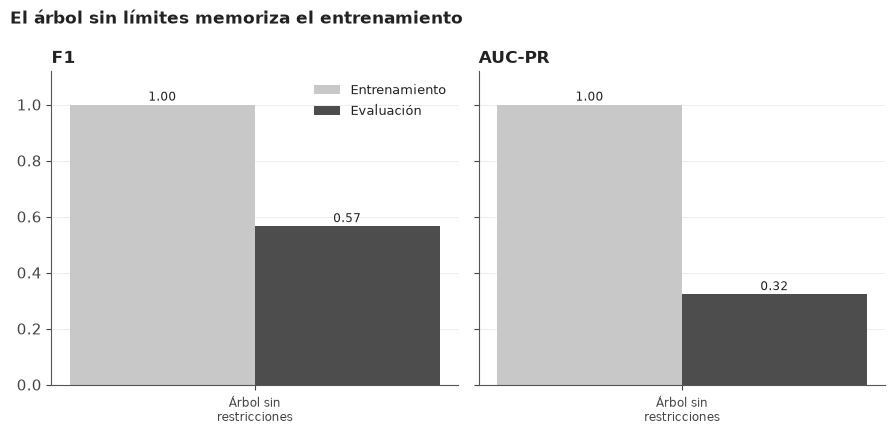

In [13]:
def grafico_train_test(nombres, titulo):
    """F1 y AUC-PR en entrenamiento vs evaluación para varios modelos (para ver el sobreajuste)."""
    fig, axes = plt.subplots(1, 2, figsize=(max(9, 1.55 * len(nombres) + 4), 4.4), sharey=True)
    xx = np.arange(len(nombres)); w = 0.38
    for ax, met, nom in zip(axes, ['f1', 'auc_pr'], ['F1', 'AUC-PR']):
        tr = [info_train[n][met] for n in nombres]
        te = [resultados[n][met] for n in nombres]
        ax.bar(xx - w / 2, tr, w, color='#c8c8c8', label='Entrenamiento')
        ax.bar(xx + w / 2, te, w, color='#4d4d4d', label='Evaluación')
        for i, (a, b) in enumerate(zip(tr, te)):
            ax.text(i - w / 2, a + 0.015, f"{a:.2f}", ha='center', fontsize=8.5)
            ax.text(i + w / 2, b + 0.015, f"{b:.2f}", ha='center', fontsize=8.5)
        ax.set_xticks(xx); ax.set_xticklabels([textwrap.fill(etiqueta_corta(n), 16, break_long_words=False) for n in nombres], fontsize=8.5)
        ax.set_ylim(0, 1.12); ax.set_title(nom); ax.grid(axis='x', visible=False)
    axes[0].legend(loc='upper right')
    plt.suptitle(titulo, x=0.01, ha='left', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

arbol_libre = DecisionTreeClassifier(random_state=SEED).fit(X_train[features_arboles], y_train)
s_te = arbol_libre.predict_proba(X_test[features_arboles])[:, 1]
s_tr = arbol_libre.predict_proba(X_train[features_arboles])[:, 1]
registrar('Árbol sin restricciones', s_te >= 0.5, s_te, umbral=0.5, grupo='Árbol')
registrar_train('Árbol sin restricciones', s_tr >= 0.5, s_tr)
reportar('Árbol sin restricciones')
print(f"   profundidad alcanzada: {arbol_libre.get_depth()} | hojas: {arbol_libre.get_n_leaves():,}")
print(f"   en entrenamiento: F1 {info_train['Árbol sin restricciones']['f1']:.4f} | AUC-PR {info_train['Árbol sin restricciones']['auc_pr']:.4f}")
grafico_train_test(['Árbol sin restricciones'], 'El árbol sin límites memoriza el entrenamiento')

**Comentario:** el árbol sin restricciones crece hasta **26 niveles y 725 hojas** y aprende el entrenamiento **de memoria** (F1 y AUC-PR de 1,000 en train). En evaluación, su F1 es 0,5661 (precision 0,5592, recall 0,5732) y su AUC-PR cae a 0,3232: es el patrón típico de sobreajuste.

Pero hay un detalle intrigante que vamos a retomar en la sección 8: un árbol que solo "recuerda" detecta el 57% de los fraudes de test con una precision del 56% (**mejor F1 que cualquier regresión logística con umbral 0,5**). Si no hubiera nada que memorizar, no debería funcionar tan bien. La explicación más probable es que muchos fraudes de test tienen un "gemelo" casi idéntico en el entrenamiento (el mismo cliente, en el mismo episodio).

### 4.2 Un árbol poco profundo, traducido a reglas de negocio

Un árbol de profundidad 3 pierde precisión, pero se **puede leer entero** y traducir a reglas para el equipo de prevención. Para que las reglas sean legibles lo entrenamos **sin los componentes PCA** (son combinaciones de varias variables y no se pueden traducir a una pregunta de negocio). Dibujamos el árbol con `plot_tree` y lo mostramos con un formato pensado para negocio: cada caja dice cuántas transacciones llegaron hasta ahí y **qué porcentaje es fraude** (naranja más fuerte = más riesgo); en cada pregunta, la rama izquierda es "No" y la derecha "Sí".

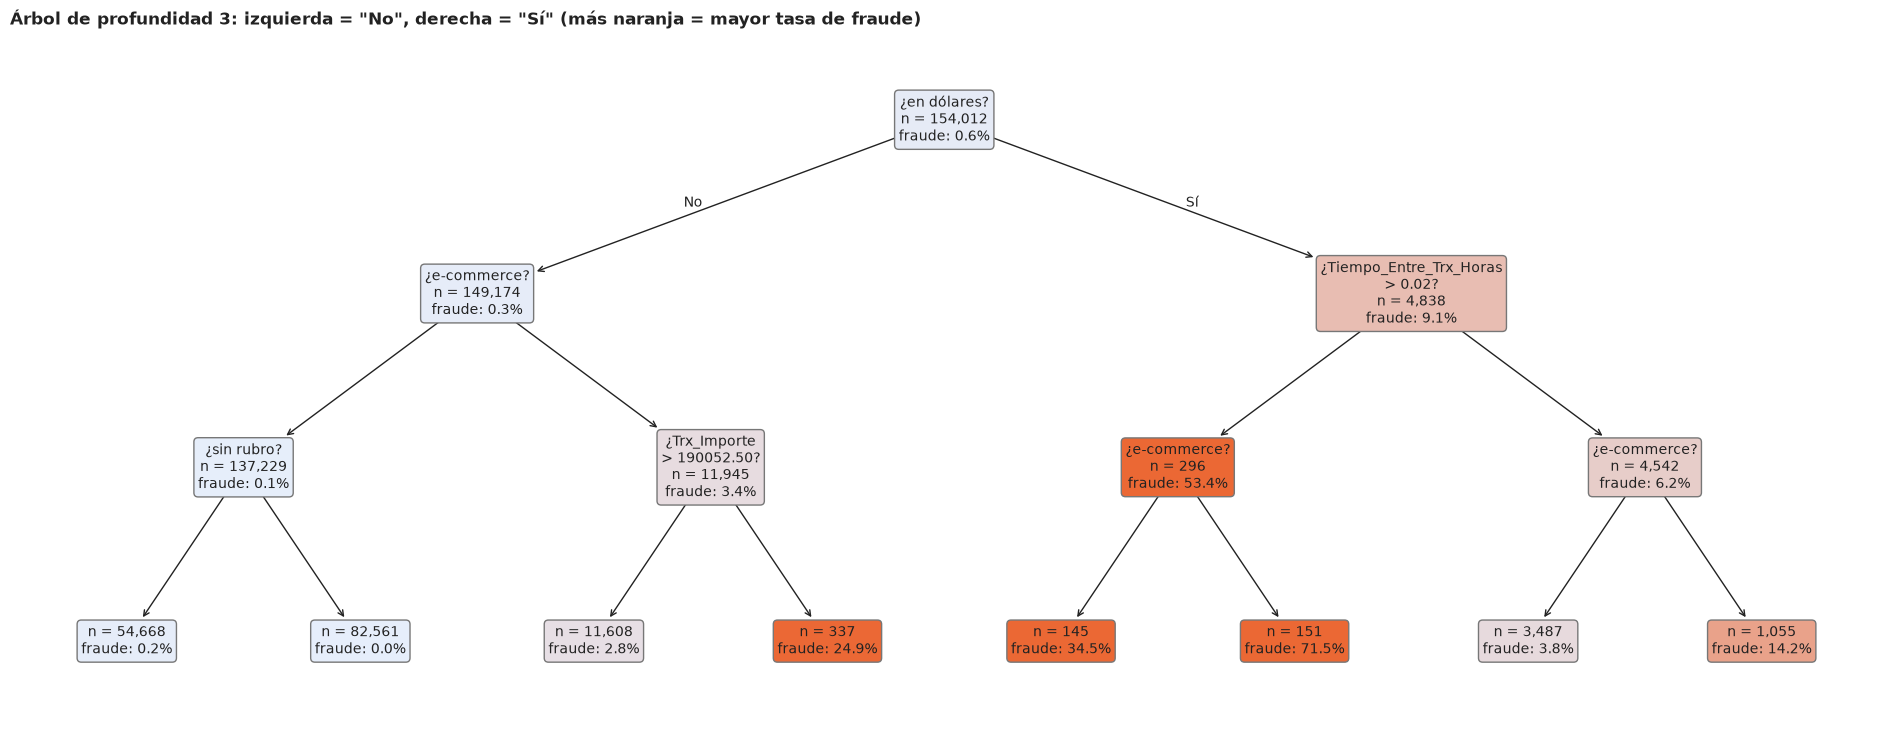

,regla (hoja),transacciones,fraudes,tasa de fraude (%)
0,en dólares Y Tiempo_Entre_Trx_Horas <= 0.02 Y e-commerce,151,108,71.5200
1,en dólares Y Tiempo_Entre_Trx_Horas <= 0.02 Y NO e-commerce,145,50,34.4800
2,NO en dólares Y e-commerce Y Trx_Importe > 190052.50,337,84,24.9300
3,en dólares Y Tiempo_Entre_Trx_Horas > 0.02 Y e-commerce,1055,150,14.2200
4,en dólares Y Tiempo_Entre_Trx_Horas > 0.02 Y NO e-commerce,3487,133,3.8100
5,NO en dólares Y e-commerce Y Trx_Importe <= 190052.50,11608,324,2.7900
6,NO en dólares Y NO e-commerce Y NO sin rubro,54668,108,0.2000
7,NO en dólares Y NO e-commerce Y sin rubro,82561,0,0.0000


Primera pregunta del árbol: ¿en dólares?
  Todas las transacciones: 154,012 transacciones, tasa de fraude 0.6%
  Respuesta "No": 149,174 transacciones, tasa de fraude 0.3%
  Respuesta "Sí": 4,838 transacciones, tasa de fraude 9.1%
Tiempo_Entre_Trx_Horas <= 0.02 equivale a menos de 72 segundos desde la transacción anterior
Árbol legible (prof. 3) | umbral 0.500
   accuracy 0.9940 (engañosa) | precision 0.6047 | recall 0.1088 | F1 0.1844 | AUC-PR 0.2169 | AUC-ROC 0.9472
   verdaderos+ 26 | falsos+ 17 | falsos- 213 | verdaderos- 38,248


In [14]:
BINARIAS = [c for c in features_arboles if set(X[c].unique()) <= {0, 1}]
ALIAS = {'Trx_Moneda': 'en dólares', 'Presencia_Cliente': 'cliente presente', 'Es_Outlier_Importe': 'importe atípico',
         'TipoTerminal_Agrupamiento_Compras y E-commerce': 'e-commerce',
         'TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)': 'credenciales guardadas',
         'TipoTerminal_Agrupamiento_Pagos de Servicios y Web': 'pago de servicios web',
         'Categoria_Rubro_SIN_RUBRO': 'sin rubro', 'Categoria_Rubro_OTROS_RUBROS': 'rubro otros',
         'Categoria_Rubro_Servicios Varios': 'rubro servicios varios'}
def alias(c):
    return ALIAS.get(c, c)

def pregunta(c, thr):
    return f"¿{alias(c)}?" if c in BINARIAS else f"¿{c}\n> {thr:.2f}?"

def condicion(c, thr, izquierda):
    if c in BINARIAS:
        return ('NO ' if izquierda else '') + alias(c)
    return f"{c} {'<=' if izquierda else '>'} {thr:.2f}"

def color_riesgo(tasa, tope=0.25):
    t = min(1.0, tasa / tope)
    base, fin = np.array(mcolors.to_rgb('#e6eefb')), np.array(mcolors.to_rgb(NARANJA))
    return tuple(base + (fin - base) * t)

def dibujar_arbol_legible(arbol, columnas, figsize=(19, 7.5)):
    fig, ax = plt.subplots(figsize=figsize)
    anots = plot_tree(arbol, feature_names=columnas, class_names=['No Fraude', 'Fraude'], filled=True,
                      impurity=False, rounded=True, fontsize=10, ax=ax)
    t = arbol.tree_
    preorden = []
    def dfs(n):
        preorden.append(n)
        if t.children_left[n] != -1:
            dfs(t.children_left[n]); dfs(t.children_right[n])
    dfs(0)
    # plot_tree agrega dos etiquetas "True"/"False" en las ramas de la raíz: en nuestro formato izquierda = "No" y derecha = "Sí"
    for a in anots:
        if a.get_text().strip() == 'True':
            a.set_text('No  ')
        elif a.get_text().strip() == 'False':
            a.set_text('  Sí')
    anots = [a for a in anots if a.get_text().strip() not in ('No', 'Sí')]
    assert len(preorden) == len(anots), "el orden de los nodos dibujados no coincide con el del árbol"
    for nodo, ann in zip(preorden, anots):
        v = t.value[nodo][0]; n = int(t.n_node_samples[nodo]); tasa = v[1] / v.sum()
        cabecera = pregunta(columnas[t.feature[nodo]], t.threshold[nodo]) + "\n" if t.children_left[nodo] != -1 else ""
        ann.set_text(f"{cabecera}n = {n:,}\nfraude: {tasa:.1%}")
        ann.get_bbox_patch().set_facecolor(color_riesgo(tasa))
        ann.get_bbox_patch().set_edgecolor('#777777')
    ax.set_title('Árbol de profundidad 3: izquierda = "No", derecha = "Sí" (más naranja = mayor tasa de fraude)', loc='left')
    plt.tight_layout(); plt.show()

def reglas_hojas(arbol, columnas):
    t = arbol.tree_
    filas = []
    def rec(nodo, camino):
        if t.children_left[nodo] == -1:
            v = t.value[nodo][0]; n = int(t.n_node_samples[nodo]); tasa = v[1] / v.sum()
            filas.append({'regla (hoja)': ' Y '.join(camino), 'transacciones': n, 'fraudes': int(round(tasa * n)), 'tasa de fraude (%)': tasa * 100})
            return
        c, thr = columnas[t.feature[nodo]], t.threshold[nodo]
        rec(t.children_left[nodo], camino + [condicion(c, thr, True)])
        rec(t.children_right[nodo], camino + [condicion(c, thr, False)])
    rec(0, [])
    return pd.DataFrame(filas).sort_values('tasa de fraude (%)', ascending=False).reset_index(drop=True)

cols_legibles = [c for c in features_arboles if not c.startswith('PCA_')]
arbol_legible = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=SEED).fit(X_train[cols_legibles], y_train)
s_te = arbol_legible.predict_proba(X_test[cols_legibles])[:, 1]
s_tr = arbol_legible.predict_proba(X_train[cols_legibles])[:, 1]
registrar('Árbol legible (prof. 3)', s_te >= 0.5, s_te, umbral=0.5, grupo='Árbol')
registrar_train('Árbol legible (prof. 3)', s_tr >= 0.5, s_tr)

dibujar_arbol_legible(arbol_legible, cols_legibles)
tabla_reglas = reglas_hojas(arbol_legible, cols_legibles)
pd.set_option('display.max_colwidth', 120)
display(tabla_reglas.round(2))
t_ = arbol_legible.tree_
print("Primera pregunta del árbol:", pregunta(cols_legibles[t_.feature[0]], t_.threshold[0]).replace(chr(10), ' '))
for nodo, etiqueta in [(0, 'Todas las transacciones'), (t_.children_left[0], 'Respuesta "No"'), (t_.children_right[0], 'Respuesta "Sí"')]:
    v_ = t_.value[nodo][0]
    print(f"  {etiqueta}: {int(t_.n_node_samples[nodo]):,} transacciones, tasa de fraude {v_[1] / v_.sum() * 100:.1f}%")
print(f"Tiempo_Entre_Trx_Horas <= 0.02 equivale a menos de {0.02 * 3600:.0f} segundos desde la transacción anterior")
reportar('Árbol legible (prof. 3)')

**Comentario:** el árbol de profundidad 3 se lee de arriba hacia abajo como un protocolo de revisión. Lo primero que pregunta es si la operación es **en dólares**: en pesos (149.174 transacciones) la tasa de fraude es de 0,3% y en dólares (4.838 transacciones) de 9,1%, contra 0,6% en el total. Dentro de los dólares, lo que más separa es el **tiempo desde la transacción anterior** (`Tiempo_Entre_Trx_Horas <= 0,02` horas, es decir, menos de 72 segundos: una *ráfaga* de operaciones) y después si es **e-commerce**. La hoja más riesgosa es la combinación *"en dólares, ráfaga y e-commerce"*: **151 transacciones con 71,52% de fraude** (108 fraudes). En pesos, la señal más fuerte es e-commerce con un importe alto (`Trx_Importe` > 190.052,50): 337 transacciones con 24,93% de fraude. Por otro lado, la rama "pesos, sin e-commerce y sin rubro" (82.561 transacciones) tiene 0 fraudes, otra vez el efecto `SIN_RUBRO`.

La tabla traduce las 8 hojas a reglas que el equipo de prevención podría aplicar tal cual. El costo es la capacidad predictiva: con el umbral 0,5 el árbol tiene precision 0,6047 pero recall de solo 0,1088 (F1 0,1844, AUC-PR 0,2169). Sirve para **explicar**, no para competir. Una limitación a tener en cuenta: en la hoja "pesos, sin e-commerce, con rubro" (54.668 transacciones) todavía hay 108 fraudes (tasa 0,20%) que ninguna regla simple logra aislar: ahí está la parte difícil del problema.

### 4.3 Modelos de ensamble con configuración "de manual"

Un solo árbol es inestable. Los **ensambles** combinan muchos árboles:

- **Random Forest**: muchos árboles profundos entrenados en paralelo sobre muestras distintas de filas y de variables; sus errores se compensan al promediar.
- **HistGradientBoosting** y **XGBoost** (*boosting*): árboles chicos entrenados en secuencia, cada uno corrigiendo los errores del anterior. XGBoost es lo que el TP2 recomendó para esta etapa; usamos `tree_method='hist'` (rápido) y `scale_pos_weight` (el cociente legítimas/fraudes) para compensar el desbalance.

Los entrenamos acá con una configuración razonable y **umbral 0,5**, solo como punto de partida: la sección 5 los ajusta.

Random Forest (base) | umbral 0.500
   accuracy 0.9965 (engañosa) | precision 0.8931 | recall 0.4895 | F1 0.6324 | AUC-PR 0.7287 | AUC-ROC 0.9819
   verdaderos+ 117 | falsos+ 14 | falsos- 122 | verdaderos- 38,251
   en entrenamiento: F1 0.9917 | AUC-PR 0.9980 | entrenado en 5.6 s



HistGradientBoosting (base) | umbral 0.500
   accuracy 0.9895 (engañosa) | precision 0.3570 | recall 0.8619 | F1 0.5049 | AUC-PR 0.7538 | AUC-ROC 0.9871
   verdaderos+ 206 | falsos+ 371 | falsos- 33 | verdaderos- 37,894
   en entrenamiento: F1 0.6162 | AUC-PR 0.9800 | entrenado en 8.7 s



XGBoost (base) | umbral 0.500
   accuracy 0.9621 (engañosa) | precision 0.1308 | recall 0.9038 | F1 0.2286 | AUC-PR 0.6248 | AUC-ROC 0.9846
   verdaderos+ 216 | falsos+ 1,435 | falsos- 23 | verdaderos- 36,830
   en entrenamiento: F1 0.2561 | AUC-PR 0.7686 | entrenado en 3.5 s



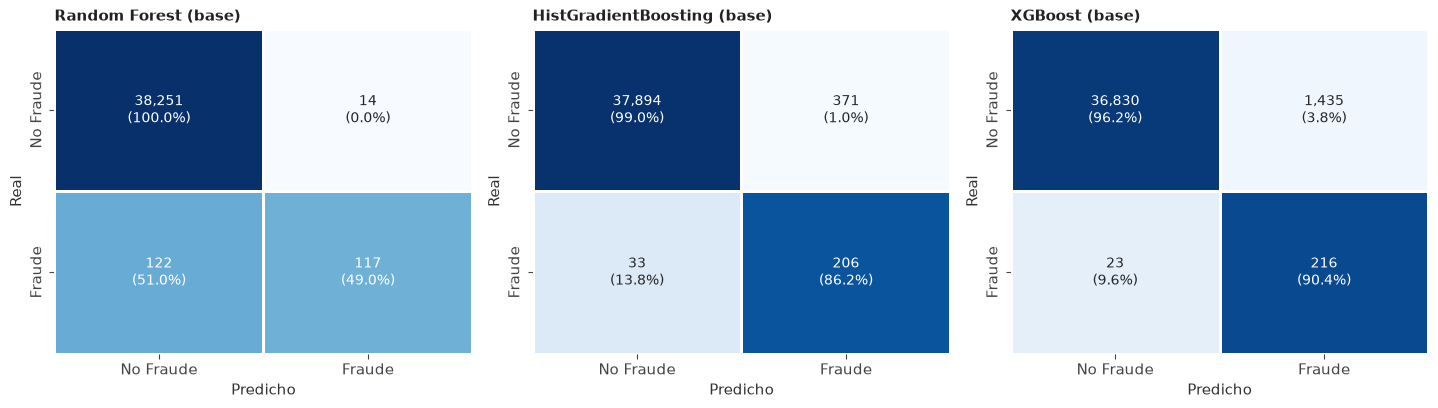

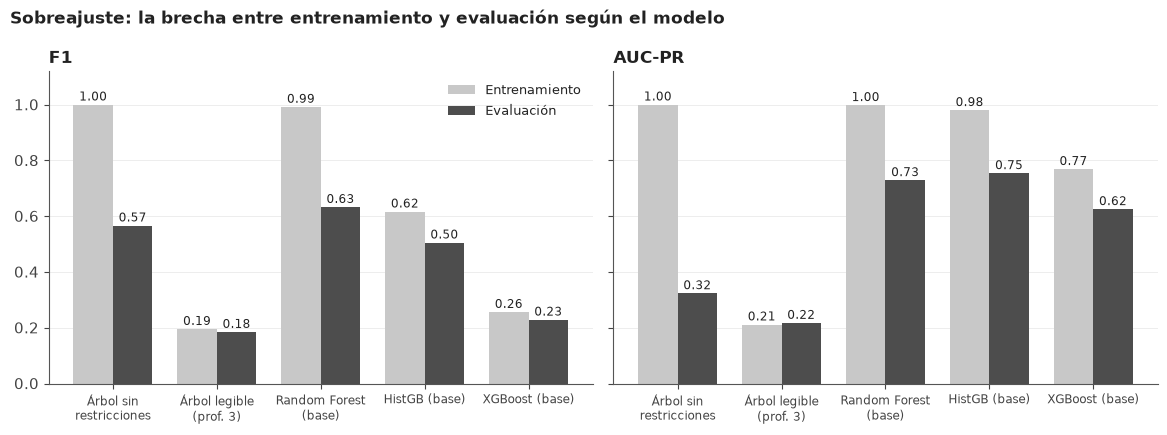

In [15]:
modelos_ensamble = {
    'Random Forest (base)': RandomForestDeterminista(n_estimators=100, min_samples_leaf=3, class_weight='balanced_subsample',
                                                    n_jobs=N_JOBS, random_state=SEED),
    'HistGradientBoosting (base)': HistGradientBoostingClassifier(max_iter=150, learning_rate=0.1, early_stopping=False,
                                                                  class_weight='balanced', random_state=SEED),
    'XGBoost (base)': XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
                                    scale_pos_weight=ratio_desb, tree_method='hist', n_jobs=XGB_JOBS, random_state=SEED)}

for nombre, modelo in modelos_ensamble.items():
    t0 = time.time()
    modelo.fit(X_train[features_arboles], y_train)
    s_te = modelo.predict_proba(X_test[features_arboles])[:, 1]
    s_tr = modelo.predict_proba(X_train[features_arboles])[:, 1]
    registrar(nombre, s_te >= 0.5, s_te, umbral=0.5, grupo='Árbol')
    registrar_train(nombre, s_tr >= 0.5, s_tr)
    reportar(nombre)
    print(f"   en entrenamiento: F1 {info_train[nombre]['f1']:.4f} | AUC-PR {info_train[nombre]['auc_pr']:.4f} | entrenado en {time.time() - t0:.1f} s\n")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
for ax, nombre in zip(axes, modelos_ensamble):
    graficar_matriz_confusion(ax, nombre)
plt.tight_layout(); plt.show()

grafico_train_test(['Árbol sin restricciones', 'Árbol legible (prof. 3)'] + list(modelos_ensamble), 'Sobreajuste: la brecha entre entrenamiento y evaluación según el modelo')

**Comentario:** los tres ensambles superan ampliamente a todo lo anterior en **AUC-PR** (0,7287 el Random Forest, 0,7538 HistGradientBoosting y 0,6248 XGBoost, contra 0,41-0,46 de la regresión logística y 0,32 del árbol libre). Con los modelos de manual y el umbral 0,5 no conviene comparar el F1, porque cada uno cae en un punto de operación distinto: el Random Forest es conservador (precision 0,8931, recall 0,4895, F1 0,6324), mientras que HistGradientBoosting con `class_weight='balanced'` (precision 0,357, recall 0,8619) y XGBoost con `scale_pos_weight` ≈ 160 (precision 0,1308, recall 0,9038) alertan de más: los pesos de clase *desplazan las probabilidades hacia arriba* y el umbral de 0,5 deja de ser razonable. Eso lo corregimos en la sección 5.5.

En cuanto al sobreajuste, el Random Forest llega a AUC-PR de 0,998 en entrenamiento contra 0,7287 en test y HistGradientBoosting a 0,980 contra 0,7538: los árboles profundos memorizan buena parte del entrenamiento. XGBoost, con árboles poco profundos (`max_depth` = 5) y una tasa de aprendizaje baja (0,05), es el que menos brecha tiene (0,7686 contra 0,6248).

### 4.4 Importancia de las variables

Dos formas de preguntar "¿qué usa el modelo?": la **importancia por impureza** del Random Forest (cuánto reduce el desorden cada variable al dividir) y la **importancia por ganancia** de XGBoost. Ambas dicen *cuánto* usa el modelo una variable, no en qué dirección, y tienden a sobreestimar las variables continuas con muchos valores distintos; en la sección 6 las contrastamos con la importancia por permutación sobre test.

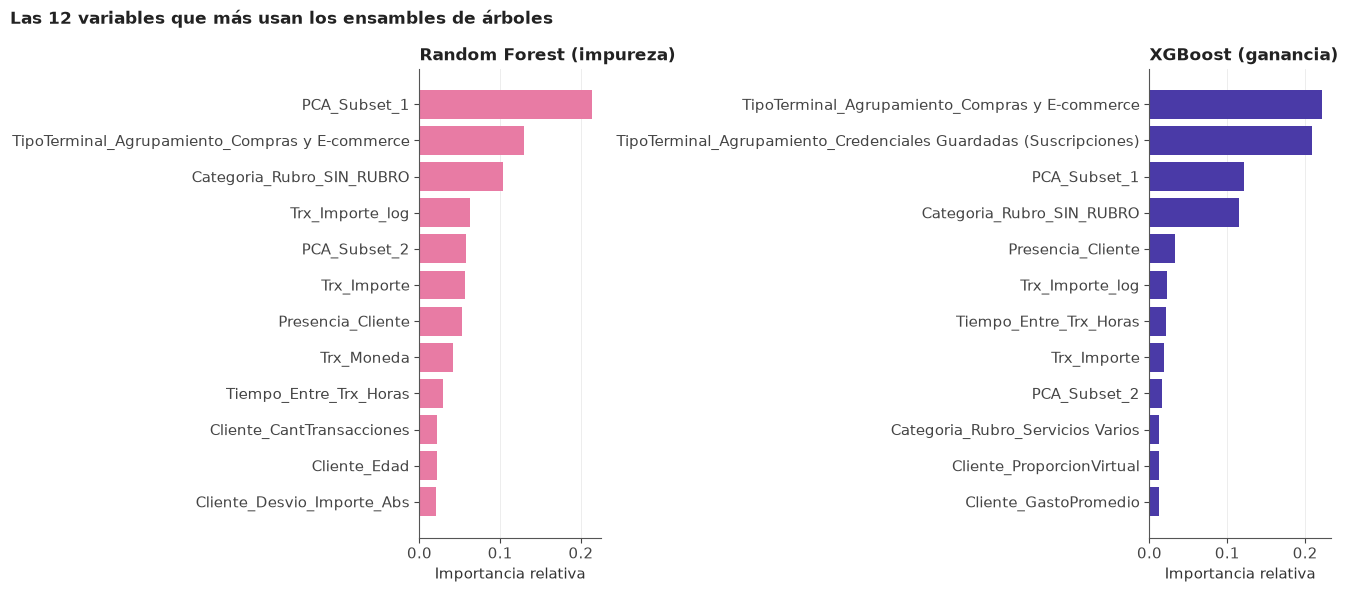

Suma de la importancia de las 3 variables con más peso: RF 44.7% | XGBoost 55.1%
Top 5 RF:      {'PCA_Subset_1': 0.214, 'TipoTerminal_Agrupamiento_Compras y E-commerce': 0.129, 'Categoria_Rubro_SIN_RUBRO': 0.104, 'Trx_Importe_log': 0.063, 'PCA_Subset_2': 0.057}
Top 5 XGBoost: {'TipoTerminal_Agrupamiento_Compras y E-commerce': 0.22200000286102295, 'TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)': 0.20800000429153442, 'PCA_Subset_1': 0.12099999934434891, 'Categoria_Rubro_SIN_RUBRO': 0.11599999666213989, 'Presencia_Cliente': 0.032999999821186066}


In [16]:
imp_rf = pd.Series(modelos_ensamble['Random Forest (base)'].feature_importances_, index=features_arboles).sort_values(ascending=False)
imp_xgb = pd.Series(modelos_ensamble['XGBoost (base)'].feature_importances_, index=features_arboles).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
for ax, serie, titulo in zip(axes, [imp_rf, imp_xgb], ['Random Forest (impureza)', 'XGBoost (ganancia)']):
    top = serie.head(12)[::-1]
    ax.barh(top.index, top.values, color=color_modelo(titulo))
    ax.set_title(titulo); ax.set_xlabel('Importancia relativa'); ax.grid(axis='y', visible=False)
plt.suptitle('Las 12 variables que más usan los ensambles de árboles', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

comparacion = pd.DataFrame({'RF (impureza)': imp_rf, 'XGBoost (ganancia)': imp_xgb})
print("Suma de la importancia de las 3 variables con más peso: RF {:.1%} | XGBoost {:.1%}".format(imp_rf.head(3).sum(), imp_xgb.head(3).sum()))
print("Top 5 RF:     ", imp_rf.head(5).round(3).to_dict())
print("Top 5 XGBoost:", imp_xgb.head(5).round(3).to_dict())

**Comentario:** las dos medidas coinciden en lo grueso: el **canal** (`TipoTerminal_Agrupamiento_Compras y E-commerce` pesa 0,129 en el Random Forest y 0,222 en XGBoost), el **rubro** (`Categoria_Rubro_SIN_RUBRO`: 0,104 y 0,116) y los **componentes PCA** (`PCA_Subset_1` es la variable más importante del Random Forest, con 0,214, y la tercera en XGBoost, con 0,121) concentran la mayor parte de la importancia: las tres variables más importantes suman 44,7% en el Random Forest y 55,1% en XGBoost. Es consistente con el EDA, que había señalado el canal y el rubro como los grandes discriminadores, y con el TP2, donde `PCA_Subset_1` era la variable con mayor correlación con el target. Esto es importancia *por impureza o ganancia*, que tiende a favorecer variables con muchos valores distintos y no dice en qué dirección empuja cada una; en la sección 6.5 la contrastamos con la importancia por permutación sobre test.

# 5. Ajuste por hiperparámetros

Hasta acá probamos modelos con configuraciones "de manual". Ahora los ajustamos con **validación cruzada estratificada sobre el conjunto de entrenamiento** (`StratifiedKFold`, que mantiene la tasa de fraude en cada fold), optimizando **`average_precision` (AUC-PR)**, la métrica principal. El conjunto de evaluación no participa en ninguna decisión de esta sección.

Tres reglas para que el ajuste sea honesto:

1. **Todo el preprocesamiento va dentro del Pipeline**: el escalado y, cuando hay remuestreo (SMOTE o submuestreo), el remuestreo ocurre *solo con los folds de entrenamiento*. Para eso usamos `imblearn.pipeline.Pipeline`.
2. **Búsqueda en grilla** (`GridSearchCV`) para los modelos baratos (regresión logística, árbol) y **búsqueda aleatoria acotada** (`RandomizedSearchCV`) para los caros (Random Forest y XGBoost). Con 3 folds en estos últimos para mantener el tiempo de cómputo razonable.
3. **El umbral de decisión se elige con predicciones out-of-fold** del conjunto de entrenamiento (`cross_val_predict`), nunca mirando test.

In [17]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
SCORING = 'average_precision'

def a_tabla(search, k=5, extra=()):
    """Mejores k configuraciones de una búsqueda (promedio y desvío en validación, y promedio en entrenamiento)."""
    r = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False).head(k)
    cols = [c for c in r.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'mean_train_score']
    r = r[cols].copy()
    r.columns = [c.replace('param_', '').replace('modelo__', '') for c in r.columns]
    return r.rename(columns={'mean_test_score': 'AUC-PR validación', 'std_test_score': 'desvío (folds)', 'mean_train_score': 'AUC-PR entrenamiento'}).reset_index(drop=True)

t_sec5 = time.time()

### 5.1 Regresión Logística: regularización (`C`) y pesos de clase

`C` es la inversa de la fuerza de regularización (menor `C` = más regularización). Exploramos `C` y si conviene o no `class_weight='balanced'`. Además del `C`, exploramos como complemento el **tipo de penalización** (L1 vs. L2): como el solver `liblinear` con L1 resulta muy lento con 154.000 filas (cerca de 85 segundos por ajuste en nuestras pruebas) y `saga` no converge en un tiempo razonable, lo exploramos con un clasificador lineal equivalente entrenado por gradiente (`SGDClassifier` con pérdida logística), que admite L1, L2 y ElasticNet. Ojo: ese SGD queda por debajo de la regresión logística exacta (no converge del todo en 100 épocas), así que la comparación entre penalizaciones se hace en un régimen aproximado.

GridSearch Regresión Logística (8 combinaciones x 5 folds) en 18 s
Mejor combinación: {'modelo__C': 10, 'modelo__class_weight': None} | AUC-PR de validación: 0.4372


,C,class_weight,AUC-PR validación,desvío (folds),AUC-PR entrenamiento
0,10.0000,None,0.4372,0.0490,0.4447
1,1.0000,None,0.4312,0.0468,0.4397
2,1.0000,balanced,0.3813,0.0440,0.3803
3,10.0000,balanced,0.3809,0.0456,0.3799
4,0.1000,balanced,0.3802,0.0411,0.3792
5,0.1000,None,0.3610,0.0382,0.3700



GridSearch SGD logístico (9 combinaciones x 3 folds) en 8 s
Mejor combinación: {'modelo__alpha': 0.0001, 'modelo__penalty': 'elasticnet'} | AUC-PR de validación: 0.3620


,alpha,penalty,AUC-PR validación,desvío (folds),AUC-PR entrenamiento
0,0.0001,elasticnet,0.3620,0.0521,0.3734
1,0.0000,elasticnet,0.3596,0.0528,0.3734
2,0.0001,l1,0.3549,0.0391,0.3407
3,0.0001,l2,0.3521,0.0303,0.3701
4,0.0000,l1,0.3475,0.0451,0.3453
5,0.0000,l2,0.3348,0.0758,0.3549


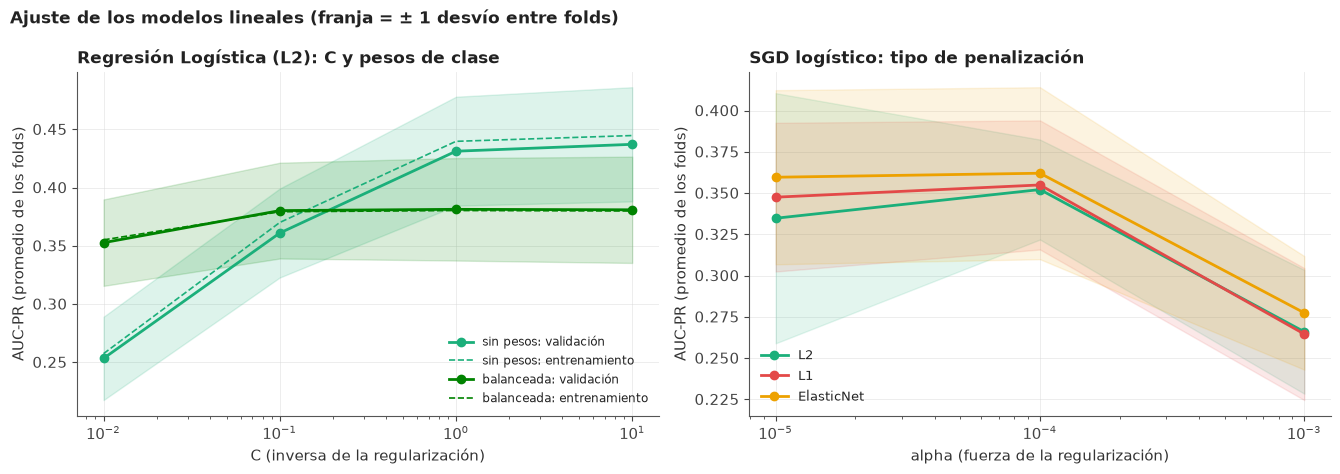

In [18]:
t0 = time.time()
grid_lr = GridSearchCV(
    Pipeline([('escalado', StandardScaler()), ('modelo', LogisticRegression(max_iter=2000))]),
    {'modelo__C': [0.01, 0.1, 1, 10], 'modelo__class_weight': [None, 'balanced']},
    scoring=SCORING, cv=cv5, n_jobs=-1, return_train_score=True)
grid_lr.fit(X_train[features_lineales], y_train)
print(f"GridSearch Regresión Logística ({len(grid_lr.cv_results_['params'])} combinaciones x 5 folds) en {time.time() - t0:.0f} s")
print("Mejor combinación:", grid_lr.best_params_, f"| AUC-PR de validación: {grid_lr.best_score_:.4f}")
display(a_tabla(grid_lr, k=6))

warnings.filterwarnings('ignore', category=ConvergenceWarning)   # el SGD con poca regularización no "converge" del todo en 100 épocas; para comparar penalizaciones alcanza
t0 = time.time()
grid_sgd = GridSearchCV(
    Pipeline([('escalado', StandardScaler()), ('modelo', SGDClassifier(loss='log_loss', max_iter=100, tol=1e-3, random_state=SEED))]),
    {'modelo__penalty': ['l2', 'l1', 'elasticnet'], 'modelo__alpha': [1e-5, 1e-4, 1e-3]},
    scoring=SCORING, cv=cv3, n_jobs=-1, return_train_score=True)
grid_sgd.fit(X_train[features_lineales], y_train)
print(f"\nGridSearch SGD logístico ({len(grid_sgd.cv_results_['params'])} combinaciones x 3 folds) en {time.time() - t0:.0f} s")
print("Mejor combinación:", grid_sgd.best_params_, f"| AUC-PR de validación: {grid_sgd.best_score_:.4f}")
display(a_tabla(grid_sgd, k=6))

# --- Gráfico ---
r_lr = pd.DataFrame(grid_lr.cv_results_)
r_sgd = pd.DataFrame(grid_sgd.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
for color, cw, nombre in [(color_modelo('Logística'), None, 'sin pesos'), (VERDE, 'balanced', 'balanceada')]:
    s = r_lr[r_lr['param_modelo__class_weight'].apply(lambda v: v == cw)].sort_values('param_modelo__C')
    c = s['param_modelo__C'].astype(float)
    ax.plot(c, s['mean_test_score'], color=color, marker='o', lw=2, label=f'{nombre}: validación')
    ax.fill_between(c, s['mean_test_score'] - s['std_test_score'], s['mean_test_score'] + s['std_test_score'], color=color, alpha=0.15)
    ax.plot(c, s['mean_train_score'], color=color, ls='--', lw=1.2, label=f'{nombre}: entrenamiento')
ax.set_xscale('log'); ax.set_xlabel('C (inversa de la regularización)'); ax.set_ylabel('AUC-PR (promedio de los folds)')
ax.set_title('Regresión Logística (L2): C y pesos de clase'); ax.legend(fontsize=8.5, loc='lower right')
ax = axes[1]
for color, pen in [(color_modelo('Logística'), 'l2'), (ROJO, 'l1'), (AMARILLO, 'elasticnet')]:
    s = r_sgd[r_sgd['param_modelo__penalty'] == pen].sort_values('param_modelo__alpha')
    a = s['param_modelo__alpha'].astype(float)
    ax.plot(a, s['mean_test_score'], color=color, marker='o', lw=2, label=pen.upper() if pen != 'elasticnet' else 'ElasticNet')
    ax.fill_between(a, s['mean_test_score'] - s['std_test_score'], s['mean_test_score'] + s['std_test_score'], color=color, alpha=0.12)
ax.set_xscale('log'); ax.set_xlabel('alpha (fuerza de la regularización)'); ax.set_ylabel('AUC-PR (promedio de los folds)')
ax.set_title('SGD logístico: tipo de penalización'); ax.legend(loc='lower left')
plt.suptitle('Ajuste de los modelos lineales (franja = ± 1 desvío entre folds)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** el ajuste de la regresión logística **no cambia la historia**. Con L2, el AUC-PR de validación sube de 0,361 (`C` = 0,1) a 0,4312 (`C` = 1) y se estanca en 0,4372 con `C` = 10, que es la mejor combinación. Con ese `C` el AUC-PR de entrenamiento es 0,4447, casi igual al de validación: el modelo no sobreajusta, simplemente es limitado. Lo que más pesa es el tratamiento del desbalance: **con los `C` que dan los mejores resultados (1 y 10), `class_weight='balanced'` empeora el ranking** (0,3813 contra 0,4372 en el mejor caso; con `C` = 0,1, donde el modelo está muy regularizado, ocurre lo contrario: 0,3802 contra 0,361). Esto tiene una lectura clara: los pesos de clase no hacen que el modelo *distinga mejor* a los fraudes, solo mueven el punto de operación hacia "alertar más", algo que se puede lograr igual cambiando el umbral (sección 5.5).

Sobre el tipo de penalización: con el SGD logístico, ElasticNet (AUC-PR 0,362 con `alpha` = 0,0001), L1 (0,3549) y L2 (0,3521) quedan separados por menos de 0,01, una diferencia mucho menor que el desvío entre folds (0,03 a 0,05). **La penalización no es lo que limita al modelo lineal**; el techo es que una combinación lineal de las variables no alcanza para este problema. (El SGD queda por debajo de la regresión logística "exacta" porque no converge del todo en 100 épocas; lo usamos solo para comparar penalizaciones, así que esa comparación es aproximada.)

### 5.2 Árbol de decisión: la curva de validación del sobreajuste y la grilla

La **curva de validación** muestra el desempeño en entrenamiento y en validación cruzada a medida que dejamos crecer el árbol (`max_depth`). Mientras las dos suben juntas el árbol está aprendiendo patrones reales; cuando entrenamiento sigue subiendo y validación se estanca o baja, está **memorizando**. Después corremos una grilla completa (profundidad, mínimo de muestras por hoja y criterio de impureza).

Curva de validación (8 profundidades x 5 folds) en 7 s


GridSearch Árbol (24 combinaciones x 3 folds) en 11 s
Mejor combinación: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 20} | AUC-PR de validación: 0.3705


,criterion,max_depth,min_samples_leaf,AUC-PR validación,desvío (folds),AUC-PR entrenamiento
0,gini,12,20,0.3705,0.0228,0.5669
1,gini,8,20,0.3618,0.0123,0.4933
2,entropy,12,20,0.3607,0.0259,0.6129
3,entropy,8,20,0.3548,0.0284,0.5209
4,entropy,8,1,0.3460,0.0232,0.6350
5,gini,6,20,0.3315,0.0037,0.4218


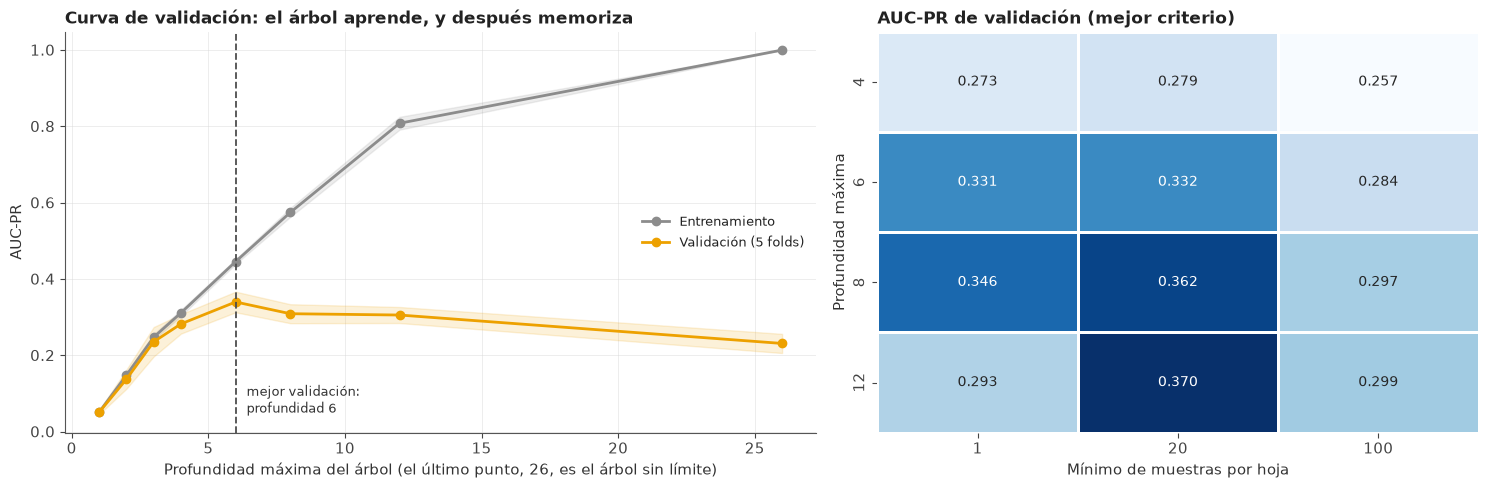

Árbol sin límite (26 niveles): AUC-PR entrenamiento 1.000 vs validación 0.231
Profundidad con mejor validación en la curva: 6 (AUC-PR 0.340)


In [19]:
t0 = time.time()
prof_libre = arbol_libre.get_depth()
profundidades = sorted(set([1, 2, 3, 4, 6, 8, 12, prof_libre]))
tr_sc, va_sc = validation_curve(DecisionTreeClassifier(random_state=SEED), X_train[features_arboles], y_train,
                                param_name='max_depth', param_range=profundidades, cv=cv5, scoring=SCORING, n_jobs=-1)
print(f"Curva de validación ({len(profundidades)} profundidades x 5 folds) en {time.time() - t0:.0f} s")

t0 = time.time()
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    {'max_depth': [4, 6, 8, 12], 'min_samples_leaf': [1, 20, 100], 'criterion': ['gini', 'entropy']},
    scoring=SCORING, cv=cv3, n_jobs=-1, return_train_score=True)
grid_dt.fit(X_train[features_arboles], y_train)
print(f"GridSearch Árbol ({len(grid_dt.cv_results_['params'])} combinaciones x 3 folds) en {time.time() - t0:.0f} s")
print("Mejor combinación:", grid_dt.best_params_, f"| AUC-PR de validación: {grid_dt.best_score_:.4f}")
display(a_tabla(grid_dt, k=6))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.25, 1]})
ax = axes[0]
for color, sc, nombre in [('#8c8c8c', tr_sc, 'Entrenamiento'), (color_modelo('Árbol'), va_sc, 'Validación (5 folds)')]:
    m, s = sc.mean(axis=1), sc.std(axis=1)
    ax.plot(profundidades, m, color=color, marker='o', lw=2, label=nombre)
    ax.fill_between(profundidades, m - s, m + s, color=color, alpha=0.15)
i_best = int(np.argmax(va_sc.mean(axis=1)))
ax.axvline(profundidades[i_best], color='#4d4d4d', ls='--', lw=1.3)
ax.text(profundidades[i_best] + 0.4, 0.05, f'mejor validación:\nprofundidad {profundidades[i_best]}', color='#333333', fontsize=9.5)
ax.set_xlabel(f'Profundidad máxima del árbol (el último punto, {prof_libre}, es el árbol sin límite)'); ax.set_ylabel('AUC-PR')
ax.set_title('Curva de validación: el árbol aprende, y después memoriza')
ax.legend(loc='center right')

r_dt = pd.DataFrame(grid_dt.cv_results_)
piv = r_dt.groupby(['param_max_depth', 'param_min_samples_leaf'])['mean_test_score'].max().unstack()
sns.heatmap(piv, annot=True, fmt='.3f', cmap='Blues', ax=axes[1], cbar=False, linewidths=1, linecolor='white', annot_kws={'size': 10})
axes[1].set_xlabel('Mínimo de muestras por hoja'); axes[1].set_ylabel('Profundidad máxima')
axes[1].set_title('AUC-PR de validación (mejor criterio)'); axes[1].grid(False)
plt.tight_layout(); plt.show()
print(f"Árbol sin límite ({prof_libre} niveles): AUC-PR entrenamiento {tr_sc[-1].mean():.3f} vs validación {va_sc[-1].mean():.3f}")
print(f"Profundidad con mejor validación en la curva: {profundidades[i_best]} (AUC-PR {va_sc.mean(axis=1)[i_best]:.3f})")

**Comentario:** la curva de validación (izquierda) muestra el sobreajuste con claridad. El AUC-PR de entrenamiento sube sin parar hasta 1,000 cuando el árbol queda sin límite (26 niveles), mientras que el de validación **alcanza su máximo en profundidad 6 (0,340) y después cae** hasta 0,231: de ahí en adelante el árbol solo memoriza. La grilla (derecha) encuentra que agregar un mínimo de 20 muestras por hoja permite árboles más profundos memorizando menos: la mejor combinación es `criterion='gini'`, `max_depth` = 12 y `min_samples_leaf` = 20, con un AUC-PR de validación de 0,3705 (contra 0,5669 en entrenamiento: la brecha sigue siendo grande). Mejora sobre el árbol libre (0,231), pero un único árbol no pasa de ahí: es el techo que los ensambles de la sección siguiente rompen.

### 5.3 Random Forest y XGBoost: búsqueda aleatoria acotada

Con los ensambles el espacio de hiperparámetros es grande y cada ajuste cuesta bastante, así que sorteamos un número acotado de configuraciones (`RandomizedSearchCV`, 8 para el Random Forest y 10 para XGBoost: un presupuesto parecido) con validación cruzada de 3 folds. En el Random Forest limitamos el tamaño de la muestra de cada árbol (`max_samples`) y la cantidad de árboles para que la búsqueda sea rápida. Ojo: la comparación entre las dos familias es **con este presupuesto de búsqueda**, y una grilla distinta podría mover un poco las diferencias. En XGBoost el desbalance se explora como un hiperparámetro más: `scale_pos_weight` puede valer 1 (sin compensar), la raíz del cociente legítimas/fraudes o el cociente completo.

In [20]:
t0 = time.time()
rs_rf = RandomizedSearchCV(
    RandomForestDeterminista(n_jobs=1, random_state=SEED),
    {'n_estimators': [100, 150], 'max_depth': [10, 14, None], 'min_samples_leaf': [1, 3, 5],
     'max_features': ['sqrt'], 'max_samples': [0.2, 0.4, 0.6], 'class_weight': [None, 'balanced_subsample']},
    n_iter=8, scoring=SCORING, cv=cv3, n_jobs=-1, random_state=SEED, return_train_score=True)
rs_rf.fit(X_train[features_arboles], y_train)
print(f"Random Forest: 8 configuraciones x 3 folds en {time.time() - t0:.0f} s")
print("Mejor:", rs_rf.best_params_, f"| AUC-PR de validación: {rs_rf.best_score_:.4f}")
display(a_tabla(rs_rf, k=4))

t0 = time.time()
rs_xgb = RandomizedSearchCV(
    XGBClassifier(tree_method='hist', n_jobs=XGB_JOBS, random_state=SEED),     # 2 hilos por ajuste, fijos: el resultado no depende de cuántos ajustes corran en paralelo
    {'n_estimators': [150, 300, 500], 'learning_rate': [0.05, 0.1, 0.2, 0.3], 'max_depth': [3, 4, 5, 6, 8],
     'min_child_weight': [1, 5, 10], 'subsample': [0.7, 0.85, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0],
     'reg_lambda': [1, 5, 10], 'scale_pos_weight': [1.0, float(np.sqrt(ratio_desb)), float(ratio_desb)]},
    n_iter=10, scoring=SCORING, cv=cv3, n_jobs=max(1, N_JOBS // XGB_JOBS), random_state=SEED, return_train_score=True)
rs_xgb.fit(X_train[features_arboles], y_train)
print(f"\nXGBoost: 10 configuraciones x 3 folds en {time.time() - t0:.0f} s")
print("Mejor:", rs_xgb.best_params_, f"| AUC-PR de validación: {rs_xgb.best_score_:.4f}")
display(a_tabla(rs_xgb, k=4))

Random Forest: 8 configuraciones x 3 folds en 60 s
Mejor: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 14, 'class_weight': None} | AUC-PR de validación: 0.6435


,n_estimators,min_samples_leaf,max_samples,max_features,max_depth,class_weight,AUC-PR validación,desvío (folds),AUC-PR entrenamiento
0,100,1,0.6000,sqrt,14,None,0.6435,0.0067,0.9940
1,150,3,0.4000,sqrt,None,None,0.5923,0.0080,0.9121
2,100,5,0.4000,sqrt,10,None,0.5111,0.0039,0.7170
3,150,5,0.4000,sqrt,14,balanced_subsample,0.5072,0.0188,0.7991



XGBoost: 10 configuraciones x 3 folds en 50 s
Mejor: {'subsample': 0.7, 'scale_pos_weight': 12.646425558822463, 'reg_lambda': 1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0} | AUC-PR de validación: 0.7467


,subsample,scale_pos_weight,reg_lambda,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,AUC-PR validación,desvío (folds),AUC-PR entrenamiento
0,0.7000,12.6464,1,500,1,8,0.1000,1.0000,0.7467,0.0062,1.0000
1,0.8500,159.9321,1,500,10,8,0.1000,0.8000,0.7374,0.0042,1.0000
2,0.8500,1.0000,5,500,5,6,0.0500,0.8000,0.6956,0.0099,0.9766
3,1.0000,12.6464,10,300,5,6,0.0500,0.6000,0.6686,0.0108,0.9760


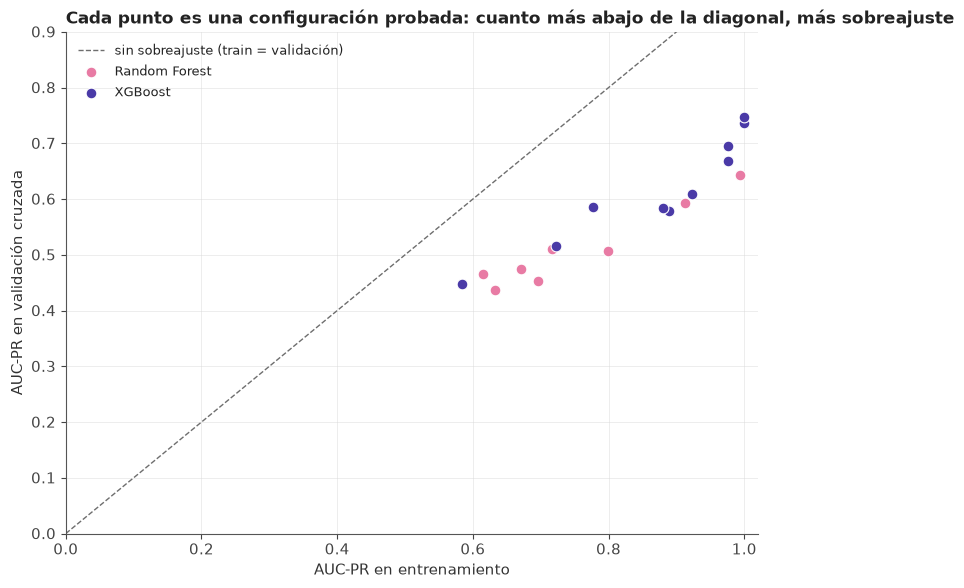

,AUC-PR validación (mejor),AUC-PR entrenamiento (mejor),brecha
Random Forest,0.6435,0.9940,0.3505
XGBoost,0.7467,1.0000,0.2533


In [21]:
fig, ax = plt.subplots(figsize=(7.8, 6))
lim = [0, 1.02]
ax.plot(lim, lim, color=GRIS, ls='--', lw=1, label='sin sobreajuste (train = validación)')
for color, nombre, rs in [(color_modelo('Random Forest'), 'Random Forest', rs_rf), (color_modelo('XGBoost'), 'XGBoost', rs_xgb)]:
    r = pd.DataFrame(rs.cv_results_)
    ax.scatter(r['mean_train_score'], r['mean_test_score'], color=color, s=60, edgecolor='white', linewidth=0.8, label=nombre, zorder=3)
ax.set_xlim(lim); ax.set_ylim(0, 0.9)
ax.set_xlabel('AUC-PR en entrenamiento'); ax.set_ylabel('AUC-PR en validación cruzada')
ax.set_title('Cada punto es una configuración probada: cuanto más abajo de la diagonal, más sobreajuste')
ax.title.set_fontsize(10.5)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

resumen_busquedas = pd.DataFrame({
    'AUC-PR validación (mejor)': [rs_rf.best_score_, rs_xgb.best_score_],
    'AUC-PR entrenamiento (mejor)': [rs_rf.cv_results_['mean_train_score'][rs_rf.best_index_], rs_xgb.cv_results_['mean_train_score'][rs_xgb.best_index_]]},
    index=['Random Forest', 'XGBoost'])
resumen_busquedas['brecha'] = resumen_busquedas.iloc[:, 1] - resumen_busquedas.iloc[:, 0]
display(resumen_busquedas.round(4))

**Comentario:** cada punto del gráfico es una configuración probada. **Todas quedan por debajo de la diagonal**: los árboles profundos rinden mucho mejor en entrenamiento que en validación, el sobreajuste no se elimina con los hiperparámetros, solo se modera. El **Random Forest** queda con un AUC-PR de validación de 0,6435 (contra 0,994 en entrenamiento, una brecha de 0,3505) y **XGBoost** con 0,7467 (contra 1,000, brecha de 0,2533): XGBoost generaliza mejor y es el que tomamos como candidato principal.

Dos advertencias sobre esta búsqueda. (1) El presupuesto es acotado (8 configuraciones para el Random Forest y 10 para XGBoost, con 3 folds), y **ambos modelos quedaron en el borde de lo que exploramos**: el mejor Random Forest usa `max_samples` = 0,6, el máximo de su rango, y el mejor XGBoost usa 500 árboles y profundidad 8, también los máximos. Con más presupuesto podrían mejorar algo más, así que la comparación entre familias es **con esta búsqueda** y no con un óptimo. (2) La mejor configuración de XGBoost usa `scale_pos_weight` = 12,646 (la raíz del cociente legítimas/fraudes), un punto intermedio entre no compensar y compensar del todo; la segunda mejor, con el cociente completo (159,93), obtuvo 0,7374. Aunque cambian otros hiperparámetros, es otra señal de que el peso de clase mueve poco el ranking (lo comparamos de forma controlada en la sección siguiente).

### 5.4 Técnicas para el desbalance: pesos de clase vs SMOTE vs submuestreo

Comparamos cuatro formas de tratar el desbalance, con dos familias de modelos (Regresión Logística y XGBoost con los mejores hiperparámetros de arriba):

1. **Sin tratamiento**.
2. **Pesos de clase** (`class_weight='balanced'` / `scale_pos_weight` = cociente legítimas/fraudes).
3. **SMOTE**: genera fraudes sintéticos interpolando entre fraudes vecinos, hasta que haya 1 fraude cada 10 legítimas.
4. **Submuestreo** aleatorio (`RandomUnderSampler`): descarta legítimas hasta llegar a la misma proporción 1:10.

El remuestreo va **dentro de un `imblearn.pipeline.Pipeline`**, de modo que solo se aplica sobre los folds de entrenamiento y la validación se hace siempre sobre datos con la distribución real. (El escalado está *antes* del remuestreo porque SMOTE usa distancias.) Para cada técnica medimos con predicciones out-of-fold (3 folds): **AUC-PR** (calidad del ranking, sin depender del umbral), el **mejor F1 posible variando el umbral**, y el **recall con el umbral 0,5** (para ver cuánto "mueve" cada técnica el punto de operación).

,modelo,técnica,AUC-PR (OOF),mejor F1 (umbral óptimo),"recall con umbral 0,5","precision con umbral 0,5",segundos
0,Regresión Logística,Sin tratamiento,0.4290,0.4953,0.2351,0.5906,0.9236
1,Regresión Logística,Pesos de clase,0.3705,0.4622,0.9561,0.0928,1.6938
2,Regresión Logística,SMOTE (1:10),0.3915,0.4752,0.7795,0.2576,1.5212
3,Regresión Logística,Submuestreo (1:10),0.3791,0.4700,0.7868,0.2521,0.5747
4,XGBoost,Sin tratamiento,0.7390,0.7003,0.5162,0.8837,19.4409
5,XGBoost,Pesos de clase,0.7479,0.7149,0.6437,0.7908,20.7929
6,XGBoost,SMOTE (1:10),0.7446,0.7050,0.5569,0.8709,23.6798
7,XGBoost,Submuestreo (1:10),0.5634,0.5532,0.7983,0.2855,4.9481


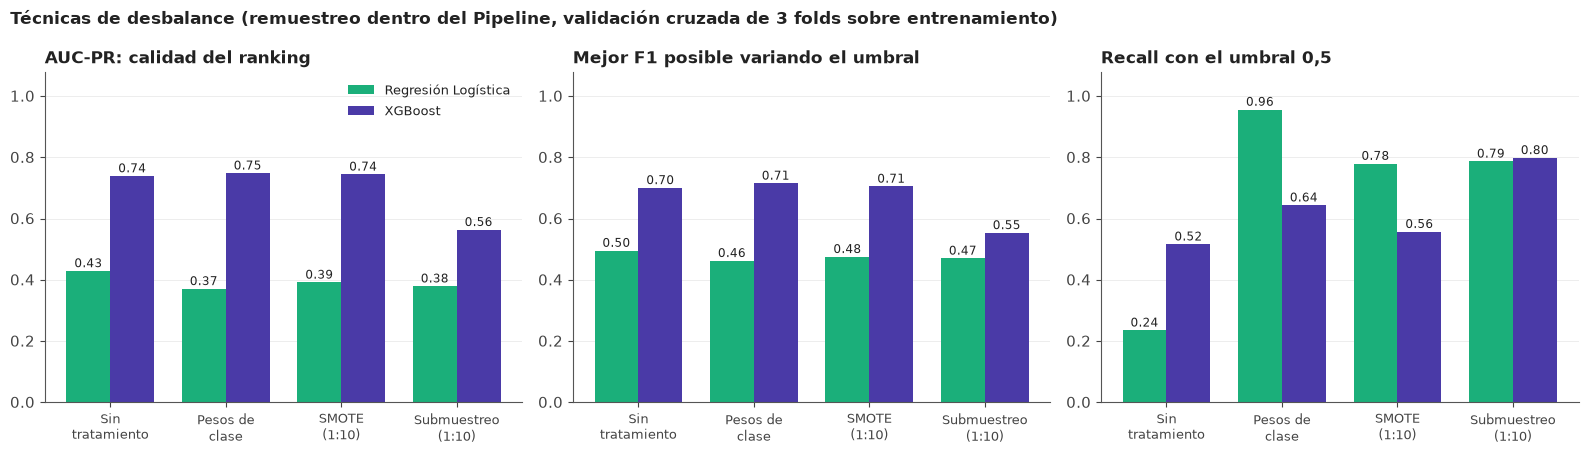

In [22]:
mejor_xgb_params = {k: v for k, v in rs_xgb.best_params_.items()}
C_lr = grid_lr.best_params_['modelo__C']

def construir_pipeline(familia, tecnica):
    if familia == 'Regresión Logística':
        modelo, cols, peso = LogisticRegression(max_iter=2000, C=C_lr), features_lineales, {'class_weight': 'balanced'}
    else:
        modelo = XGBClassifier(tree_method='hist', n_jobs=XGB_JOBS, random_state=SEED, **{**mejor_xgb_params, 'scale_pos_weight': 1.0})
        cols, peso = features_arboles, {'scale_pos_weight': float(ratio_desb)}
    pasos = [('escalado', StandardScaler())]
    if tecnica == 'Pesos de clase':
        modelo.set_params(**peso)
    elif tecnica == 'SMOTE (1:10)':
        pasos.append(('remuestreo', SMOTE(sampling_strategy=0.1, random_state=SEED)))
    elif tecnica == 'Submuestreo (1:10)':
        pasos.append(('remuestreo', RandomUnderSampler(sampling_strategy=0.1, random_state=SEED)))
    pasos.append(('modelo', modelo))
    return ImbPipeline(pasos), cols

filas = []
for familia in ['Regresión Logística', 'XGBoost']:
    for tecnica in ['Sin tratamiento', 'Pesos de clase', 'SMOTE (1:10)', 'Submuestreo (1:10)']:
        t0 = time.time()
        pipe, cols = construir_pipeline(familia, tecnica)
        oof = cross_val_predict(pipe, X_train[cols], y_train, cv=cv3, method='predict_proba')[:, 1]
        thr_b, f1_b = umbral_optimo_f1(y_train, oof)
        filas.append({'modelo': familia, 'técnica': tecnica, 'AUC-PR (OOF)': average_precision_score(y_train, oof),
                      'mejor F1 (umbral óptimo)': f1_b, 'recall con umbral 0,5': recall_score(y_train, oof >= 0.5),
                      'precision con umbral 0,5': precision_score(y_train, oof >= 0.5, zero_division=0),
                      'segundos': time.time() - t0})
comp_desbalance = pd.DataFrame(filas)
display(comp_desbalance.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
tecnicas = ['Sin tratamiento', 'Pesos de clase', 'SMOTE (1:10)', 'Submuestreo (1:10)']
for ax, met, titulo in zip(axes, ['AUC-PR (OOF)', 'mejor F1 (umbral óptimo)', 'recall con umbral 0,5'],
                           ['AUC-PR: calidad del ranking', 'Mejor F1 posible variando el umbral', 'Recall con el umbral 0,5']):
    xx = np.arange(len(tecnicas)); w = 0.38
    for k, (color, familia) in enumerate([(color_modelo('Logística'), 'Regresión Logística'), (color_modelo('XGBoost'), 'XGBoost')]):
        vals = comp_desbalance[comp_desbalance['modelo'] == familia].set_index('técnica').loc[tecnicas, met].values
        b = ax.bar(xx + (k - 0.5) * w, vals, w, color=color, label=familia)
        for bi, v in zip(b, vals):
            ax.text(bi.get_x() + bi.get_width() / 2, v + 0.012, f"{v:.2f}", ha='center', fontsize=8.5)
    ax.set_xticks(xx); ax.set_xticklabels([t.replace(' (1:10)', '\n(1:10)').replace('Sin ', 'Sin\n').replace('Pesos de ', 'Pesos de\n') for t in tecnicas], fontsize=9)
    ax.set_ylim(0, 1.08); ax.set_title(titulo); ax.grid(axis='x', visible=False)
axes[0].legend(loc='upper right')
plt.suptitle('Técnicas de desbalance (remuestreo dentro del Pipeline, validación cruzada de 3 folds sobre entrenamiento)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** la comparación controlada (mismos hiperparámetros, solo cambia la técnica) deja tres mensajes:

1. **Ninguna técnica mejora el ranking de forma clara.** Con XGBoost, el AUC-PR va de 0,739 (sin tratamiento) a 0,7479 (pesos de clase) y 0,7446 (SMOTE): diferencias de menos de 0,01, dentro del ruido de validación. Con la regresión logística, la versión sin tratamiento es la de mejor AUC-PR (0,429 contra 0,3705 con pesos, 0,3915 con SMOTE y 0,3791 con submuestreo).
2. **Lo que sí cambian los pesos y el remuestreo es el punto de operación.** Con el umbral 0,5, el recall de XGBoost pasa de 0,5162 (sin tratamiento) a 0,6437 (pesos) y 0,5569 (SMOTE), a costa de precision (0,8837, 0,7908 y 0,8709). Es un movimiento a lo largo de la misma curva precision-recall, no una mejora de la curva.
3. **El submuestreo es el peor** (AUC-PR de 0,5634 con XGBoost): descartar casi toda la clase mayoritaria tira información útil sobre qué *no* es fraude.

Como además vamos a **ajustar el umbral** explícitamente (sección 5.5), no necesitamos que ninguna técnica nos "mueva" el punto de operación por nosotros. Mantenemos la configuración de XGBoost de la búsqueda (`scale_pos_weight` = 12,646) y atacamos el desbalance con el umbral. Dos notas: este AUC-PR se calcula con 3 folds, por eso difiere del 0,772 que aparece con 5 folds en la sección 5.5 para el mismo modelo; y SMOTE interpola entre fraudes vecinos, que con variables binarias como las dummies genera valores intermedios sin sentido, por ejemplo "0,4 e-commerce" (no probamos SMOTENC, que lo resuelve, porque ni siquiera esta versión simple mejoró).

### 5.5 Umbral de decisión con predicciones out-of-fold (nunca sobre test)

Un clasificador probabilístico devuelve un score; el umbral que convierte ese score en "alertar / no alertar" es una **decisión de negocio**, no un valor sagrado de 0,5. Para elegirlo sin mirar test:

1. Para cada modelo ajustado, generamos **predicciones out-of-fold** sobre el entrenamiento con `cross_val_predict` (cada transacción es predicha por un modelo que no la vio).
2. Elegimos el umbral que maximiza el F1 **sobre esas predicciones OOF**.
3. Recién entonces entrenamos con todo el train y evaluamos en test **con ese umbral ya fijado**.

Aplicamos este procedimiento a los modelos ajustados de las secciones anteriores. Todos quedan guardados en `candidatos`.

In [23]:
candidatos = {}

def ajustar_y_evaluar(modelo, cols, cv=None):
    """Clona y entrena `modelo` sobre X_train[cols]. El umbral se elige con predicciones out-of-fold de train; test solo se usa para evaluar."""
    cv = cv or cv5
    oof = cross_val_predict(clone(modelo), X_train[cols], y_train, cv=cv, method='predict_proba')[:, 1]
    thr, f1_oof = umbral_optimo_f1(y_train, oof)
    ap_folds = [average_precision_score(y_train.iloc[v], oof[v]) for _, v in cv.split(X_train, y_train)]
    ajustado = clone(modelo).fit(X_train[cols], y_train)
    return {'modelo': ajustado, 'cols': cols, 'umbral': thr, 'oof': oof, 'f1_oof': f1_oof,
            'ap_oof': average_precision_score(y_train, oof), 'ap_oof_sd': float(np.std(ap_folds, ddof=1)),
            's_te': ajustado.predict_proba(X_test[cols])[:, 1], 's_tr': ajustado.predict_proba(X_train[cols])[:, 1]}

def agregar_candidato(nombre, modelo, cols, grupo):
    t0 = time.time()
    r = ajustar_y_evaluar(modelo, cols)
    m = registrar(nombre, r['s_te'] >= r['umbral'], r['s_te'], umbral=r['umbral'], grupo=grupo)
    m.update({'f1_umbral_05': f1_score(y_test, r['s_te'] >= 0.5), 'auc_pr_oof': r['ap_oof'], 'auc_pr_oof_sd': r['ap_oof_sd'], 'f1_oof': r['f1_oof']})
    registrar_train(nombre, r['s_tr'] >= r['umbral'], r['s_tr'])
    candidatos[nombre] = r
    print(f"{nombre:34s} umbral {r['umbral']:.3f} | OOF: AUC-PR {r['ap_oof']:.3f} (sd {r['ap_oof_sd']:.3f}), F1 {r['f1_oof']:.3f} | "
          f"TEST: precision {m['precision']:.3f}, recall {m['recall']:.3f}, F1 {m['f1']:.3f}, AUC-PR {m['auc_pr']:.3f} | {time.time() - t0:.0f} s")

agregar_candidato('Reg. Logística (ajustada)', grid_lr.best_estimator_, features_lineales, 'Lineal')
agregar_candidato('Árbol de decisión (ajustado)', grid_dt.best_estimator_, features_arboles, 'Árbol')
agregar_candidato('Random Forest (ajustado)', clone(rs_rf.best_estimator_).set_params(n_jobs=N_JOBS), features_arboles, 'Árbol')
agregar_candidato('XGBoost (ajustado)', clone(rs_xgb.best_estimator_).set_params(n_jobs=XGB_JOBS), features_arboles, 'Árbol')

Reg. Logística (ajustada)          umbral 0.191 | OOF: AUC-PR 0.431 (sd 0.055), F1 0.492 | TEST: precision 0.420, recall 0.611, F1 0.497, AUC-PR 0.458 | 2 s


Árbol de decisión (ajustado)       umbral 0.290 | OOF: AUC-PR 0.380 (sd 0.031), F1 0.420 | TEST: precision 0.432, recall 0.490, F1 0.459, AUC-PR 0.463 | 9 s


Random Forest (ajustado)           umbral 0.191 | OOF: AUC-PR 0.668 (sd 0.022), F1 0.613 | TEST: precision 0.629, recall 0.703, F1 0.664, AUC-PR 0.745 | 18 s


XGBoost (ajustado)                 umbral 0.266 | OOF: AUC-PR 0.772 (sd 0.010), F1 0.728 | TEST: precision 0.777, recall 0.699, F1 0.736, AUC-PR 0.801 | 48 s


Candidato con mayor AUC-PR out-of-fold en entrenamiento: XGBoost (ajustado)



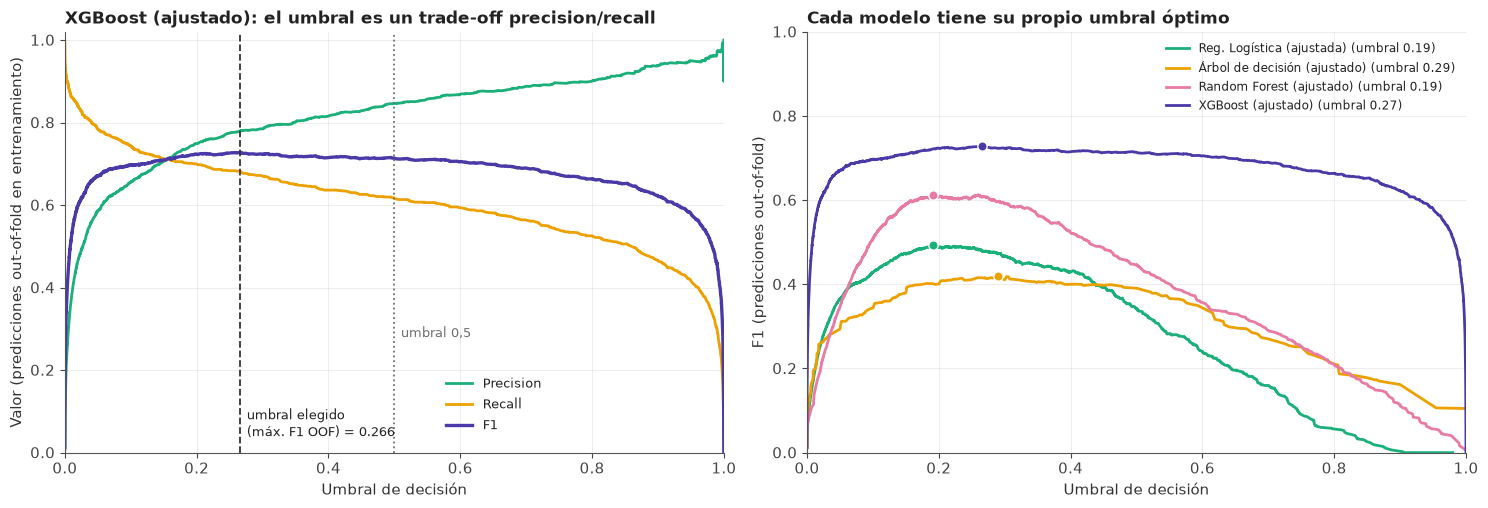

Modelo: XGBoost (ajustado)


,umbral,precision,recall,F1,alertas
"Umbral 0,5 (por defecto)",0.5000,0.8444,0.6360,0.7255,180.0000
Umbral elegido con OOF en train,0.2661,0.7767,0.6987,0.7357,215.0000
"Umbral ""oráculo"" elegido mirando test (NO válido)",0.1916,0.7521,0.7490,0.7505,238.0000


El oráculo mejora el F1 en +0.015 respecto del umbral elegido de forma honesta: ese es el optimismo de elegir el umbral con test.


In [24]:
lider = max(candidatos, key=lambda n: resultados[n]['auc_pr_oof'])
print(f"Candidato con mayor AUC-PR out-of-fold en entrenamiento: {lider}\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
# (A) precision / recall / F1 vs umbral para el candidato líder (predicciones OOF de TRAIN)
oof = candidatos[lider]['oof']
prec, rec, thr = precision_recall_curve(y_train, oof)
f1c = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
ax = axes[0]
ax.plot(thr, prec[:-1], color=COLOR_METRICA['precision'], lw=2, label='Precision')
ax.plot(thr, rec[:-1], color=COLOR_METRICA['recall'], lw=2, label='Recall')
ax.plot(thr, f1c, color=COLOR_METRICA['f1'], lw=2.4, label='F1')
u = candidatos[lider]['umbral']
ax.axvline(u, color='#333333', ls='--', lw=1.3); ax.text(u + 0.01, 0.04, f'umbral elegido\n(máx. F1 OOF) = {u:.3f}', fontsize=9.5)
ax.axvline(0.5, color=GRIS, ls=':', lw=1.3); ax.text(0.51, 0.28, 'umbral 0,5', color=GRIS, fontsize=9.5)
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor (predicciones out-of-fold en entrenamiento)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.set_title(f'{lider}: el umbral es un trade-off precision/recall'); ax.title.set_fontsize(10.5)
ax.legend(loc='lower left', bbox_to_anchor=(0.56, 0.02))

# (B) F1 OOF vs umbral para todos los candidatos
ax = axes[1]
for i, (nombre, c) in enumerate(candidatos.items()):
    p_, r_, t_ = precision_recall_curve(y_train, c['oof'])
    f_ = 2 * p_[:-1] * r_[:-1] / np.maximum(p_[:-1] + r_[:-1], 1e-12)
    ax.plot(t_, f_, color=color_modelo(nombre), lw=2, label=f"{nombre} (umbral {c['umbral']:.2f})")
    ax.scatter([c['umbral']], [c['f1_oof']], color=color_modelo(nombre), s=45, zorder=4, edgecolor='white')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('F1 (predicciones out-of-fold)'); ax.set_xlim(0, 1); ax.set_ylim(0, 1.0)      # el techo en 1,0 deja arriba un lugar libre para la leyenda
ax.set_title('Cada modelo tiene su propio umbral óptimo'); ax.legend(fontsize=8.3, loc='upper right')
plt.tight_layout(); plt.show()

# Efecto de elegir el umbral: 0,5 vs OOF vs "oráculo" (mirando test: NO es válido, solo para medir el optimismo)
s_te = candidatos[lider]['s_te']
thr_orac, f1_orac = umbral_optimo_f1(y_test, s_te)
def fila(nombre, thr):
    p = s_te >= thr
    return {'umbral': thr, 'precision': precision_score(y_test, p, zero_division=0), 'recall': recall_score(y_test, p), 'F1': f1_score(y_test, p), 'alertas': int(p.sum())}
tabla_umbral = pd.DataFrame({'Umbral 0,5 (por defecto)': fila('', 0.5), 'Umbral elegido con OOF en train': fila('', candidatos[lider]['umbral']),
                             'Umbral "oráculo" elegido mirando test (NO válido)': fila('', thr_orac)}).T
print(f"Modelo: {lider}")
display(tabla_umbral.round(4))
print(f"El oráculo mejora el F1 en {f1_orac - resultados[lider]['f1']:+.3f} respecto del umbral elegido de forma honesta: ese es el optimismo de elegir el umbral con test.")

**Comentario:** el gráfico de la izquierda muestra el trade-off en estado puro: a medida que sube el umbral, la precision sube y el recall cae, y el F1 tiene un máximo bastante plano. Elegido sobre las predicciones out-of-fold de entrenamiento, el umbral de XGBoost es **0,2661**, por debajo del 0,5 por defecto. En test, pasar de 0,5 a 0,2661 sube el F1 de 0,7255 a 0,7357 (el recall de 0,636 a 0,6987, mientras la precision baja de 0,8444 a 0,7767; se generan 215 alertas en lugar de 180).

La tabla incluye una fila "oráculo" que **no es válida** y está solo para medir el sesgo: si hubiéramos elegido el umbral mirando el test (0,1916), el F1 sería 0,7505, **0,015** por encima del honesto. Acá el sesgo es chico porque la curva de F1 es plana alrededor del máximo, pero en otros modelos o con menos datos puede ser mucho mayor, así que mantenemos la regla: *el umbral nunca se elige con el test*. El gráfico de la derecha muestra que cada modelo tiene su propio umbral óptimo (de 0,19 para el Random Forest y la logística a 0,29 para el árbol, y 0,27 para XGBoost) y que la curva de XGBoost queda por encima de las demás en casi todo el rango de umbrales.

### 5.6 Ablación: ¿aportan algo `PCA_Subset_1` y `PCA_Subset_2`?

Los dos componentes del TP2 se calcularon sobre el dataset completo y, además, el subconjunto del PCA incluía el **mes** de la transacción. Si el PCA le estuviera "contando" al modelo el calendario, podría estar ayudando por una vía que no generaliza. Comparamos el mejor candidato (**con** y **sin** los dos componentes) con la misma metodología: validación cruzada de 5 folds sobre train y evaluación en test con el umbral OOF.

,AUC-PR OOF (train),sd entre folds,F1 OOF (train),AUC-PR test,F1 test,precision test,recall test
variante,,,,,,,
Con PCA (32 variables),0.7719,0.0096,0.7280,0.8011,0.7357,0.7767,0.6987
Sin PCA (30 variables),0.7584,0.0253,0.7328,0.7783,0.7440,0.7798,0.7113


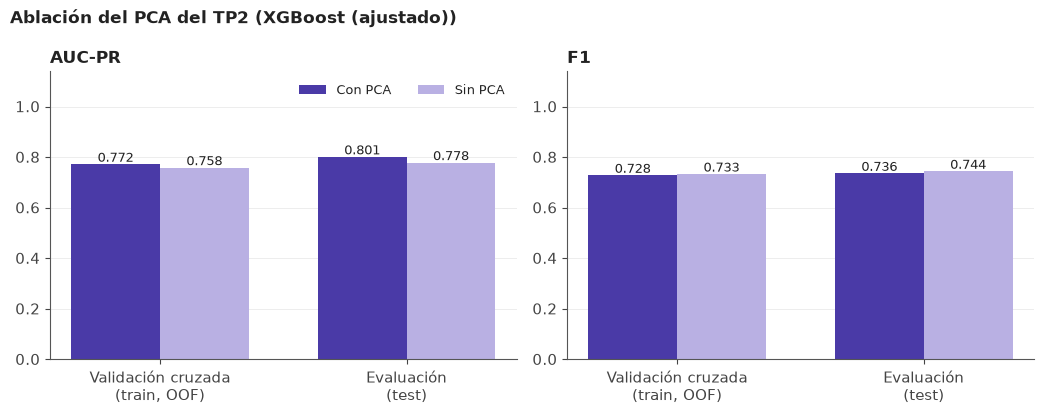

Tiempo acumulado de la sección 5: 5.9 min


In [25]:
cols_sin_pca = [c for c in features_arboles if not c.startswith('PCA_')]
base_modelo = candidatos[lider]['modelo']
abl = {'Con PCA (32 variables)': candidatos[lider],
       'Sin PCA (30 variables)': ajustar_y_evaluar(base_modelo, cols_sin_pca)}
filas = []
for nombre, r in abl.items():
    p = r['s_te'] >= r['umbral']
    filas.append({'variante': nombre, 'AUC-PR OOF (train)': r['ap_oof'], 'sd entre folds': r['ap_oof_sd'], 'F1 OOF (train)': r['f1_oof'],
                  'AUC-PR test': average_precision_score(y_test, r['s_te']), 'F1 test': f1_score(y_test, p),
                  'precision test': precision_score(y_test, p), 'recall test': recall_score(y_test, p)})
tabla_pca = pd.DataFrame(filas).set_index('variante')
display(tabla_pca.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, cols_m, titulo in zip(axes, [['AUC-PR OOF (train)', 'AUC-PR test'], ['F1 OOF (train)', 'F1 test']], ['AUC-PR', 'F1']):
    xx = np.arange(2); w = 0.36
    for k, (color, nom) in enumerate([(color_modelo('XGBoost'), 'Con PCA'), ('#b9b0e3', 'Sin PCA')]):
        vals = tabla_pca.iloc[k][cols_m].values
        b = ax.bar(xx + (k - 0.5) * w, vals, w, color=color, label=nom)
        for bi, v in zip(b, vals):
            ax.text(bi.get_x() + bi.get_width() / 2, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
    ax.set_xticks(xx); ax.set_xticklabels(['Validación cruzada\n(train, OOF)', 'Evaluación\n(test)'])
    ax.set_ylim(0, 1.14); ax.set_title(titulo); ax.grid(axis='x', visible=False)
axes[0].legend(loc='upper right', ncol=2)
plt.suptitle(f'Ablación del PCA del TP2 ({lider})', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Tiempo acumulado de la sección 5: {(time.time() - t_sec5) / 60:.1f} min")

**Comentario:** sacar los dos componentes PCA cuesta poco o nada: el AUC-PR en validación cruzada pasa de 0,7719 a 0,7584 y en test de 0,8011 a 0,7783, pero el F1 en test **sube** de 0,7357 a 0,744. Son diferencias de 0,01 a 0,02, dentro del ruido (el desvío entre folds del modelo sin PCA es 0,0253 y los intervalos de confianza de la sección 6.3 son de ±0,05). Con estos datos **no se puede afirmar que el PCA aporte señal propia** más allá de la que ya tienen las variables originales: un modelo de árboles puede recombinar esas variables por su cuenta. Lo dejamos en `features_arboles` porque es lo que entregó el TP2 y el AUC-PR out-of-fold es levemente mayor con PCA (0,7719 contra 0,7584), pero lo seguimos vigilando: en la sección 6.5 vemos que el modelo final se apoya mucho en esos componentes, y en la 8.6 vemos que no ayudan a predecir en el tiempo.

# 6. Comparación final y elección del modelo

### 6.1 Tabla comparativa

Reunimos todo lo que evaluamos en `resultados`. Las filas de los modelos **ajustados** usan el umbral elegido con predicciones out-of-fold en train (columna `umbral`); los modelos "de manual" usan 0,5; las reglas no tienen score (solo un punto de operación). Ordenamos por **AUC-PR**, nuestra métrica principal.

In [26]:
cols_tabla = ['grupo', 'umbral', 'precision', 'recall', 'f1', 'auc_pr', 'auc_roc', 'tp', 'fp', 'fn']
tabla_completa = pd.DataFrame(resultados).T[cols_tabla].copy()
for c in cols_tabla[1:]:
    tabla_completa[c] = pd.to_numeric(tabla_completa[c])
tabla_completa = tabla_completa.sort_values(['auc_pr', 'f1'], ascending=False, na_position='last')
tabla_completa.columns = ['grupo', 'umbral', 'precision', 'recall', 'F1', 'AUC-PR', 'AUC-ROC', 'VP', 'FP', 'FN']
pd.set_option('display.max_rows', 60)
display(tabla_completa.round(4))

,grupo,umbral,precision,recall,F1,AUC-PR,AUC-ROC,VP,FP,FN
XGBoost (ajustado),Árbol,0.2661,0.7767,0.6987,0.7357,0.8011,0.9877,167,48,72
HistGradientBoosting (base),Árbol,0.5000,0.3570,0.8619,0.5049,0.7538,0.9871,206,371,33
Random Forest (ajustado),Árbol,0.1915,0.6292,0.7029,0.6640,0.7452,0.9843,168,99,71
Random Forest (base),Árbol,0.5000,0.8931,0.4895,0.6324,0.7287,0.9819,117,14,122
XGBoost (base),Árbol,0.5000,0.1308,0.9038,0.2286,0.6248,0.9846,216,1435,23
Árbol de decisión (ajustado),Árbol,0.2903,0.4317,0.4895,0.4588,0.4629,0.9216,117,154,122
Reg. Logística (sin pesos),Lineal,0.5000,0.6329,0.2092,0.3145,0.4595,0.9831,50,29,189
Reg. Logística (ajustada),Lineal,0.1913,0.4195,0.6109,0.4974,0.4577,0.9822,146,202,93
Reg. Logística (balanceada),Lineal,0.5000,0.0919,0.9372,0.1674,0.4137,0.9862,224,2213,15
Árbol sin restricciones,Árbol,0.5000,0.5592,0.5732,0.5661,0.3232,0.7852,137,108,102


### 6.2 Comparación visual de los finalistas

Comparamos la **mejor regla de negocio** (el piso a superar) contra los **cuatro modelos ajustados**, todos evaluados en test con el umbral que cada uno eligió en train. La mejor regla se elige con el F1 en **train** (no mirando test).

F1 de cada regla en train: {'en dólares': 0.1522, 'e-commerce': 0.0944, 'dólares o e-commerce': 0.0957, 'dólares y e-commerce': 0.2386}
Mejor regla (elegida en train): Regla: dólares y e-commerce | su F1 en test: 0.2894


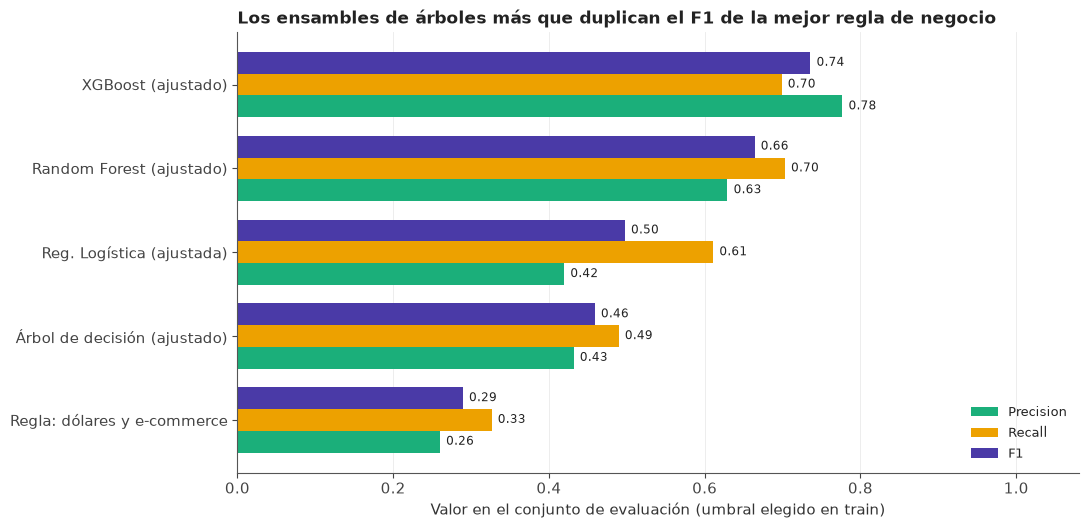

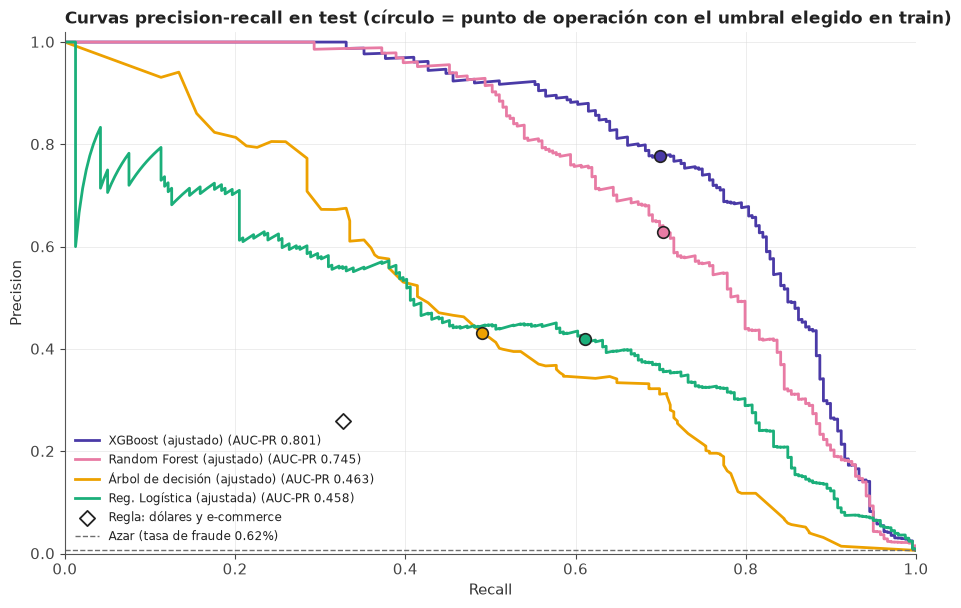

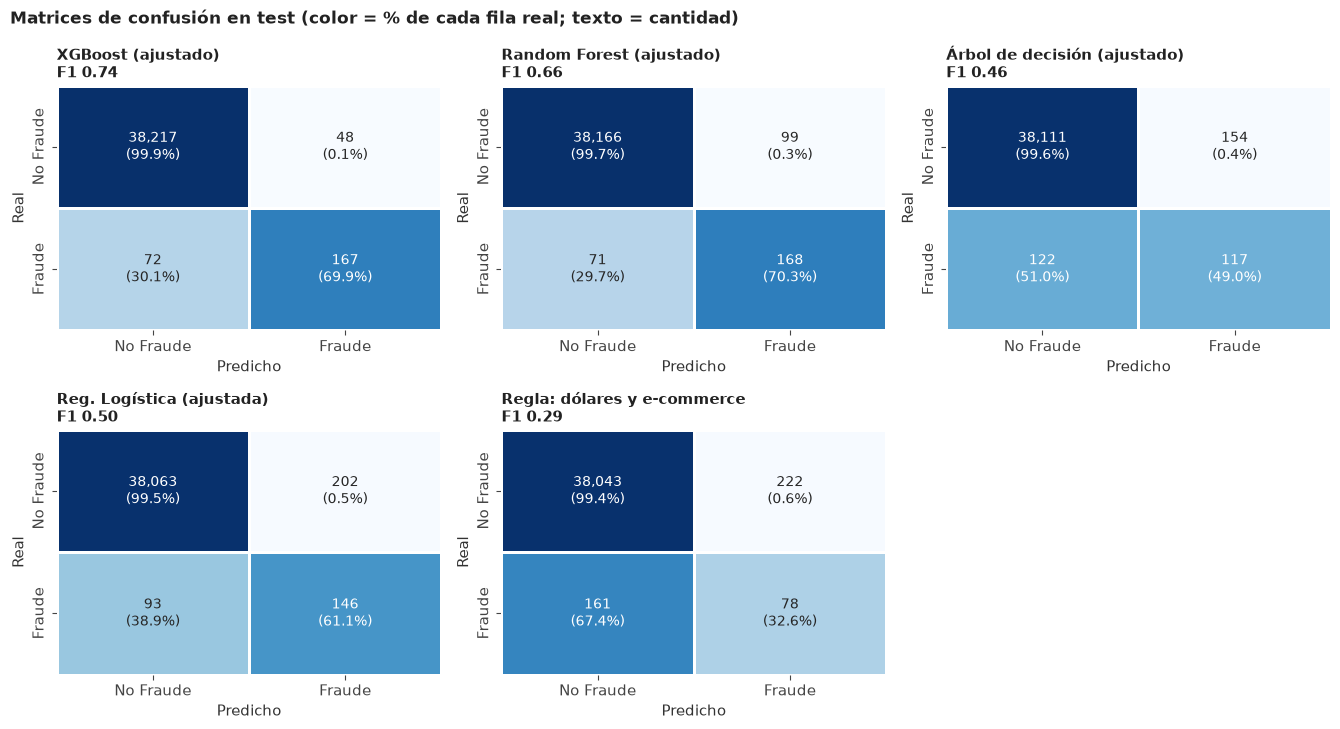

In [27]:
f1_reglas_train = {n: f1_score(y_train, f(X_train).astype(int)) for n, f in FUNC_REGLAS.items()}
mejor_regla = max(f1_reglas_train, key=f1_reglas_train.get)           # elegida con el F1 en TRAIN
print("F1 de cada regla en train:", {n.replace('Regla: ', ''): round(v, 4) for n, v in f1_reglas_train.items()})
print(f"Mejor regla (elegida en train): {mejor_regla} | su F1 en test: {resultados[mejor_regla]['f1']:.4f}")
finalistas = [mejor_regla] + list(candidatos)
orden_f1 = sorted(finalistas, key=lambda n: resultados[n]['f1'])

# (a) precision / recall / F1
fig, ax = plt.subplots(figsize=(11, 5.4))
pos = np.arange(len(orden_f1)); h = 0.26
for k, met in enumerate(['precision', 'recall', 'f1']):
    vals = [resultados[n][met] for n in orden_f1]
    b = ax.barh(pos + (k - 1) * h, vals, h, color=COLOR_METRICA[met], label={'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'}[met])
    for bi, v in zip(b, vals):
        ax.text(v + 0.008, bi.get_y() + bi.get_height() / 2, f"{v:.2f}", va='center', fontsize=8.5)
ax.set_yticks(pos); ax.set_yticklabels(orden_f1); ax.set_xlim(0, 1.08)
ax.set_xlabel('Valor en el conjunto de evaluación (umbral elegido en train)')
ax.set_title('Los ensambles de árboles más que duplican el F1 de la mejor regla de negocio')
ax.legend(loc='lower right'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

# (b) curvas PR superpuestas
orden_ap = sorted(candidatos, key=lambda n: -resultados[n]['auc_pr'])
fig, ax = plt.subplots(figsize=(9.5, 6.2))
for i, n in enumerate(orden_ap[:5]):
    pr, rc, _ = precision_recall_curve(y_test, scores_test[n])
    ax.plot(rc, pr, color=color_modelo(n), lw=2, label=f"{n} (AUC-PR {resultados[n]['auc_pr']:.3f})")
    ax.scatter(resultados[n]['recall'], resultados[n]['precision'], color=color_modelo(n), s=70, edgecolor='#222222', linewidth=1.2, zorder=5)
ax.scatter(resultados[mejor_regla]['recall'], resultados[mejor_regla]['precision'], marker='D', s=60, color='white', edgecolor='#222222', linewidth=1.3, zorder=5, label=f"{mejor_regla}")
ax.axhline(y_test.mean(), ls='--', color=GRIS, lw=1, label=f'Azar (tasa de fraude {y_test.mean():.2%})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.02)
ax.set_title('Curvas precision-recall en test (círculo = punto de operación con el umbral elegido en train)')
ax.title.set_fontsize(10.5); ax.legend(loc='lower left', fontsize=8.5)
plt.tight_layout(); plt.show()

# (c) matrices de confusión
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.4))
for ax, n in zip(axes.ravel(), orden_ap + [mejor_regla]):
    graficar_matriz_confusion(ax, n, titulo=f"{n}\nF1 {resultados[n]['f1']:.2f}")
    ax.title.set_fontsize(9.5)
for ax in axes.ravel()[len(orden_ap) + 1:]:
    ax.axis('off')
plt.suptitle('Matrices de confusión en test (color = % de cada fila real; texto = cantidad)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** los tres gráficos cuentan la misma historia desde ángulos distintos.

- **Barras:** XGBoost ajustado es el mejor en F1 (0,7357) y en precision (0,7767), con un recall de 0,6987 prácticamente igual al del Random Forest (0,7029). Le siguen el Random Forest (F1 0,664), la regresión logística ajustada (0,4974) y el árbol ajustado (0,4588). La mejor regla de negocio, "dólares y e-commerce", queda en F1 0,2894: **los dos ensambles más que duplican su F1** (XGBoost lo multiplica por 2,5), y los modelos simples (logística y árbol) lo superan por un margen más modesto.
- **Curvas PR:** la curva de XGBoost (AUC-PR 0,8011) queda por encima de la del Random Forest (0,7452) en casi todo el rango de recall, y las dos están muy por encima de la logística (0,4577) y del árbol (0,4629), que son indistinguibles entre sí. La regla de negocio queda por debajo de todas las curvas. Los círculos marcan el punto de operación de cada modelo con el umbral que eligió en train.
- **Matrices de confusión:** con XGBoost, de 239 fraudes detectamos 167 (69,9%) y dejamos pasar 72; a cambio generamos 48 falsas alarmas sobre 38.265 transacciones legítimas (0,13%).

Para ubicar cada cosa: la AUC-ROC es 0,9877 para XGBoost pero también 0,9822 para la logística y 0,9843 para el Random Forest, es decir, **no distingue casi nada** entre modelos que en AUC-PR están a 0,34 de distancia. Y el HistGradientBoosting de manual (sin ajustar) ya llega a 0,7538 de AUC-PR (tabla de arriba), así que los boosters eran buenos candidatos; nos quedamos con XGBoost, que además se ajustó en la sección 5.3. La mejor regla se eligió con el F1 en **train** (0,2386 contra 0,1522, 0,0957 y 0,0944 de las otras tres), y es la misma que gana en test.

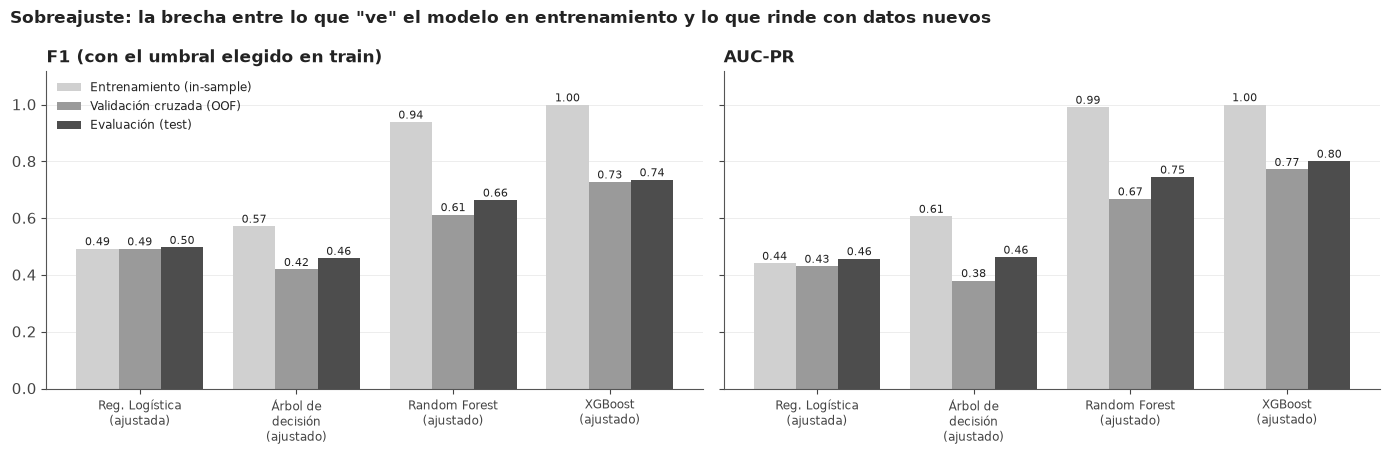

,F1 train,F1 OOF,F1 test,AUC-PR train,AUC-PR OOF,AUC-PR test
Reg. Logística (ajustada),0.4930,0.4920,0.4970,0.4410,0.4310,0.4580
Árbol de decisión (ajustado),0.5720,0.4200,0.4590,0.6070,0.3800,0.4630
Random Forest (ajustado),0.9390,0.6130,0.6640,0.9910,0.6680,0.7450
XGBoost (ajustado),0.9990,0.7280,0.7360,1.0000,0.7720,0.8010


In [28]:
# (d) entrenamiento vs validación cruzada vs evaluación: ¿cuánto sobreajusta cada modelo?
nombres_c = list(candidatos)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
xx = np.arange(len(nombres_c)); w = 0.27
for ax, met_tr, met_oof, met_te, titulo in [(axes[0], 'f1', 'f1_oof', 'f1', 'F1 (con el umbral elegido en train)'),
                                            (axes[1], 'auc_pr', 'auc_pr_oof', 'auc_pr', 'AUC-PR')]:
    tr = [info_train[n][met_tr] for n in nombres_c]
    oo = [resultados[n][met_oof] for n in nombres_c]
    te = [resultados[n][met_te] for n in nombres_c]
    for k, (vals, color, lab) in enumerate([(tr, '#d0d0d0', 'Entrenamiento (in-sample)'), (oo, '#9a9a9a', 'Validación cruzada (OOF)'), (te, '#4d4d4d', 'Evaluación (test)')]):
        b = ax.bar(xx + (k - 1) * w, vals, w, color=color, label=lab)
        for bi, v in zip(b, vals):
            ax.text(bi.get_x() + bi.get_width() / 2, v + 0.012, f"{v:.2f}", ha='center', fontsize=7.8)
    ax.set_xticks(xx); ax.set_xticklabels([textwrap.fill(etiqueta_corta(n), 14) for n in nombres_c], fontsize=8.5)
    ax.set_ylim(0, 1.12); ax.set_title(titulo); ax.grid(axis='x', visible=False)
axes[0].legend(loc='upper left', fontsize=8.5, ncol=1)
plt.suptitle('Sobreajuste: la brecha entre lo que "ve" el modelo en entrenamiento y lo que rinde con datos nuevos', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

brecha = pd.DataFrame({'F1 train': [info_train[n]['f1'] for n in nombres_c], 'F1 OOF': [resultados[n]['f1_oof'] for n in nombres_c],
                       'F1 test': [resultados[n]['f1'] for n in nombres_c],
                       'AUC-PR train': [info_train[n]['auc_pr'] for n in nombres_c], 'AUC-PR OOF': [resultados[n]['auc_pr_oof'] for n in nombres_c],
                       'AUC-PR test': [resultados[n]['auc_pr'] for n in nombres_c]}, index=nombres_c)
display(brecha.round(3))

**Comentario:** el gráfico separa tres niveles de "cuánto sabe el modelo". Los modelos con más capacidad **memorizan el entrenamiento**: XGBoost tiene un AUC-PR de 1,00 y un F1 de 0,999 evaluados sobre las mismas filas con las que se entrenó, y el Random Forest un F1 de 0,939. Pero eso no es lo que rinden con datos que no vieron: las predicciones out-of-fold (validación cruzada sobre train) dan un F1 de 0,728 y un AUC-PR de 0,772 para XGBoost (0,613 y 0,668 para el Random Forest). Los modelos simples casi no sobreajustan (la logística tiene F1 de 0,493 en train, 0,492 en OOF y 0,497 en test) pero tienen techo bajo.

Y hay dos datos que hay que mirar con cuidado. Primero, **la validación cruzada y el test coinciden** (XGBoost: AUC-PR 0,772 en OOF y 0,8011 en test; F1 0,728 y 0,7357). Es una buena noticia sobre la consistencia del procedimiento, pero **no es una confirmación independiente**: tanto los folds como el test se armaron repartiendo transacciones al azar, así que comparten el mismo sesgo (si lo hay). En la sección 8 lo ponemos a prueba. Segundo, los AUC-PR out-of-fold de los modelos que se ajustaron con esos mismos datos (todos los de esta tabla menos las reglas) son **levemente optimistas**, porque no hay validación cruzada anidada y el modelo con más configuraciones probadas se beneficia más; para comparar familias alcanza, porque las diferencias son grandes.

### 6.3 ¿Qué tan seguros estamos de las diferencias? Bootstrap sobre test

El conjunto de evaluación tiene **239 fraudes**: muy pocos, y cada métrica es en el fondo un promedio sobre esos 239 casos. Para medir cuánto ruido hay, hacemos un **bootstrap** (1.000 remuestreos con reemplazo de las transacciones de test) y calculamos intervalos de confianza del 95% (percentiles 2,5 y 97,5). Como en cada remuestreo evaluamos *a todos los modelos sobre las mismas filas*, también podemos comparar modelos de forma **pareada**: ¿la diferencia entre dos modelos es mayor que el ruido? Ojo: este bootstrap sobre test es solo un **reporte** de incertidumbre; no se usa para elegir el modelo (la elección, en 6.4, se hace únicamente con datos de entrenamiento).

Bootstrap de 4 modelos x 1.000 remuestras en 3 s


,F1,F1 IC95%,AUC-PR,AUC-PR IC95%,recall,recall IC95%,precision,precision IC95%,sd bootstrap F1
modelo,,,,,,,,,
XGBoost (ajustado),0.7360,"[0.690, 0.779]",0.8010,"[0.754, 0.845]",0.6990,"[0.640, 0.757]",0.7770,"[0.723, 0.833]",0.0230
Random Forest (ajustado),0.6640,"[0.618, 0.711]",0.7450,"[0.695, 0.794]",0.7030,"[0.649, 0.759]",0.6290,"[0.575, 0.691]",0.0240
Árbol de decisión (ajustado),0.4590,"[0.406, 0.514]",0.4630,"[0.400, 0.528]",0.4900,"[0.430, 0.558]",0.4320,"[0.378, 0.491]",0.0270
Reg. Logística (ajustada),0.4970,"[0.445, 0.546]",0.4580,"[0.397, 0.531]",0.6110,"[0.552, 0.672]",0.4200,"[0.371, 0.471]",0.0250


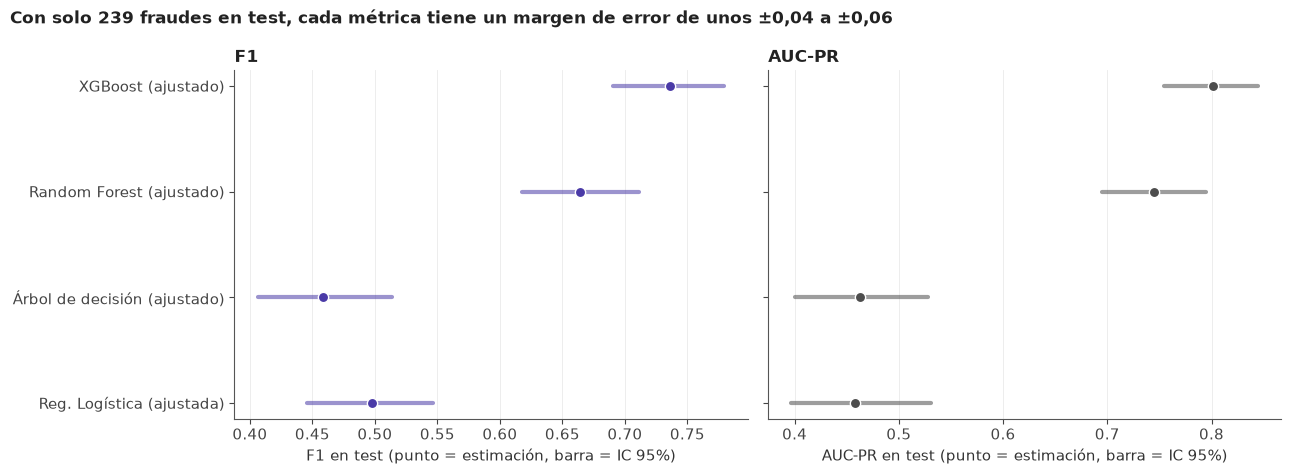

In [29]:
def preparar_ap(score):
    orden = np.argsort(-score, kind='mergesort')
    s_ord = score[orden]
    cortes = np.r_[np.where(np.diff(s_ord) != 0)[0], len(score) - 1]     # último índice de cada grupo de scores empatados
    return orden, cortes

def ap_ponderado(y_ord, w_ord, cortes):
    """average_precision con pesos por fila (equivale a una remuestra bootstrap). Misma definición que sklearn."""
    tp = np.cumsum(w_ord * y_ord)[cortes]
    tot = np.cumsum(w_ord)[cortes]
    precision = np.divide(tp, tot, out=np.zeros_like(tp), where=tot > 0)      # si en la remuestra todavía no entró ninguna fila, precision = 0 (y el recall no cambia)
    recall = tp / tp[-1]
    return float(np.sum(np.diff(np.r_[0.0, recall]) * precision))

def bootstrap(y, modelos, B=1000, grupos=None, seed=SEED):
    """modelos: {nombre: (score, pred_binaria)}. Remuestrea filas (o clientes enteros si se pasan `grupos`). Todos los modelos usan
    las mismas remuestras (comparación pareada). Devuelve {nombre: DataFrame(B x [precision, recall, f1, auc_pr])}."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(float); n = len(y)
    prep = {nom: (*preparar_ap(np.asarray(s)), np.asarray(p).astype(float)) for nom, (s, p) in modelos.items()}
    if grupos is not None:
        _, inv = np.unique(np.asarray(grupos), return_inverse=True)
        ng = inv.max() + 1
    salida = {nom: np.zeros((B, 4)) for nom in modelos}
    for b in range(B):
        if grupos is None:
            w = np.bincount(rng.integers(0, n, n), minlength=n).astype(float)
        else:
            w = np.bincount(rng.integers(0, ng, ng), minlength=ng).astype(float)[inv]
        for nom, (orden, cortes, p) in prep.items():
            tp, fp, fn = (w * y * p).sum(), (w * (1 - y) * p).sum(), (w * y * (1 - p)).sum()
            salida[nom][b] = [tp / (tp + fp) if tp + fp > 0 else 0.0, tp / (tp + fn), 2 * tp / (2 * tp + fp + fn),
                              ap_ponderado(y[orden], w[orden], cortes)]
    return {nom: pd.DataFrame(v, columns=['precision', 'recall', 'f1', 'auc_pr']) for nom, v in salida.items()}

# chequeo: con pesos uniformes, nuestro AP coincide con el de sklearn
_s = scores_test[lider]; _o, _c = preparar_ap(_s)
assert abs(ap_ponderado(np.asarray(y_test, float)[_o], np.ones(len(_s)), _c) - average_precision_score(y_test, _s)) < 1e-9

t0 = time.time()
modelos_boot = {n: (scores_test[n], preds_test[n]) for n in candidatos}
draws = bootstrap(y_test, modelos_boot, B=1000)
assert not any(d.isna().any().any() for d in draws.values()), 'el bootstrap generó valores NaN'
print(f"Bootstrap de {len(draws)} modelos x 1.000 remuestras en {time.time() - t0:.0f} s")

filas = []
for n in candidatos:
    fila = {'modelo': n}
    for met, nom in [('f1', 'F1'), ('auc_pr', 'AUC-PR'), ('recall', 'recall'), ('precision', 'precision')]:
        lo, hi = draws[n][met].quantile([0.025, 0.975])
        fila[nom] = resultados[n][met]; fila[f'{nom} IC95%'] = f"[{lo:.3f}, {hi:.3f}]"
    fila['sd bootstrap F1'] = draws[n]['f1'].std()
    filas.append(fila)
ic_tabla = pd.DataFrame(filas).set_index('modelo').sort_values('AUC-PR', ascending=False)
display(ic_tabla[['F1', 'F1 IC95%', 'AUC-PR', 'AUC-PR IC95%', 'recall', 'recall IC95%', 'precision', 'precision IC95%', 'sd bootstrap F1']].round(3))

# gráfico de intervalos
orden_ic = ic_tabla.index.tolist()[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, met, titulo, color in [(axes[0], 'f1', 'F1', COLOR_METRICA['f1']), (axes[1], 'auc_pr', 'AUC-PR', '#4d4d4d')]:
    for i, n in enumerate(orden_ic):
        lo, hi = draws[n][met].quantile([0.025, 0.975])
        ax.plot([lo, hi], [i, i], color=color, lw=3, alpha=0.55, solid_capstyle='round')
        ax.scatter(resultados[n][met], i, color=color, s=55, edgecolor='white', zorder=4)
    ax.set_yticks(range(len(orden_ic))); ax.set_yticklabels(orden_ic); ax.set_xlabel(f'{titulo} en test (punto = estimación, barra = IC 95%)')
    ax.set_title(titulo); ax.grid(axis='y', visible=False)
plt.suptitle('Con solo 239 fraudes en test, cada métrica tiene un margen de error de unos ±0,04 a ±0,06', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** con apenas 239 fraudes en test, cada métrica tiene un margen de error considerable. Para XGBoost, el F1 de 0,7357 tiene un intervalo de confianza del 95% de [0,690, 0,779] (desvío bootstrap 0,023), el AUC-PR de 0,8011 va de 0,754 a 0,845, el recall de 0,6987 de 0,640 a 0,757 y la precision de 0,7767 de 0,723 a 0,833. Es decir, hay que leer estos números como "F1 de 0,74 ± 0,04". Para los demás modelos el ruido es parecido (el F1 de la logística, [0,445, 0,546], y el del árbol, [0,406, 0,514]): **la logística y el árbol son indistinguibles entre sí** (F1 de 0,497 contra 0,459, AUC-PR de 0,458 contra 0,463, con intervalos que se superponen casi por completo).

Esto sirve también para no sobreinterpretar diferencias chicas: cualquier diferencia de F1 menor a ~0,05 entre dos modelos no se puede distinguir con este test. Entre XGBoost y el Random Forest los intervalos se tocan, así que hace falta una comparación más fina (pareada), que hacemos a continuación.

,AUC-PR OOF (train),sd entre folds,F1 OOF (train)
XGBoost (ajustado),0.7719,0.0096,0.7280
Random Forest (ajustado),0.6683,0.0215,0.6129
Reg. Logística (ajustada),0.4310,0.0548,0.4924
Árbol de decisión (ajustado),0.3804,0.0315,0.4196


A = XGBoost (ajustado)
B = Random Forest (ajustado)
Diferencia A - B (bootstrap pareado, 1.000 remuestras):


,diferencia observada,"IC 2,5%","IC 97,5%",P(A > B) en el bootstrap
F1,0.0720,0.0270,0.1140,0.9990
AUC-PR,0.0560,0.0260,0.0880,0.9990
recall,-0.0040,-0.0580,0.0510,0.4350
precision,0.1480,0.0940,0.2000,1.0000


¿El IC 95% de la diferencia incluye el 0?  F1: False | AUC-PR: False


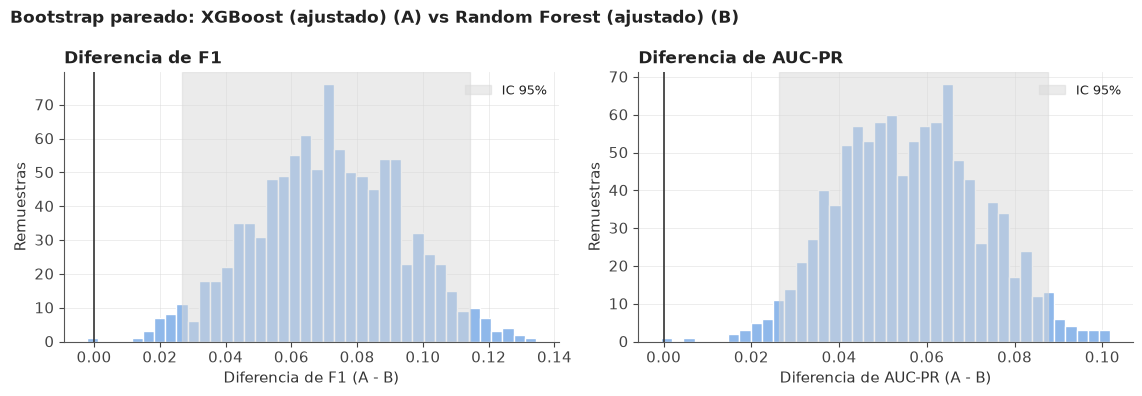

In [30]:
# Los dos mejores según el AUC-PR out-of-fold (criterio basado SOLO en train) y, como REPORTE de incertidumbre, su comparación pareada sobre TEST
ranking = pd.DataFrame({n: {'AUC-PR OOF (train)': resultados[n]['auc_pr_oof'], 'sd entre folds': resultados[n]['auc_pr_oof_sd'],
                            'F1 OOF (train)': resultados[n]['f1_oof']} for n in candidatos}).T.sort_values('AUC-PR OOF (train)', ascending=False)
display(ranking.round(4))
top2 = ranking.index[:2].tolist()
A, B_ = top2
dif = pd.DataFrame({'F1': draws[A]['f1'] - draws[B_]['f1'], 'AUC-PR': draws[A]['auc_pr'] - draws[B_]['auc_pr'],
                    'recall': draws[A]['recall'] - draws[B_]['recall'], 'precision': draws[A]['precision'] - draws[B_]['precision']})
res_dif = pd.DataFrame({'diferencia observada': [resultados[A][m] - resultados[B_][m] for m in ['f1', 'auc_pr', 'recall', 'precision']],
                        'IC 2,5%': dif.quantile(0.025).values, 'IC 97,5%': dif.quantile(0.975).values,
                        'P(A > B) en el bootstrap': (dif > 0).mean().values}, index=['F1', 'AUC-PR', 'recall', 'precision'])
print(f"A = {A}\nB = {B_}\nDiferencia A - B (bootstrap pareado, 1.000 remuestras):")
display(res_dif.round(3))
print("¿El IC 95% de la diferencia incluye el 0?  F1:", bool(res_dif.loc['F1', 'IC 2,5%'] <= 0 <= res_dif.loc['F1', 'IC 97,5%']),
      "| AUC-PR:", bool(res_dif.loc['AUC-PR', 'IC 2,5%'] <= 0 <= res_dif.loc['AUC-PR', 'IC 97,5%']))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
for ax, met in zip(axes, ['F1', 'AUC-PR']):
    ax.hist(dif[met], bins=40, color='#8fb8ea', edgecolor='white')
    ax.axvline(0, color='#333333', lw=1.2)
    lo, hi = dif[met].quantile([0.025, 0.975])
    ax.axvspan(lo, hi, color=GRIS_CLARO, alpha=0.5, label='IC 95%')
    ax.set_xlabel(f'Diferencia de {met} (A - B)'); ax.set_ylabel('Remuestras'); ax.set_title(f'Diferencia de {met}'); ax.legend()
plt.suptitle(f'Bootstrap pareado: {A} (A) vs {B_} (B)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** esta comparación es un **reporte** de la incertidumbre sobre test: no interviene en la elección del modelo, que se decide en la sección 6.4 solo con datos de entrenamiento. Como en cada remuestra los modelos se evalúan sobre las mismas transacciones, la diferencia entre XGBoost (A) y el Random Forest (B) se puede medir con menos ruido que comparando sus intervalos por separado. El **F1 de XGBoost es 0,072 más alto** (IC 95% de la diferencia: [0,027, 0,114]) y el **AUC-PR 0,056 más alto** ([0,026, 0,088]); en ninguno de los dos el intervalo incluye al 0, y A le gana a B en el 99,9% de las remuestras. La ventaja viene sobre todo de la **precision** (+0,148, [0,094, 0,200]), mientras que en el recall no hay diferencia (-0,004, [-0,058, 0,051]).

### 6.4 Elección del modelo final y del umbral

**Criterio explícito, que usa solo datos de entrenamiento**: (1) el modelo con mayor **AUC-PR out-of-fold en train**; (2) si su diferencia con el segundo está **dentro del ruido** medido también en train (el IC 95% de un **bootstrap pareado sobre las predicciones out-of-fold, remuestreando clientes enteros,** incluye el 0, o la diferencia media por fold es menor que su desvío entre folds), se declara un **empate técnico** y se desempata por **simplicidad y costo operativo** (regresión logística < árbol < Random Forest < XGBoost); (3) el **umbral** es el que maximiza el F1 sobre las predicciones OOF del modelo elegido. El test no interviene en la elección: el bootstrap pareado de la sección 6.3 es solo un **reporte** de cuánta incertidumbre tiene esa diferencia.

In [31]:
# Criterio (1): el de mayor AUC-PR out-of-fold en train (`lider`).
# Criterio (2): ¿su diferencia con el segundo está dentro del ruido? Se mide SOLO con train: bootstrap pareado sobre las predicciones
# out-of-fold (mismas remuestras para los dos modelos) y diferencia de AUC-PR fold por fold. Si hay empate técnico, se desempata por simplicidad.
orden_simplicidad = ['Reg. Logística (ajustada)', 'Árbol de decisión (ajustado)', 'Random Forest (ajustado)', 'XGBoost (ajustado)']
assert A == lider
t0 = time.time()
oof_A, oof_B = candidatos[A]['oof'], candidatos[B_]['oof']
g_tr = df.loc[X_train.index, 'Cliente_Id'].values          # las transacciones de un cliente no son independientes: se remuestrean clientes enteros
d_oof = bootstrap(y_train, {A: (oof_A, (oof_A >= candidatos[A]['umbral']).astype(int)),
                            B_: (oof_B, (oof_B >= candidatos[B_]['umbral']).astype(int))}, B=1000, grupos=g_tr)
dif_oof = d_oof[A]['auc_pr'] - d_oof[B_]['auc_pr']
ic_oof = dif_oof.quantile([0.025, 0.975])
dif_folds = np.array([average_precision_score(y_train.iloc[v], oof_A[v]) - average_precision_score(y_train.iloc[v], oof_B[v])
                      for _, v in cv5.split(X_train, y_train)])
print(f"Diferencia de AUC-PR out-of-fold (A - B) en TRAIN: {average_precision_score(y_train, oof_A) - average_precision_score(y_train, oof_B):.4f} | "
      f"IC 95% bootstrap pareado por cliente: [{ic_oof.iloc[0]:.4f}, {ic_oof.iloc[1]:.4f}] ({time.time() - t0:.0f} s)")
print(f"Diferencia por fold (5 folds): {np.round(dif_folds, 3).tolist()} | media {dif_folds.mean():.4f} vs desvío entre folds {dif_folds.std(ddof=1):.4f}")
dentro_del_ruido = bool((ic_oof.iloc[0] <= 0 <= ic_oof.iloc[1]) or (abs(dif_folds.mean()) < dif_folds.std(ddof=1)))
NOMBRE_FINAL = min([A, B_], key=orden_simplicidad.index) if dentro_del_ruido else A
print(f"Mejor AUC-PR out-of-fold: {A} | segundo: {B_}")
print(f"¿Diferencia dentro del ruido (criterio solo con train)? {dentro_del_ruido}  ->  modelo final: {NOMBRE_FINAL}")

Diferencia de AUC-PR out-of-fold (A - B) en TRAIN: 0.1036 | IC 95% bootstrap pareado por cliente: [0.0715, 0.1393] (13 s)
Diferencia por fold (5 folds): [0.135, 0.102, 0.096, 0.089, 0.099] | media 0.1041 vs desvío entre folds 0.0179
Mejor AUC-PR out-of-fold: XGBoost (ajustado) | segundo: Random Forest (ajustado)
¿Diferencia dentro del ruido (criterio solo con train)? False  ->  modelo final: XGBoost (ajustado)


**Comentario:** aplicando el criterio, que usa solo datos de entrenamiento, el **modelo final es XGBoost ajustado**. (1) Es el de mayor AUC-PR out-of-fold en train: 0,7719, con un desvío de 0,0096 entre folds, contra 0,6683 y 0,0215 del Random Forest. (2) Su ventaja no está dentro del ruido medido también con train: la diferencia de AUC-PR out-of-fold es de 0,1036, con un IC 95% del bootstrap pareado por cliente de [0,0715, 0,1393], y por fold la diferencia media es de 0,1041 contra un desvío entre folds de 0,0179 (las cinco diferencias por fold son positivas, entre 0,089 y 0,135). No hay empate técnico, así que no hace falta desempatar por simplicidad. (3) Sus hiperparámetros salieron de la búsqueda de la sección 5.3 (500 árboles de profundidad 8, `learning_rate` 0,1, `scale_pos_weight` = 12,646) y el **umbral final es 0,2661**, el que maximiza el F1 sobre las predicciones out-of-fold del entrenamiento. Con ese umbral, y sin haber usado el test para nada de lo anterior, el resultado en la partición de evaluación es: **precision 0,7767, recall 0,6987, F1 0,7357 y AUC-PR 0,8011** (IC 95% del F1: [0,690, 0,779]), con 167 aciertos, 48 falsas alarmas y 72 fraudes que se escapan.

Dos aclaraciones para no pasarse de rosca. El accuracy de 0,9969 que aparece en el reporte no dice nada (el baseline de "siempre No Fraude" tiene 0,9938). Y estos números son los de la partición que pide la consigna; en la sección 8 vamos a ver cuánto de esto sobrevive en condiciones más realistas. Las variables `modelo_final`, `umbral_final`, `y_proba_final` e `y_pred_final` quedan definidas desde acá para el resto del notebook.

In [32]:
modelo_final = candidatos[NOMBRE_FINAL]['modelo']                     # estimador YA entrenado con todo train
umbral_final = float(candidatos[NOMBRE_FINAL]['umbral'])              # elegido con predicciones out-of-fold de train
assert candidatos[NOMBRE_FINAL]['cols'] == features_arboles, "el modelo final debe aceptar X_test completo"
y_proba_final = modelo_final.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= umbral_final).astype(int)
assert np.allclose(y_proba_final, scores_test[NOMBRE_FINAL])

print(f"MODELO FINAL: {NOMBRE_FINAL}")
claves_hp = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight', 'reg_lambda', 'scale_pos_weight', 'tree_method']
hp = modelo_final.get_params()
print("Hiperparámetros:", {k: (round(hp[k], 3) if isinstance(hp[k], float) else hp[k]) for k in claves_hp if k in hp})
print(f"UMBRAL FINAL (elegido en train, OOF): {umbral_final:.4f}")
reportar(NOMBRE_FINAL)
lo, hi = draws[NOMBRE_FINAL]['f1'].quantile([0.025, 0.975])
print(f"   IC 95% bootstrap del F1: [{lo:.3f}, {hi:.3f}]")

MODELO FINAL: XGBoost (ajustado)
Hiperparámetros: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'reg_lambda': 1, 'scale_pos_weight': 12.646, 'tree_method': 'hist'}
UMBRAL FINAL (elegido en train, OOF): 0.2661
XGBoost (ajustado) | umbral 0.266
   accuracy 0.9969 (engañosa) | precision 0.7767 | recall 0.6987 | F1 0.7357 | AUC-PR 0.8011 | AUC-ROC 0.9877
   verdaderos+ 167 | falsos+ 48 | falsos- 72 | verdaderos- 38,217
   IC 95% bootstrap del F1: [0.690, 0.779]


### 6.5 ¿Qué usa el modelo final? Importancia por permutación sobre test

La importancia por impureza/ganancia (sección 4.4) está sesgada hacia variables continuas y se *diluye* entre variables que contienen la misma información (por ejemplo `Trx_Importe` y `Trx_Importe_log`: al permutar una, el modelo se apoya en la otra y la caída parece pequeña). La **importancia por permutación** mide cuánto *empeora* el AUC-PR en test cuando se "rompe" una variable mezclando sus valores. Para no subestimar a las variables duplicadas, **permutamos por grupos de variables relacionadas** (todas las columnas de un grupo se mezclan juntas con la misma permutación).

Modelo final (con PCA): AUC-PR de referencia en test 0.8011 | calculado en 15 s


,grupo,caída del AUC-PR,sd
0,Componentes PCA del TP2,0.7534,0.0046
1,Hábitos del cliente,0.2370,0.0158
2,Importe de la transacción,0.1453,0.0148
3,Rubro de la transacción,0.0968,0.0064
4,Edad del cliente,0.0934,0.0090
5,Historial: gasto promedio y desvío del importe,0.0891,0.0078
6,Cliente presente (presencial),0.0578,0.0046
7,Historial: cantidad de transacciones,0.0541,0.0059
8,Tiempo desde la transacción anterior,0.0372,0.0097
9,Hora de la transacción,0.0327,0.0029



Sin PCA: AUC-PR de referencia en test 0.7783


,grupo,caída del AUC-PR,sd
0,Hábitos del cliente,0.3349,0.0197
1,Rubro de la transacción,0.3052,0.0193
2,Historial: cantidad de transacciones,0.1437,0.0078
3,Historial: gasto promedio y desvío del importe,0.1405,0.0115
4,Importe de la transacción,0.1361,0.0117
5,Edad del cliente,0.0912,0.0113
6,Canal / tipo de terminal,0.0746,0.0085
7,Moneda (dólares / pesos),0.0470,0.0017
8,Tiempo desde la transacción anterior,0.0404,0.0092
9,Hora de la transacción,0.0378,0.0037


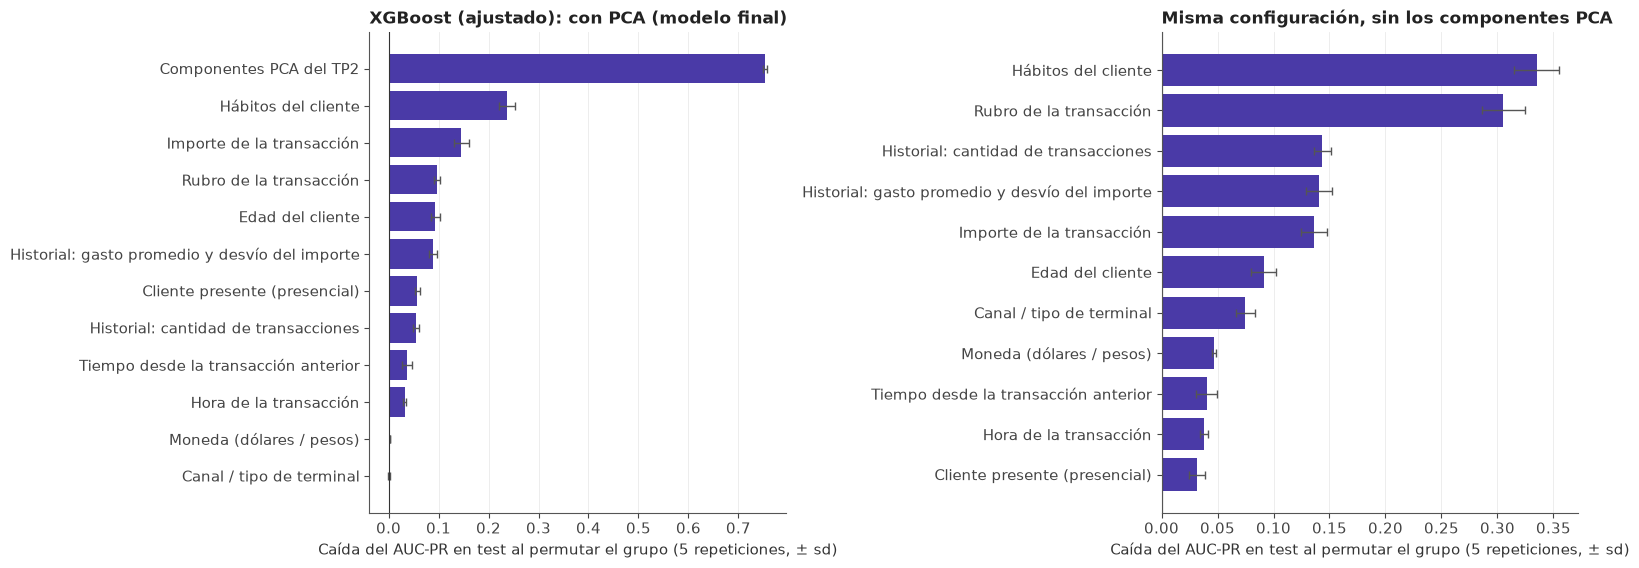

In [33]:
GRUPOS_VARIABLES = {
    'Moneda (dólares / pesos)': ['Trx_Moneda'],
    'Importe de la transacción': ['Trx_Importe', 'Trx_Importe_log', 'Es_Outlier_Importe'],
    'Canal / tipo de terminal': [c for c in features_arboles if c.startswith('TipoTerminal_Agrupamiento')],
    'Rubro de la transacción': [c for c in features_arboles if c.startswith('Categoria_Rubro_')],
    'Cliente presente (presencial)': ['Presencia_Cliente'],
    'Hora de la transacción': ['Hora_sin', 'Hora_cos'],
    'Tiempo desde la transacción anterior': ['Tiempo_Entre_Trx_Horas'],
    'Historial: cantidad de transacciones': ['Cliente_CantTransacciones'],
    'Historial: gasto promedio y desvío del importe': ['Cliente_GastoPromedio', 'Cliente_GastoPromedio_log', 'Cliente_Desvio_Importe_Abs'],
    'Hábitos del cliente': [c for c in features_arboles if c.startswith(('Cliente_DiaFav', 'Cliente_HoraFav', 'Cliente_RubroFavorito', 'Cliente_ProporcionVirtual', 'Cliente_CV'))] + ['Cliente_DiaSemanaFavorito'],
    'Edad del cliente': ['Cliente_Edad'],
    'Componentes PCA del TP2': ['PCA_Subset_1', 'PCA_Subset_2']}
assert sorted(sum(GRUPOS_VARIABLES.values(), [])) == sorted(features_arboles), "los grupos deben cubrir todas las variables exactamente una vez"

def importancia_permutacion(modelo, Xe, ye, grupos, n_rep=5, seed=SEED):
    rng = np.random.default_rng(seed)
    base = average_precision_score(ye, modelo.predict_proba(Xe)[:, 1])
    filas = []
    for nombre, cols in grupos.items():
        caidas = []
        for _ in range(n_rep):
            Xp = Xe.copy()
            Xp[cols] = Xe[cols].values[rng.permutation(len(Xe))]
            caidas.append(base - average_precision_score(ye, modelo.predict_proba(Xp)[:, 1]))
        filas.append((nombre, float(np.mean(caidas)), float(np.std(caidas))))
    return base, pd.DataFrame(filas, columns=['grupo', 'caída del AUC-PR', 'sd']).sort_values('caída del AUC-PR', ascending=False).reset_index(drop=True)

t0 = time.time()
ap_base, imp_perm = importancia_permutacion(modelo_final, X_test, y_test, GRUPOS_VARIABLES, n_rep=5)
print(f"Modelo final (con PCA): AUC-PR de referencia en test {ap_base:.4f} | calculado en {time.time() - t0:.0f} s")
display(imp_perm.round(4))

# Misma configuración entrenada SIN los componentes PCA (la ablación de la sección 5.6): permite leer la importancia de moneda, canal, rubro, etc.
modelo_sin_pca = abl['Sin PCA (30 variables)']['modelo']
grupos_sin_pca = {k: v for k, v in GRUPOS_VARIABLES.items() if k != 'Componentes PCA del TP2'}
ap_base2, imp_perm2 = importancia_permutacion(modelo_sin_pca, X_test[cols_sin_pca], y_test, grupos_sin_pca, n_rep=5)
print(f"\nSin PCA: AUC-PR de referencia en test {ap_base2:.4f}")
display(imp_perm2.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
for ax, tabla, titulo in [(axes[0], imp_perm, f'{NOMBRE_FINAL}: con PCA (modelo final)'), (axes[1], imp_perm2, 'Misma configuración, sin los componentes PCA')]:
    d = tabla.iloc[::-1]
    ax.barh(d['grupo'], d['caída del AUC-PR'], xerr=d['sd'], color=color_modelo(NOMBRE_FINAL), error_kw={'ecolor': '#555555', 'capsize': 3, 'lw': 1})
    ax.axvline(0, color='#333333', lw=0.8)
    ax.set_xlabel('Caída del AUC-PR en test al permutar el grupo (5 repeticiones, ± sd)')
    ax.set_title(titulo); ax.title.set_fontsize(10.5); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**Comentario:** el modelo final depende muchísimo de los **componentes PCA**: al permutarlos, el AUC-PR de test cae 0,7534, es decir, de 0,8011 a poco más de 0,04. No significa que el PCA contenga información que no esté en las demás variables (en la ablación de la sección 5.6 el modelo sin PCA rinde casi igual), sino que el modelo *aprendió a apoyarse en ellos* como un resumen compacto de varias variables a la vez. Por eso, para leer qué información usa el modelo, miramos el panel derecho: la misma configuración entrenada **sin PCA** (AUC-PR de referencia 0,7783).

Ahí aparecen, en orden: los **hábitos del cliente** (día, hora y rubro favoritos, proporción de operaciones virtuales y regularidad: caída de 0,3349), el **rubro** de la transacción (0,3052), el historial de **cantidad de transacciones** (0,1437) y de **gasto** (0,1405), el **importe** (0,1361), la **edad del cliente** (0,0912) y el **canal** (0,0746). Lo llamativo es que buena parte de la importancia está en variables que describen **al cliente y no a la operación puntual**: la edad es una variable *estática del cliente*, que no cambia entre sus transacciones legítimas y las fraudulentas, y sin embargo permutarla cuesta 0,0912 de AUC-PR (0,0934 en el modelo con PCA; y como el PCA también contiene la edad, la cifra **subestima** cuánto la usa el modelo). La tasa de fraude sí varía por tramo de edad (lo vemos en la sección 9.1), así que no es una variable irrelevante; pero que una variable estática pese tanto sugiere que, junto con los hábitos y el historial, sirve más para **reconocer a qué cliente pertenece la transacción** que para describir la operación. Lo retomamos en la sección 8, porque tiene consecuencias para la evaluación. Moneda y canal pesan poco en el panel izquierdo (0,0032 y 0,001) porque su información también está dentro del PCA.

### 6.6 Calibración: ¿los scores se pueden leer como probabilidades?

,n,score_medio,tasa_observada
"[0.00, 0.01)",37989,0.0001,0.0007
"[0.01, 0.05)",186,0.0227,0.0753
"[0.05, 0.10)",46,0.0692,0.1087
"[0.10, 0.20)",49,0.1402,0.3061
"[0.20, 0.40)",45,0.2895,0.4889
"[0.40, 0.60)",23,0.5210,0.3913
"[0.60, 0.80)",19,0.6990,0.6842
"[0.80, 1.00)",147,0.9721,0.9048


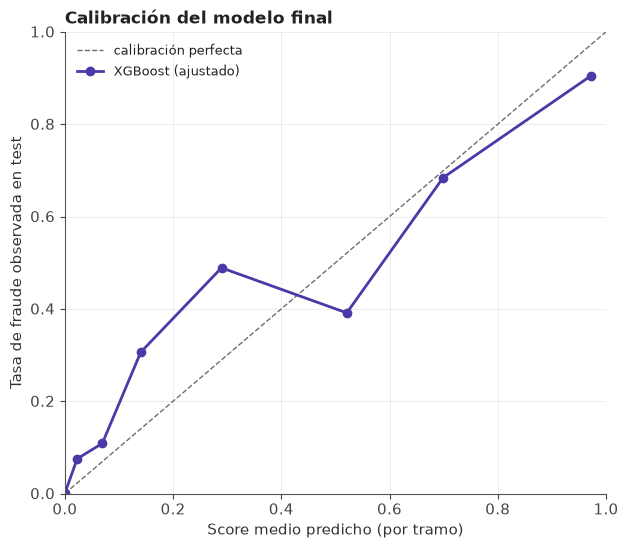

In [34]:
# Calibración: ¿los scores del modelo final se pueden leer como probabilidades?
bordes = [0, 0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0001]
cat = pd.cut(y_proba_final, bordes, right=False)
calib = pd.DataFrame({'score': y_proba_final, 'fraude': y_test.values}).groupby(cat, observed=True).agg(n=('fraude', 'size'), score_medio=('score', 'mean'), tasa_observada=('fraude', 'mean'))
calib.index = [f"[{i.left:.2f}, {min(i.right, 1):.2f})" for i in calib.index]
display(calib.round(4))

fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.plot([0, 1], [0, 1], ls='--', color=GRIS, lw=1, label='calibración perfecta')
ax.plot(calib['score_medio'], calib['tasa_observada'], color=color_modelo(NOMBRE_FINAL), marker='o', lw=2, label=NOMBRE_FINAL)
ax.set_xlabel('Score medio predicho (por tramo)'); ax.set_ylabel('Tasa de fraude observada en test'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Calibración del modelo final'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Comentario:** los scores de XGBoost (que entrenó con `scale_pos_weight` = 12,646) **no se pueden leer como probabilidades**. En el extremo bajo coinciden bien (transacciones con score menor a 0,01: 0,0001 predicho contra 0,0007 observado), pero entre 0,01 y 0,40 el modelo **subestima el riesgo**: por ejemplo, las transacciones con score entre 0,10 y 0,20 (score medio 0,1402) resultaron ser fraude el 30,61% de las veces, y las de 0,20 a 0,40 (0,2895) el 48,89%. En el tramo más alto sobreestima algo: con score de 0,80 o más, el score medio es 0,9721 y la tasa observada 0,9048. Son tramos con pocos casos (entre 19 y 49 transacciones en el rango medio), así que hay ruido, pero el patrón de subestimación en los scores bajos y medios se repite en cuatro tramos seguidos. Conclusión práctica: los scores sirven para **ordenar** y para fijar un umbral, pero si se quisieran usar como probabilidades (por ejemplo para calcular una pérdida esperada) habría que calibrarlos antes (Platt o isotónica sobre predicciones out-of-fold).

# 7. Lectura de negocio del modelo final

Con el modelo y el umbral elegidos, traducimos los resultados a preguntas que se hace el equipo de prevención: ¿en qué tipos de transacción funciona bien y en cuáles no? ¿cuántos fraudes encontramos si solo podemos revisar una fracción chica de las operaciones? ¿cuánto dinero se escapa? ¿y si el costo de dejar pasar un fraude fuera mucho mayor que el de una falsa alarma?

### 7.1 Desempeño por segmento

Un único F1 global esconde diferencias grandes entre tipos de transacción. Evaluamos el modelo final **en test** sobre distintos recortes (con intervalo de confianza bootstrap por cliente (remuestreando clientes enteros) para el F1 de cada uno; cuando un segmento tiene pocos fraudes el intervalo es ancho y hay que leerlo con cautela).

,transacciones,fraudes,alertas,aciertos (VP),falsas alarmas (FP),precision,recall,F1,F1 IC lo,F1 IC hi,AUC-PR
Moneda: pesos,37365,115,100,67,33,0.6700,0.5830,0.6230,0.5240,0.7010,0.6400
Moneda: dólares,1139,124,115,100,15,0.8700,0.8060,0.8370,0.7700,0.8910,0.9230
Canal: e-commerce,3263,167,159,128,31,0.8050,0.7660,0.7850,0.7130,0.8380,0.8600
Canal: resto,35241,72,56,39,17,0.6960,0.5420,0.6090,0.4900,0.7180,0.6560
Presencia: presencial,25446,34,20,12,8,0.6000,0.3530,0.4440,0.2530,0.6040,0.4730
Presencia: no presencial,13058,205,195,155,40,0.7950,0.7560,0.7750,0.7180,0.8240,0.8510
Rubro: con rubro,17806,239,215,167,48,0.7770,0.6990,0.7360,0.6740,0.7860,0.8010
Rubro: SIN_RUBRO,20698,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
Importe en pesos: bajo,13148,23,23,13,10,0.5650,0.5650,0.5650,0.3330,0.7430,0.5950
Importe en pesos: medio,11783,20,16,11,5,0.6880,0.5500,0.6110,0.3390,0.7830,0.6380


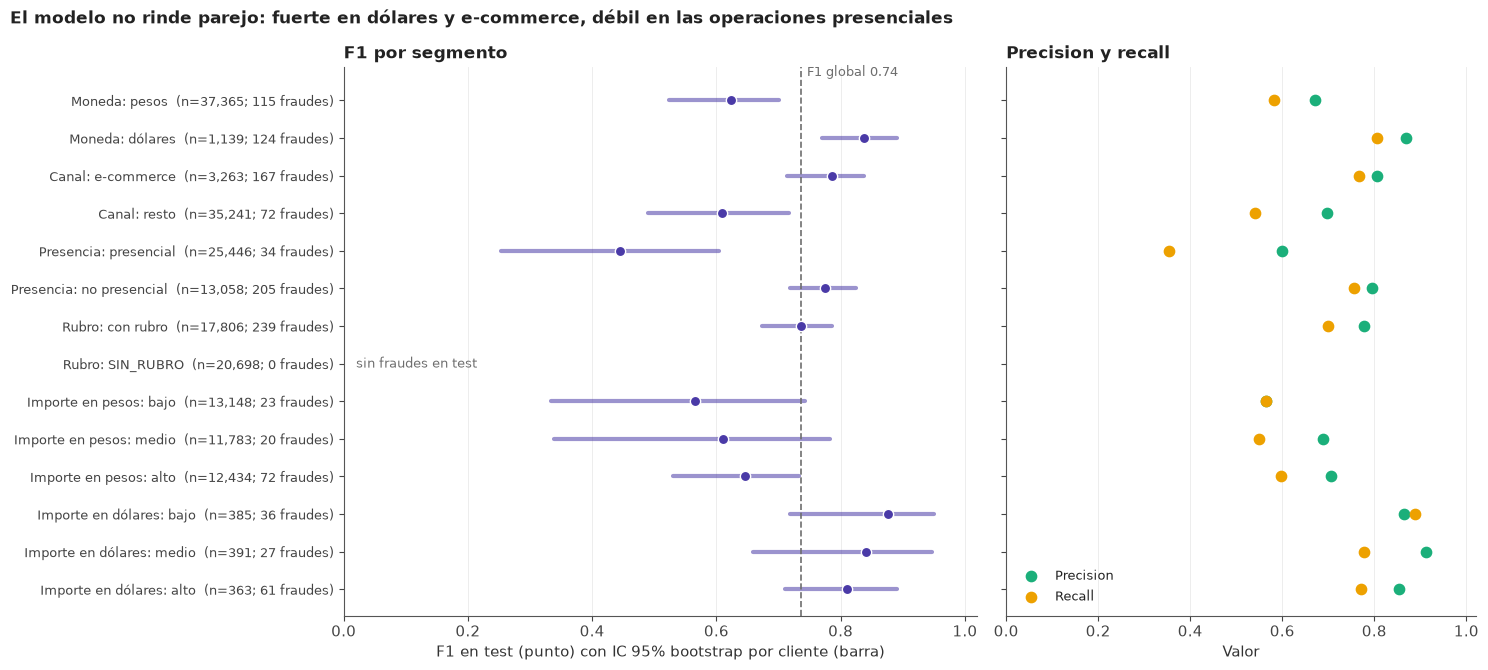

In [35]:
yt_all = y_test.values
imp_test = X_test['Trx_Importe'].values
mon_test = X_test['Trx_Moneda'].values
# tramos de importe por terciles DENTRO de cada moneda (los cortes se calculan con train; pesos y dólares no se mezclan)
segmentos = {
    'Moneda: pesos': mon_test == 0, 'Moneda: dólares': mon_test == 1,
    'Canal: e-commerce': (X_test[col_ecom] == 1).values, 'Canal: resto': (X_test[col_ecom] == 0).values,
    'Presencia: presencial': (X_test['Presencia_Cliente'] == 1).values, 'Presencia: no presencial': (X_test['Presencia_Cliente'] == 0).values,
    'Rubro: con rubro': (X_test[col_sin_rubro] == 0).values, 'Rubro: SIN_RUBRO': (X_test[col_sin_rubro] == 1).values}
for etiqueta, moneda in [('pesos', 0), ('dólares', 1)]:
    c1, c2 = X_train.loc[X_train['Trx_Moneda'] == moneda, 'Trx_Importe'].quantile([1 / 3, 2 / 3]).values
    base_m = mon_test == moneda
    segmentos[f'Importe en {etiqueta}: bajo'] = base_m & (imp_test <= c1)
    segmentos[f'Importe en {etiqueta}: medio'] = base_m & (imp_test > c1) & (imp_test <= c2)
    segmentos[f'Importe en {etiqueta}: alto'] = base_m & (imp_test > c2)

g_test = df.loc[X_test.index, 'Cliente_Id'].values


def metricas_segmento(mask, B=500, seed=SEED):
    yt, yp, gg = yt_all[mask], y_pred_final[mask], g_test[mask]; n = int(mask.sum())
    tp, fp, fn = int(((yt == 1) & (yp == 1)).sum()), int(((yt == 0) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum())
    out = {'transacciones': n, 'fraudes': int(yt.sum()), 'alertas': int(yp.sum()), 'aciertos (VP)': tp, 'falsas alarmas (FP)': fp}
    if yt.sum() == 0:
        out.update({'precision': np.nan, 'recall': np.nan, 'F1': np.nan, 'F1 IC lo': np.nan, 'F1 IC hi': np.nan})
        return out
    out.update({'precision': tp / (tp + fp) if tp + fp else 0.0, 'recall': tp / (tp + fn), 'F1': 2 * tp / (2 * tp + fp + fn)})
    rng = np.random.default_rng(seed); f1s = []
    _, inv = np.unique(gg, return_inverse=True); ng = inv.max() + 1
    for _ in range(B):
        w = np.bincount(rng.integers(0, ng, ng), minlength=ng)[inv]      # remuestreo de clientes
        tpb, fpb, fnb = (w * (yt == 1) * (yp == 1)).sum(), (w * (yt == 0) * (yp == 1)).sum(), (w * (yt == 1) * (yp == 0)).sum()
        f1s.append(2 * tpb / (2 * tpb + fpb + fnb) if (2 * tpb + fpb + fnb) > 0 else 0.0)
    out['F1 IC lo'], out['F1 IC hi'] = np.percentile(f1s, [2.5, 97.5])
    return out

seg_tabla = pd.DataFrame({k: metricas_segmento(m) for k, m in segmentos.items()}).T
seg_tabla['AUC-PR'] = [average_precision_score(yt_all[m], y_proba_final[m]) if yt_all[m].sum() > 0 else np.nan for m in segmentos.values()]
global_f1 = resultados[NOMBRE_FINAL]['f1']
display(seg_tabla.astype({'transacciones': int, 'fraudes': int, 'alertas': int, 'aciertos (VP)': int, 'falsas alarmas (FP)': int}).round(3))

# --- gráfico tipo "forest plot" ---
d = seg_tabla.iloc[::-1].copy()
etiquetas = [f"{k}  (n={int(r['transacciones']):,}; {int(r['fraudes'])} fraudes)" for k, r in d.iterrows()]
fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), sharey=True, gridspec_kw={'width_ratios': [1.35, 1]})
ax = axes[0]
for i, (k, r) in enumerate(d.iterrows()):
    if np.isnan(r['F1']):
        ax.text(0.02, i, 'sin fraudes en test', fontsize=9, color=GRIS, va='center'); continue
    ax.plot([r['F1 IC lo'], r['F1 IC hi']], [i, i], color=COLOR_METRICA['f1'], lw=3, alpha=0.55, solid_capstyle='round')
    ax.scatter(r['F1'], i, color=COLOR_METRICA['f1'], s=55, edgecolor='white', zorder=4)
ax.axvline(global_f1, color=GRIS, ls='--', lw=1.2); ax.text(global_f1 + 0.01, len(d) - 0.35, f'F1 global {global_f1:.2f}', color=GRIS, fontsize=9)
ax.set_yticks(range(len(d))); ax.set_yticklabels(etiquetas, fontsize=9); ax.set_xlim(0, 1.02); ax.set_ylim(-0.7, len(d) - 0.1)
ax.set_xlabel('F1 en test (punto) con IC 95% bootstrap por cliente (barra)'); ax.set_title('F1 por segmento'); ax.grid(axis='y', visible=False)
ax = axes[1]
ax.scatter(d['precision'], range(len(d)), color=COLOR_METRICA['precision'], s=55, label='Precision', zorder=4)
ax.scatter(d['recall'], range(len(d)), color=COLOR_METRICA['recall'], s=55, label='Recall', zorder=4)
ax.set_xlim(0, 1.02); ax.set_xlabel('Valor'); ax.set_title('Precision y recall'); ax.legend(loc='lower left'); ax.grid(axis='y', visible=False)
plt.suptitle('El modelo no rinde parejo: fuerte en dólares y e-commerce, débil en las operaciones presenciales', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** el F1 global de 0,7357 esconde un modelo que **no rinde parejo**. Es fuerte donde está el riesgo: en **dólares** el F1 es 0,837 (precision 0,870, recall 0,806; IC 95% por cliente [0,770, 0,891]) y en **e-commerce** 0,785 ([0,713, 0,838]); en las operaciones **no presenciales**, que concentran 205 de los 239 fraudes, 0,775 ([0,718, 0,824]). Es más débil en **pesos** (0,623, [0,524, 0,701]) y en el **resto de los canales** (0,609, [0,490, 0,718]), y sobre todo en las operaciones **presenciales**: F1 de 0,444 (precision 0,600, recall 0,353), con un intervalo de [0,253, 0,604] que tiene su límite superior por debajo del F1 global, incluso remuestreando clientes enteros. El intervalo es ancho porque ahí hay solo 34 fraudes, pero la señal es consistente con lo que ya veníamos viendo: el fraude presencial es raro y no se parece a ninguna regla simple.

En `SIN_RUBRO` (20.698 transacciones, 0 fraudes) el modelo no genera ninguna alerta, ni siquiera falsas: aprendió esa regla perfectamente. Por tramos de importe, en pesos el F1 va de 0,565 (importes bajos) a 0,647 (altos), pero con 23, 20 y 72 fraudes esos intervalos son demasiado anchos como para afirmar una diferencia. **Para el negocio**: el modelo es más confiable para priorizar alertas en e-commerce y dólares; para fraude presencial conviene reforzarlo con otras señales (por ejemplo geografía, que el TP2 descartó por su cardinalidad).

### 7.2 Presupuesto de alertas: ¿cuántos fraudes encontramos si solo podemos revisar el top-k%?

En la práctica el equipo de prevención no revisa "todo lo que supere el umbral": tiene una **capacidad de revisión** limitada. Si ordenamos las transacciones de test por score y revisamos solo las k% más riesgosas, ¿qué fracción de los fraudes capturamos?

,% de transacciones revisadas,alertas (transacciones),fraudes encontrados,% de los fraudes detectados,precision (aciertos por alerta),lift vs revisar al azar
0,0.2500,97,94,39.3310,0.9690,156.1220
1,0.5000,193,157,65.6900,0.8130,131.0540
2,1.0000,386,202,84.5190,0.5230,84.3090
3,2.0000,771,215,89.9580,0.2790,44.9250
4,5.0000,1926,226,94.5610,0.1170,18.9040
5,10.0000,3851,228,95.3970,0.0590,9.5380


Con el umbral final (0.266) se generan 215 alertas (0.56% de las transacciones) y se detecta el 69.9% de los fraudes.
La mejor regla (Regla: dólares y e-commerce) marca el 0.78% de las transacciones y detecta el 32.6% de los fraudes.


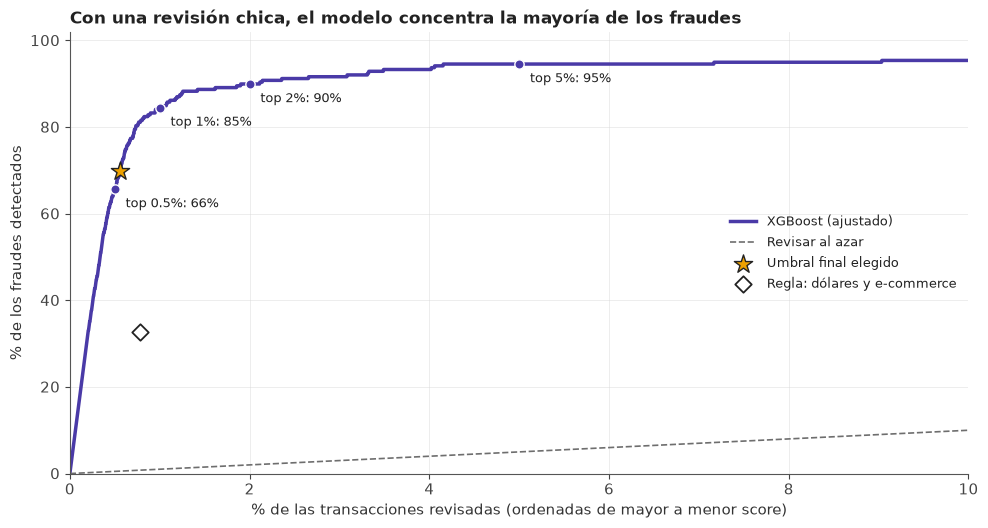

In [36]:
orden = np.argsort(-y_proba_final, kind='mergesort')
y_ord = yt_all[orden]
n_te = len(y_ord); n_fr = int(y_ord.sum())
cum_fraudes = np.cumsum(y_ord)
frac_rev = np.arange(1, n_te + 1) / n_te

presupuestos = [0.0025, 0.005, 0.01, 0.02, 0.05, 0.10]
filas = []
for k in presupuestos:
    m_ = int(np.ceil(k * n_te))
    filas.append({'% de transacciones revisadas': k * 100, 'alertas (transacciones)': m_, 'fraudes encontrados': int(cum_fraudes[m_ - 1]),
                  '% de los fraudes detectados': cum_fraudes[m_ - 1] / n_fr * 100, 'precision (aciertos por alerta)': cum_fraudes[m_ - 1] / m_,
                  'lift vs revisar al azar': (cum_fraudes[m_ - 1] / m_) / (n_fr / n_te)})
tabla_presupuesto = pd.DataFrame(filas)
display(tabla_presupuesto.round(3))
n_alertas_umbral = int(y_pred_final.sum())
print(f"Con el umbral final ({umbral_final:.3f}) se generan {n_alertas_umbral} alertas ({n_alertas_umbral / n_te * 100:.2f}% de las transacciones) y se detecta el {resultados[NOMBRE_FINAL]['recall'] * 100:.1f}% de los fraudes.")
reg = resultados[mejor_regla]
print(f"La mejor regla ({mejor_regla}) marca el {preds_test[mejor_regla].mean() * 100:.2f}% de las transacciones y detecta el {reg['recall'] * 100:.1f}% de los fraudes.")

fig, ax = plt.subplots(figsize=(10, 5.4))
tope = int(0.10 * n_te)
ax.plot(frac_rev[:tope] * 100, cum_fraudes[:tope] / n_fr * 100, color=color_modelo(NOMBRE_FINAL), lw=2.5, label=NOMBRE_FINAL)
ax.plot([0, 10], [0, 10], color=GRIS, ls='--', lw=1.2, label='Revisar al azar')
for k in [0.005, 0.01, 0.02, 0.05]:
    m_ = int(np.ceil(k * n_te)); yv = cum_fraudes[m_ - 1] / n_fr * 100
    ax.scatter(k * 100, yv, color=color_modelo(NOMBRE_FINAL), s=45, edgecolor='white', zorder=5)
    ax.text(k * 100 + 0.12, yv - 4.2, f"top {k*100:g}%: {yv:.0f}%", fontsize=9)
ax.scatter(n_alertas_umbral / n_te * 100, resultados[NOMBRE_FINAL]['recall'] * 100, marker='*', s=190, color=AMARILLO, edgecolor='#222222', zorder=6, label='Umbral final elegido')
ax.scatter(preds_test[mejor_regla].mean() * 100, reg['recall'] * 100, marker='D', s=70, color='white', edgecolor='#222222', linewidth=1.3, zorder=6, label=f'{mejor_regla}')
ax.set_xlim(0, 10); ax.set_ylim(0, 102)
ax.set_xlabel('% de las transacciones revisadas (ordenadas de mayor a menor score)'); ax.set_ylabel('% de los fraudes detectados')
ax.set_title('Con una revisión chica, el modelo concentra la mayoría de los fraudes')
ax.legend(loc='center right')
plt.tight_layout(); plt.show()

**Comentario:** esta es probablemente la vista más útil para el equipo de prevención. Si ordenamos las 38.504 transacciones de test por score y solo se pudiera revisar el 0,5% más riesgoso (193 alertas), **se encontrarían 157 fraudes, el 65,69% del total, con una precision de 0,813** (de cada 10 alertas, 8 son fraude). Con el 1% (386 alertas) se llega al **84,52%** de los fraudes con una precision de 0,523, y con el 2% al 89,96%. A partir de ahí los rendimientos son decrecientes: pasar de revisar el 1% al 10% (3.851 alertas, diez veces más trabajo) solo suma 11 puntos de detección (de 84,52% a 95,40%) y la precision cae a 0,059. El lift contra revisar al azar es enorme en el extremo alto del ranking (156 veces con el 0,25% de las transacciones).

Con el umbral final se generan 215 alertas (0,56% de las transacciones) y se detecta el 69,9% de los fraudes: con una carga de revisión menor que la de la mejor regla de negocio (que marca el 0,78% y detecta apenas el 32,6%), el modelo detecta más del doble. Eso es lo que vale el modelo en la práctica.

### 7.3 ¿Cuánto dinero se detecta y cuánto se escapa?

`Trx_Importe` mezcla **pesos y dólares** (`Trx_Moneda`), así que **nunca los sumamos**: reportamos cada moneda por separado. Los montos son los de la muestra de test (el 20% de la muestra del TP), no los del banco completo.

moneda,Pesos,Dólares
unidad,ARS,USD
fraudes (cantidad),115,124
detectados (cantidad),67,100
monto de fraude total,"12,608,599.7","2,340.8"
monto detectado,"7,470,765.7","1,520.2"
monto NO detectado,"5,137,834.0",820.6
% detectado por monto,59.3,64.9
% detectado por cantidad,58.3,80.6
monto legítimo marcado (falsas alarmas),"3,285,320.2",283.4
falsas alarmas (cantidad),33,15


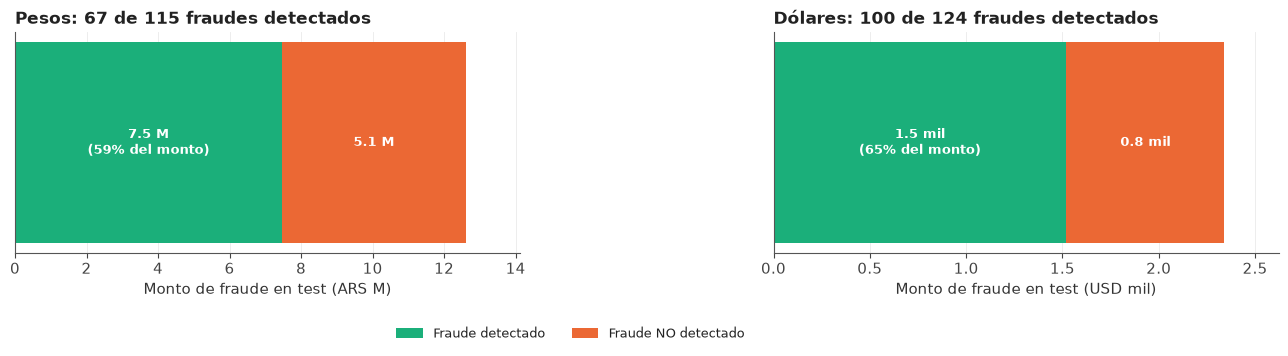

In [37]:
filas = []
for moneda, etiqueta, unidad in [(0, 'Pesos', 'ARS'), (1, 'Dólares', 'USD')]:
    en_m = mon_test == moneda
    fr = (yt_all == 1) & en_m
    det = fr & (y_pred_final == 1)
    perd = fr & (y_pred_final == 0)
    fp_m = (yt_all == 0) & en_m & (y_pred_final == 1)
    filas.append({'moneda': etiqueta, 'unidad': unidad, 'fraudes (cantidad)': int(fr.sum()), 'detectados (cantidad)': int(det.sum()),
                  'monto de fraude total': imp_test[fr].sum(), 'monto detectado': imp_test[det].sum(), 'monto NO detectado': imp_test[perd].sum(),
                  '% detectado por monto': imp_test[det].sum() / imp_test[fr].sum() * 100 if fr.sum() else np.nan,
                  '% detectado por cantidad': det.sum() / fr.sum() * 100 if fr.sum() else np.nan,
                  'monto legítimo marcado (falsas alarmas)': imp_test[fp_m].sum(), 'falsas alarmas (cantidad)': int(fp_m.sum()),
                  'importe medio de un fraude': imp_test[fr].mean(), 'importe medio de una trx legítima': imp_test[(yt_all == 0) & en_m].mean()})
montos = pd.DataFrame(filas).set_index('moneda')
pd.set_option('display.float_format', lambda v: f'{v:,.1f}')
display(montos.T)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
for ax, (etiqueta, r) in zip(axes, montos.iterrows()):
    escala, sufijo = (1e6, ' M') if r['unidad'] == 'ARS' else (1e3, ' mil')
    vals = [r['monto detectado'] / escala, r['monto NO detectado'] / escala]
    ax.barh([0], [vals[0]], color=AQUA, height=0.5, label='Fraude detectado')
    ax.barh([0], [vals[1]], left=[vals[0]], color=NARANJA, height=0.5, label='Fraude NO detectado')
    ax.text(vals[0] / 2, 0, f"{vals[0]:,.1f}{sufijo}\n({r['% detectado por monto']:.0f}% del monto)", ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
    ax.text(vals[0] + vals[1] / 2 if vals[1] / (vals[0] + vals[1]) > 0.18 else vals[0] + vals[1] + (vals[0] + vals[1]) * 0.02, 0,
            f"{vals[1]:,.1f}{sufijo}", ha='center' if vals[1] / (vals[0] + vals[1]) > 0.18 else 'left', va='center', fontsize=9.5,
            color='white' if vals[1] / (vals[0] + vals[1]) > 0.18 else '#222222', fontweight='bold')
    ax.set_yticks([]); ax.set_xlim(0, (vals[0] + vals[1]) * 1.12); ax.set_xlabel(f"Monto de fraude en test ({r['unidad']}{sufijo})")
    ax.set_title(f"{etiqueta}: {int(r['detectados (cantidad)'])} de {int(r['fraudes (cantidad)'])} fraudes detectados"); ax.grid(axis='y', visible=False)
axes[0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.28), ncol=2)
plt.tight_layout(); plt.show()

**Comentario:** en **pesos**, los fraudes del test suman 12.608.599,7 y el modelo detecta 67 de 115 casos (58,3% por cantidad), que representan 7.470.765,7, es decir, el **59,3% del monto**; se escapan 5.137.834,0. En **dólares** detecta 100 de 124 casos (80,6% por cantidad) pero solo el **64,9% del monto** (1.520,2 de 2.340,8 USD): lo que se escapa pesa más en monto que en cantidad (el 35,1% del monto contra el 19,4% de los casos). Un dato de contexto: el importe medio de un fraude en dólares es 18,9 contra 29,2 de una transacción legítima, o sea que, a diferencia de lo que uno imaginaría, los fraudes en dólares son *chicos*.

El otro lado de la moneda son las falsas alarmas: en pesos, las 33 transacciones legítimas marcadas suman 3.285.320,2, un monto menor que el fraude que se escapa pero del mismo orden; en dólares, 15 falsas alarmas por 283,4 USD. Dos advertencias: los montos son los de la muestra de test (el 20% de la muestra del TP, no los del banco), y **nunca se suman pesos con dólares**.

### 7.4 Umbral por costo: ¿y si dejar pasar un fraude "cuesta" mucho más que una falsa alarma?

El F1 trata como igual de graves los dos errores. En el negocio no lo son: un fraude no detectado significa pérdida y un cliente desprotegido; una falsa alarma significa una llamada o un bloqueo innecesario. No conocemos los costos reales del banco, así que lo planteamos con **supuestos explícitos y una tabla de sensibilidad**: expresamos el costo de un fraude no detectado como un múltiplo *r* del costo de una falsa alarma (que toma valor 1). Para cada *r* elegimos el umbral que **minimiza el costo total sobre las predicciones OOF de train** y evaluamos el resultado en test.

,umbral por costo (OOF),alertas,fraudes detectados,recall,falsas alarmas,costo total,costo con umbral F1,costo sin modelo (no alertar),ahorro vs sin modelo (%),ahorro del umbral por costo vs umbral F1 (%)
r (costo FN / costo FP),,,,,,,,,,
1,0.5770,170,147,0.6150,23,115,120,239,51.8830,4.1670
5,0.0480,332,197,0.8240,135,345,408,1195,71.1300,15.4410
10,0.0180,432,206,0.8620,226,556,768,2390,76.7360,27.6040
20,0.0170,448,206,0.8620,242,902,1488,4780,81.1300,39.3820
50,0.0050,702,213,0.8910,489,1789,3648,11950,85.0290,50.9590
100,0.0020,1008,218,0.9120,790,2890,7248,23900,87.9080,60.1270
200,0.0000,2495,226,0.9460,2269,4869,14448,47800,89.8140,66.3000


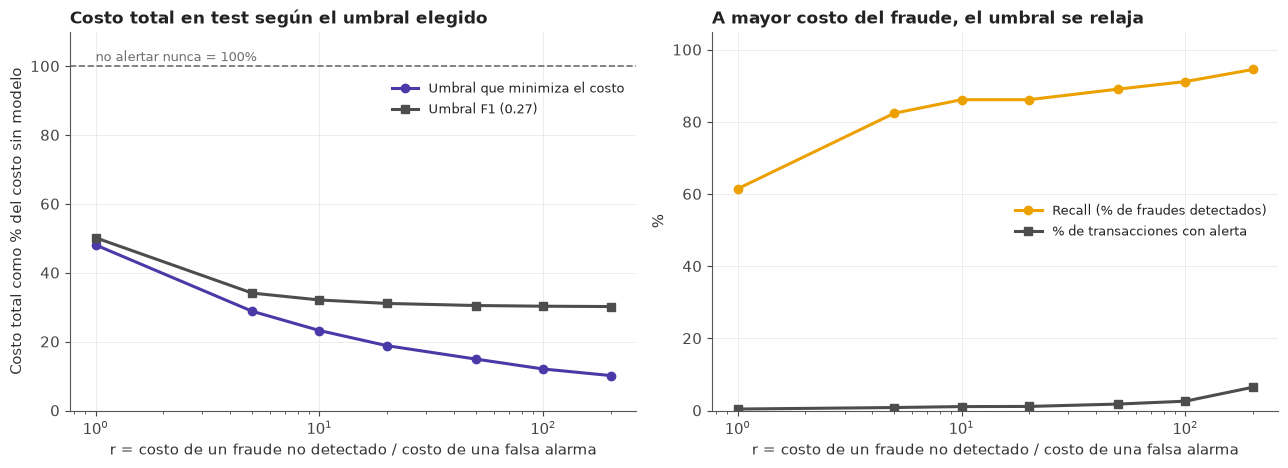

In [38]:
oof_f = candidatos[NOMBRE_FINAL]['oof']
fpr_o, tpr_o, thr_o = roc_curve(y_train, oof_f, drop_intermediate=False)
n0_tr, n1_tr = int((y_train == 0).sum()), int((y_train == 1).sum())

def costo(fp, fn, r):
    return fp + r * fn

filas = []
for r in [1, 5, 10, 20, 50, 100, 200]:
    c_oof = fpr_o * n0_tr + r * (1 - tpr_o) * n1_tr
    thr_c = float(thr_o[np.argmin(c_oof)])
    # si el mínimo cae en el primer umbral de roc_curve (inf), no se alerta nada
    p = y_proba_final >= thr_c
    fp, fn = int(((yt_all == 0) & p).sum()), int(((yt_all == 1) & ~p).sum())
    fp_f, fn_f = resultados[NOMBRE_FINAL]['fp'], resultados[NOMBRE_FINAL]['fn']
    sin_modelo = r * n_fr
    filas.append({'r (costo FN / costo FP)': r, 'umbral por costo (OOF)': thr_c, 'alertas': int(p.sum()), 'fraudes detectados': n_fr - fn, 'recall': (n_fr - fn) / n_fr,
                  'falsas alarmas': fp, 'costo total': costo(fp, fn, r), 'costo con umbral F1': costo(fp_f, fn_f, r), 'costo sin modelo (no alertar)': sin_modelo,
                  'ahorro vs sin modelo (%)': (1 - costo(fp, fn, r) / sin_modelo) * 100, 'ahorro del umbral por costo vs umbral F1 (%)': (1 - costo(fp, fn, r) / costo(fp_f, fn_f, r)) * 100})
sens = pd.DataFrame(filas).set_index('r (costo FN / costo FP)')
display(sens.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
rr = sens.index.values
ax.plot(rr, sens['costo total'] / sens['costo sin modelo (no alertar)'] * 100, color=color_modelo(NOMBRE_FINAL), marker='o', lw=2.2, label='Umbral que minimiza el costo')
ax.plot(rr, sens['costo con umbral F1'] / sens['costo sin modelo (no alertar)'] * 100, color='#4d4d4d', marker='s', lw=2.2, label=f'Umbral F1 ({umbral_final:.2f})')
ax.axhline(100, color=GRIS, ls='--', lw=1.2); ax.text(rr[0], 101.5, 'no alertar nunca = 100%', color=GRIS, fontsize=9)
ax.set_xscale('log'); ax.set_ylim(0, 110); ax.set_xlabel('r = costo de un fraude no detectado / costo de una falsa alarma'); ax.set_ylabel('Costo total como % del costo sin modelo')
ax.set_title('Costo total en test según el umbral elegido'); ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.9))
ax = axes[1]
ax.plot(rr, sens['recall'] * 100, color=COLOR_METRICA['recall'], marker='o', lw=2.2, label='Recall (% de fraudes detectados)')
ax.plot(rr, sens['alertas'] / n_te * 100, color='#4d4d4d', marker='s', lw=2.2, label='% de transacciones con alerta')
ax.set_xscale('log'); ax.set_xlabel('r = costo de un fraude no detectado / costo de una falsa alarma'); ax.set_ylabel('%'); ax.set_ylim(0, 105)
ax.set_title('A mayor costo del fraude, el umbral se relaja'); ax.legend(loc='center right')
plt.tight_layout(); plt.show()

**Comentario:** la tabla de sensibilidad muestra que **el umbral "correcto" depende de cuánto cuesta cada error, no del F1**. Si dejar pasar un fraude costara lo mismo que una falsa alarma (r = 1), el umbral óptimo sería 0,577 (170 alertas, recall 0,615); si costara 10 veces más, bajaría a 0,018 (432 alertas, recall 0,862), y con r = 100 a 0,002 (1.008 alertas, recall 0,912). Contra no tener modelo (no alertar nunca), el ahorro es de 51,88% con r = 1 y de 76,74% con r = 10.

¿Qué pasa con el umbral de F1 (0,2661)? Para r = 1 es casi tan bueno como el óptimo (costo 120 contra 115), pero **cuando el fraude es mucho más caro que la falsa alarma se queda corto**: con r = 5 el umbral de costo es 15,44% más barato, con r = 20 un 39,38%, con r = 100 un 60,13% y con r = 200 un 66,30%. Los costos de r son un supuesto nuestro (no conocemos los del banco), pero el mensaje es robusto: **si prevención valora más un fraude evitado que una llamada de más, conviene bajar el umbral por debajo del 0,2661**, y la decisión final es del negocio. Una salvedad: los scores no están calibrados (sección 6.6), así que en producción habría que recalibrar el umbral con costos reales.

# 8. ¿Qué tan confiable es esta evaluación? (robustez)

Todo lo que hicimos hasta acá usa la **partición aleatoria estratificada 80/20 que pide la consigna**, y es la que usamos para **comparar modelos entre sí** (es el procedimiento estándar y es comparable con el resto del proyecto). Esta sección no la reemplaza: **mide cuánto de ese número sobrevive en condiciones más parecidas a la realidad**. Hay dos motivos para sospechar que la partición aleatoria es optimista en este dataset:

1. **Un mismo cliente aparece a la vez en train y en test.** El fraude no es un evento aislado: cuando una tarjeta o una cuenta se compromete, el atacante hace varias operaciones seguidas (en promedio ~3,4 fraudes por cliente afectado). Al repartir las filas al azar, parte de ese *episodio* queda en entrenamiento y parte en test, con el mismo perfil de cliente, el mismo mes y valores casi idénticos de las variables de historial (`Cliente_CantTransacciones`, `Cliente_GastoPromedio`, etc.). El modelo puede estar "reconociendo al cliente" en lugar de aprender un patrón general de fraude.
2. **El fraude se concentra en el tiempo** (oct–dic reúnen el 93,6% de los casos). Con una partición aleatoria el modelo entrena con fraudes de diciembre y se evalúa con fraudes de diciembre; en producción el modelo siempre predice *el futuro*.

Para medirlo reconstruimos la **fecha** y el **cliente** de cada transacción (el CSV del TP2 no las incluye) a partir del archivo original.

### 8.1 Reconstrucción de `meta` (fecha, cliente y datos de legajo) alineada con el dataset

In [39]:
# Replicamos EXACTAMENTE el preprocesamiento del TP2 sobre el archivo crudo: sin duplicados exactos, imputación del legajo
# del cliente (ffill/bfill por cliente), timestamp = fecha + hora y orden por (Cliente_Id, timestamp).
ruta_del = ubicar_archivo('Muestra.del', subcarpeta='Muestra')
crudo = pd.read_csv(ruta_del, sep='|', encoding='latin-1')
m_ = crudo.drop_duplicates().reset_index(drop=True)
m_['Trx_Importe'] = m_['Trx_Importe'].str.replace(',', '.').astype(float)
m_['Trx_Fecha'] = pd.to_datetime(m_['Trx_Fecha'], format='%y%m%d')
m_['Es_Fraude'] = m_['Es_Fraude'].map({'NO': 0, 'SI': 1})
m_['Cliente_FechaNacimiento'] = pd.to_datetime(m_['Cliente_FechaNacimiento'], format='%d/%m/%Y')
for col_legajo in ['Cliente_Sexo', 'Cliente_FechaNacimiento', 'Cliente_CodigoPostal']:                      # datos de legajo: misma imputación por cliente del TP2
    m_[col_legajo] = m_.groupby('Cliente_Id')[col_legajo].transform(lambda s: s.ffill().bfill())
hora = m_['Trx_Hora'].astype(str).str.zfill(8).str[:6]
m_['Trx_Timestamp'] = pd.to_datetime(m_['Trx_Fecha'].dt.strftime('%Y-%m-%d') + ' ' + hora, format='%Y-%m-%d %H%M%S')
m_ = m_.sort_values(['Cliente_Id', 'Trx_Timestamp']).reset_index(drop=True)

# Chequeos de alineación fila a fila con el CSV del TP2 (si algo no coincidiera, el notebook se detiene acá)
assert len(m_) == len(df), "distinta cantidad de filas"
assert (m_['Cliente_Id'].values == df['Cliente_Id'].values).all(), "Cliente_Id no coincide"
assert np.allclose(m_['Trx_Importe'].values, df['Trx_Importe'].values), "Trx_Importe no coincide"
assert (m_['Es_Fraude'].values == df['Es_Fraude'].values).all(), "Es_Fraude no coincide"
# Además de cliente, importe y target, comprobamos que la FECHA Y HORA estén en la fila correcta: dos variables del CSV del TP2 se calcularon
# a partir del timestamp (Hora_sin = seno de la hora; Tiempo_Entre_Trx_Horas = diferencia con la transacción anterior del mismo cliente)
dt_h = m_.groupby('Cliente_Id')['Trx_Timestamp'].diff().dt.total_seconds() / 3600
ok_dt = dt_h.notna().values                    # la primera fila de cada cliente no tiene transacción anterior (el TP2 la imputó con la mediana)
assert np.allclose(dt_h.values[ok_dt], df['Tiempo_Entre_Trx_Horas'].values[ok_dt]), "timestamps desalineados"
assert np.allclose(np.sin(2 * np.pi * m_['Trx_Timestamp'].dt.hour / 24), df['Hora_sin']), "hora desalineada"

meta = m_[['Cliente_Id', 'Trx_Fecha', 'Trx_Timestamp', 'Cliente_Sexo', 'Cliente_FechaNacimiento', 'Cliente_CodigoPostal']].copy()
meta.index = df.index                          # mismo índice que el CSV (y por lo tanto que X_train / X_test)
meta['Trx_Mes'] = meta['Trx_Fecha'].dt.month
print("Alineación verificada: Cliente_Id, Trx_Importe, Es_Fraude, hora (Hora_sin) y tiempo entre transacciones coinciden en las", f"{len(meta):,}", "filas.")
print(f"Período: {meta['Trx_Fecha'].min().date()} a {meta['Trx_Fecha'].max().date()} | clientes: {meta['Cliente_Id'].nunique()}")
print("Sexo (tras la imputación del TP2):", meta['Cliente_Sexo'].value_counts().to_dict())
print(f"Datos de legajo sin nulos: fecha de nacimiento {int(meta['Cliente_FechaNacimiento'].isna().sum())} nulos, código postal {int(meta['Cliente_CodigoPostal'].isna().sum())} nulos "
      "(solo se usan agregados de estas columnas: nunca se imprimen filas con datos de legajo)")

Alineación verificada: Cliente_Id, Trx_Importe, Es_Fraude, hora (Hora_sin) y tiempo entre transacciones coinciden en las 192,516 filas.
Período: 2025-01-01 a 2025-12-31 | clientes: 716
Sexo (tras la imputación del TP2): {'FEMENINO': 120603, 'MASCULINO': 71913}
Datos de legajo sin nulos: fecha de nacimiento 0 nulos, código postal 0 nulos (solo se usan agregados de estas columnas: nunca se imprimen filas con datos de legajo)


### 8.2 El mecanismo: fraudes del mismo cliente repartidos entre train y test

Miramos, para cada fraude de **test**, si ese mismo cliente tiene otros fraudes en **train** y a cuántos días de distancia.

Fraudes en test: 239 | fraudes de test cuyo cliente tiene alguna transacción en train: 100.0%
  - del mismo cliente que ya tiene algún fraude en train: 83.3%
  - con otro fraude del mismo cliente en train a 7 días o menos: 82.0%
  - con otro fraude del mismo cliente en train el mismo día o al día siguiente: 76.2%
Clientes con fraude: 352 | fraudes por cliente afectado: 3.4 | duración mediana del episodio (primer a último fraude del cliente): 0 días | clientes con todos sus fraudes en un lapso de 30 días o menos: 97%


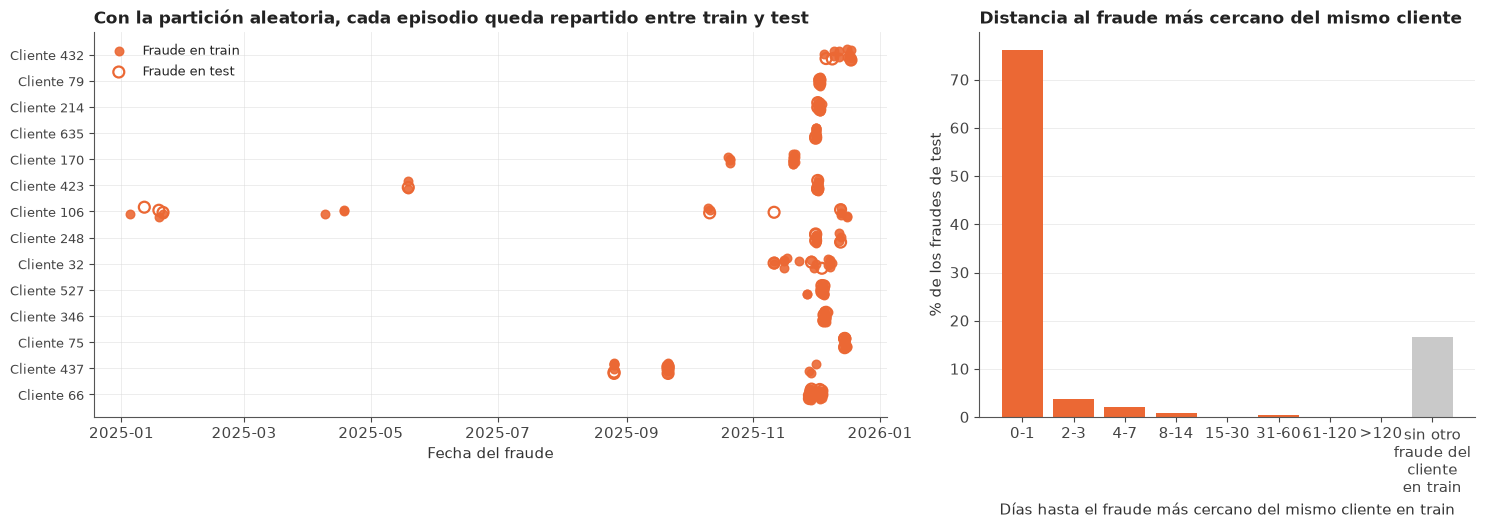

In [40]:
fr = meta.loc[y.index[y == 1], ['Cliente_Id', 'Trx_Fecha']].copy()
fr['partición'] = np.where(fr.index.isin(X_train.index), 'train', 'test')

dist_dias = []
for cid, g in fr.groupby('Cliente_Id'):
    d_tr = g.loc[g['partición'] == 'train', 'Trx_Fecha'].values.astype('datetime64[D]').astype(int)
    d_te = g.loc[g['partición'] == 'test', 'Trx_Fecha'].values.astype('datetime64[D]').astype(int)
    for d in d_te:
        dist_dias.append(np.abs(d_tr - d).min() if len(d_tr) else np.nan)
dist_dias = np.array(dist_dias, dtype=float)
n_fr_te = len(dist_dias)
span = fr.groupby('Cliente_Id')['Trx_Fecha'].agg(lambda s: (s.max() - s.min()).days)

print(f"Fraudes en test: {n_fr_te} | fraudes de test cuyo cliente tiene alguna transacción en train: "
      f"{meta.loc[X_test.index[y_test == 1], 'Cliente_Id'].isin(meta.loc[X_train.index, 'Cliente_Id']).mean() * 100:.1f}%")
print(f"  - del mismo cliente que ya tiene algún fraude en train: {np.mean(~np.isnan(dist_dias)) * 100:.1f}%")
print(f"  - con otro fraude del mismo cliente en train a 7 días o menos: {np.mean(dist_dias <= 7) * 100:.1f}%")
print(f"  - con otro fraude del mismo cliente en train el mismo día o al día siguiente: {np.mean(dist_dias <= 1) * 100:.1f}%")
print(f"Clientes con fraude: {fr['Cliente_Id'].nunique()} | fraudes por cliente afectado: {len(fr) / fr['Cliente_Id'].nunique():.1f} | duración mediana del episodio (primer a último fraude del cliente): {span.median():.0f} días | "
      f"clientes con todos sus fraudes en un lapso de 30 días o menos: {(span <= 30).mean() * 100:.0f}%")

# gráfico: línea de tiempo de los 14 clientes con más fraudes y distribución de distancias
top_clientes = fr['Cliente_Id'].value_counts().head(14).index.tolist()
sub = fr[fr['Cliente_Id'].isin(top_clientes)].copy()
sub['fila'] = sub['Cliente_Id'].map({c: i for i, c in enumerate(top_clientes)})
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
tr_ = sub[sub['partición'] == 'train']; te_ = sub[sub['partición'] == 'test']
rng_j = np.random.default_rng(SEED)                      # pequeño desplazamiento vertical para que no se tapen los puntos del mismo día
ax.scatter(tr_['Trx_Fecha'], tr_['fila'] + rng_j.uniform(-0.22, 0.22, len(tr_)), color=NARANJA, s=38, alpha=0.9, label='Fraude en train', zorder=3)
ax.scatter(te_['Trx_Fecha'], te_['fila'] + rng_j.uniform(-0.22, 0.22, len(te_)), facecolor='none', edgecolor=NARANJA, linewidth=1.6, s=62, label='Fraude en test', zorder=4)
ax.set_yticks(range(len(top_clientes))); ax.set_yticklabels([f"Cliente {c}" for c in top_clientes], fontsize=9)
ax.set_xlabel('Fecha del fraude'); ax.legend(loc='upper left')
ax.set_title('Con la partición aleatoria, cada episodio queda repartido entre train y test'); ax.title.set_fontsize(10.5)
ax = axes[1]
vals = dist_dias[~np.isnan(dist_dias)]
bins = [-0.5, 1.5, 3.5, 7.5, 14.5, 30.5, 60.5, 120.5, 400]      # tramos de días enteros: 0-1, 2-3, 4-7, ...
cuentas, _ = np.histogram(vals, bins=bins)
etiq = ['0-1', '2-3', '4-7', '8-14', '15-30', '31-60', '61-120', '>120', 'sin otro\nfraude del\ncliente\nen train']
porcentajes = list(cuentas / n_fr_te * 100) + [np.isnan(dist_dias).mean() * 100]
ax.bar(etiq, porcentajes, color=[NARANJA] * 8 + ['#c9c9c9'])
ax.set_xlabel('Días hasta el fraude más cercano del mismo cliente en train'); ax.set_ylabel('% de los fraudes de test')
ax.set_title('Distancia al fraude más cercano del mismo cliente'); ax.title.set_fontsize(10.5); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

**Comentario:** el diagnóstico confirma el mecanismo. El **100% de los fraudes de test pertenece a un cliente que también tiene transacciones en el entrenamiento** (ya lo habíamos visto en la sección 1.4: los 699 clientes del test están en train), y el **83,3% tiene además otro fraude del mismo cliente en train**: el 82,0% a 7 días o menos y el 76,2% a un día o menos (el histograma muestra que la gran mayoría está a 0-1 días; la barra gris es el 16,7% restante, sin otro fraude del cliente en train). Los episodios son **ráfagas muy cortas**: la duración mediana entre el primer y el último fraude de un cliente es de 0 días (todo ocurre en la misma jornada) y el 97% de los 352 clientes afectados (que sufrieron en promedio 3,4 fraudes cada uno) concentra todos sus fraudes en un lapso de 30 días o menos. En el gráfico de la izquierda se ve a los 14 clientes con más fraudes: en varios de ellos (por ejemplo, los clientes 432, 106, 32 y 437) los círculos huecos (test) aparecen pegados a los puntos llenos (train) de la misma semana.

Para el modelo, esto significa que **muchos fraudes de test tienen un "gemelo" en entrenamiento**: mismo cliente, mismo día, mismo perfil. Un modelo que reconozca al cliente y recuerde "este cliente está teniendo un episodio" acierta sin haber aprendido ningún patrón general de fraude. Es lo que explica el resultado raro de la sección 4.1 (el árbol sin restricciones, que solo recuerda, detectaba el 57% de los fraudes de test).

### 8.3 Tres evaluaciones del mismo modelo: aleatoria, por cliente y temporal

Reentrenamos la **configuración del modelo final** (mismos hiperparámetros) bajo tres esquemas de partición. En todos, el umbral se elige **sin mirar test**: reservando una parte del entrenamiento como validación (aleatoria y por cliente) o con un tramo posterior al entrenamiento (temporal).

- **Aleatoria**: `StratifiedKFold` de 5 folds (cada fold es un test de ~20%, igual que la partición del TP). Dentro de cada entrenamiento se aparta al azar un 25% para elegir el umbral y después se reentrena con todo el entrenamiento. La partición 80/20 única del TP aparece aparte, como referencia.
- **Por cliente**: `StratifiedGroupKFold` de 5 folds con `Cliente_Id` como grupo: **ningún cliente está a la vez en train y en test**. El 25% para elegir el umbral también se aparta por clientes enteros.
- **Temporal**: entrenamiento **enero–agosto**, tramo para elegir el umbral **septiembre–octubre**, test **noviembre–diciembre**. Es la situación real de un modelo que se despliega: predecir el futuro.
- **Temporal rodante** (extra): el modelo se **reentrena todos los meses** con todo lo anterior. Para predecir noviembre entrena con enero–septiembre y toma el umbral de octubre; para predecir diciembre entrena con enero–octubre y toma el umbral de noviembre. Es lo que haría un equipo que actualiza el modelo cada mes.

Como referencia agregamos la mejor regla de negocio (la de la sección 2) evaluada en cada test: es el piso que el modelo tiene que superar en cada escenario. Además, como el AUC-PR depende de la proporción de fraude en el test, mostramos también la **prevalencia** (el AUC-PR de un modelo al azar). La columna `F1 oráculo` es el mejor F1 que se lograría eligiendo el umbral *mirando* el test: **no es una métrica válida**, solo sirve para separar cuánto de un mal F1 se debe al umbral y cuánto a que el ranking de scores empeoró.

In [41]:
t0 = time.time()
MODELO_BASE = clone(modelo_final)          # misma configuración que el modelo final, sin entrenar
col_grupo = meta['Cliente_Id']
mes = meta['Trx_Mes']

def evaluar_particion(idx_tr, idx_te, idx_val=None, usar_grupos=False, cols=features_arboles, devolver_modelo=False):
    """Reentrena MODELO_BASE en idx_tr y evalúa en idx_te. El umbral se elige SIN mirar idx_te:
    - con idx_val (esquema temporal): predicciones sobre un tramo posterior al entrenamiento;
    - sin idx_val: se aparta el 25% de idx_tr (clientes enteros si usar_grupos) como validación y luego se reentrena con todo idx_tr."""
    if idx_val is None:
        if usar_grupos:
            a, b = next(StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED).split(idx_tr, y.loc[idx_tr], groups=col_grupo.loc[idx_tr]))
        else:
            a, b = next(StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED).split(idx_tr, y.loc[idx_tr]))
        i_fit, i_val = idx_tr[a], idx_tr[b]
    else:
        i_fit, i_val = idx_tr, idx_val
    m_val = clone(MODELO_BASE).fit(X.loc[i_fit, cols], y.loc[i_fit])
    thr, _ = umbral_optimo_f1(y.loc[i_val], m_val.predict_proba(X.loc[i_val, cols])[:, 1])
    mod = m_val if idx_val is not None else clone(MODELO_BASE).fit(X.loc[idx_tr, cols], y.loc[idx_tr])
    res = evaluar_en(mod, thr, idx_te, cols)
    return (res, mod, thr) if devolver_modelo else res


def evaluar_en(mod, thr, idx_te, cols=features_arboles):
    """Evalúa un modelo ya entrenado, con un umbral ya fijado, sobre las filas idx_te."""
    yte_ = y.loc[idx_te]
    s = mod.predict_proba(X.loc[idx_te, cols])[:, 1]
    p = (s >= thr).astype(int)
    regla = FUNC_REGLAS[mejor_regla](X.loc[idx_te]).astype(int)
    return {'umbral': thr, 'transacciones test': len(idx_te), 'fraudes test': int(yte_.sum()), 'prevalencia': float(yte_.mean()),
            'precision': precision_score(yte_, p, zero_division=0), 'recall': recall_score(yte_, p), 'F1': f1_score(yte_, p),
            'AUC-PR': average_precision_score(yte_, s), 'F1 regla': f1_score(yte_, regla),
            'F1 oráculo': umbral_optimo_f1(yte_, s)[1]}      # solo diagnóstico: elige el umbral mirando el test

def correr_folds(usar_grupos, cols=features_arboles):
    """5 folds externos (aleatorios o por cliente). Devuelve un DataFrame con una fila por fold."""
    if usar_grupos:
        splits = StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups=col_grupo)
    else:
        splits = StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y)
    filas = []
    for tr, te in splits:
        if usar_grupos:
            assert set(col_grupo.iloc[tr]).isdisjoint(set(col_grupo.iloc[te])), "hay clientes en train y test"
        filas.append(evaluar_particion(X.index[tr], X.index[te], usar_grupos=usar_grupos, cols=cols))
    return pd.DataFrame(filas)

def meses(lista):
    return X.index[mes.isin(list(lista))]

# --- (1) aleatoria y (2) por cliente, 5 folds ---
res_azar = correr_folds(False)
print(f"(1) aleatoria 5 folds: {time.time() - t0:.0f} s")
res_grupo = correr_folds(True)
print(f"(2) por cliente 5 folds: {time.time() - t0:.0f} s")

# --- (3) temporal ---
idx_tr_t, idx_val_t, idx_te_t = meses(range(1, 9)), meses([9, 10]), meses([11, 12])
res_temp, mod_temp, thr_temp = evaluar_particion(idx_tr_t, idx_te_t, idx_val=idx_val_t, devolver_modelo=True)
# el mismo modelo estático (ene-ago, umbral de sep-oct) evaluado mes por mes: es la comparación pareja para el esquema rodante
res_est_nov = evaluar_en(mod_temp, thr_temp, meses([11]))
res_est_dic = evaluar_en(mod_temp, thr_temp, meses([12]))
print(f"(3) temporal: {time.time() - t0:.0f} s")
print(f"    train ene-ago: {len(idx_tr_t):,} filas, {int(y.loc[idx_tr_t].sum())} fraudes | umbral sep-oct: {len(idx_val_t):,} filas, {int(y.loc[idx_val_t].sum())} fraudes | "
      f"test nov-dic: {len(idx_te_t):,} filas, {int(y.loc[idx_te_t].sum())} fraudes")

# --- (3b) temporal rodante: reentrenar todos los meses con todo lo anterior ---
res_rod_nov = evaluar_particion(meses(range(1, 10)), meses([11]), idx_val=meses([10]))
res_rod_dic = evaluar_particion(meses(range(1, 11)), meses([12]), idx_val=meses([11]))
print(f"(3b) rodante: {time.time() - t0:.0f} s | nov: entrena con {int(y.loc[meses(range(1, 10))].sum())} fraudes, umbral con {int(y.loc[meses([10])].sum())}, test {res_rod_nov['fraudes test']} | "
      f"dic: entrena con {int(y.loc[meses(range(1, 11))].sum())} fraudes, umbral con {int(y.loc[meses([11])].sum())}, test {res_rod_dic['fraudes test']}")

print("\nDetalle por fold (aleatoria):");  display(res_azar.round(3))
print("Detalle por fold (por cliente):"); display(res_grupo.round(3))

(1) aleatoria 5 folds: 80 s


(2) por cliente 5 folds: 159 s


(3) temporal: 164 s
    train ene-ago: 127,682 filas, 61 fraudes | umbral sep-oct: 33,589 filas, 59 fraudes | test nov-dic: 31,245 filas, 1076 fraudes


(3b) rodante: 178 s | nov: entrena con 77 fraudes, umbral con 43, test 225 | dic: entrena con 120 fraudes, umbral con 225, test 851

Detalle por fold (aleatoria):


,umbral,transacciones test,fraudes test,prevalencia,precision,recall,F1,AUC-PR,F1 regla,F1 oráculo
0,0.3340,38504,240,0.0060,0.7510,0.6540,0.6990,0.7610,0.2250,0.7090
1,0.2200,38503,239,0.0060,0.7750,0.6780,0.7230,0.7750,0.2050,0.7380
2,0.0980,38503,239,0.0060,0.7410,0.8160,0.7770,0.8380,0.2640,0.7870
3,0.4590,38503,239,0.0060,0.8780,0.6650,0.7570,0.7840,0.3060,0.7600
4,0.2740,38503,239,0.0060,0.8060,0.6780,0.7360,0.7910,0.2430,0.7420


Detalle por fold (por cliente):


,umbral,transacciones test,fraudes test,prevalencia,precision,recall,F1,AUC-PR,F1 regla,F1 oráculo
0,0.0220,38487,237,0.0060,0.2640,0.5190,0.3500,0.2540,0.1910,0.3670
1,0.0480,38491,240,0.0060,0.3130,0.4420,0.3660,0.3450,0.3260,0.3850
2,0.0890,38492,239,0.0060,0.3970,0.3470,0.3710,0.3340,0.2230,0.3840
3,0.0500,38508,238,0.0060,0.2890,0.3780,0.3280,0.1870,0.2670,0.3320
4,0.0700,38538,242,0.0060,0.3110,0.4500,0.3680,0.3360,0.2510,0.4350


,fraudes test,prevalencia,precision,recall,F1,AUC-PR,F1 regla,F1 oráculo,sd F1,sd AUC-PR,AUC-PR / prevalencia
Aleatoria 80/20 (la partición del TP),239.0000,0.0060,0.7770,0.6990,0.7360,0.8010,0.2890,0.7510,NaN,NaN,129.0650
"Aleatoria, 5 folds (media)",239.2000,0.0060,0.7900,0.6980,0.7390,0.7900,0.2490,0.7470,0.0300,0.0290,127.1110
"Por cliente, 5 folds (media)",239.2000,0.0060,0.3150,0.4270,0.3570,0.2910,0.2520,0.3810,0.0180,0.0690,46.8390
Temporal (ene-ago -> nov-dic),"1,076.0000",0.0340,0.3030,0.0610,0.1020,0.2380,0.3310,0.3430,NaN,NaN,6.8990
Estático ene-ago: test solo noviembre,225.0000,0.0130,0.1590,0.0440,0.0690,0.1130,0.2070,0.2190,NaN,NaN,8.7950
Temporal rodante: test noviembre,225.0000,0.0130,0.2090,0.1640,0.1840,0.1200,0.2070,0.2170,NaN,NaN,9.3930
Estático ene-ago: test solo diciembre,851.0000,0.0620,0.3610,0.0660,0.1110,0.3230,0.3710,0.4320,NaN,NaN,5.2030
Temporal rodante: test diciembre,851.0000,0.0620,0.4070,0.3200,0.3580,0.3690,0.3710,0.4510,NaN,NaN,5.9430


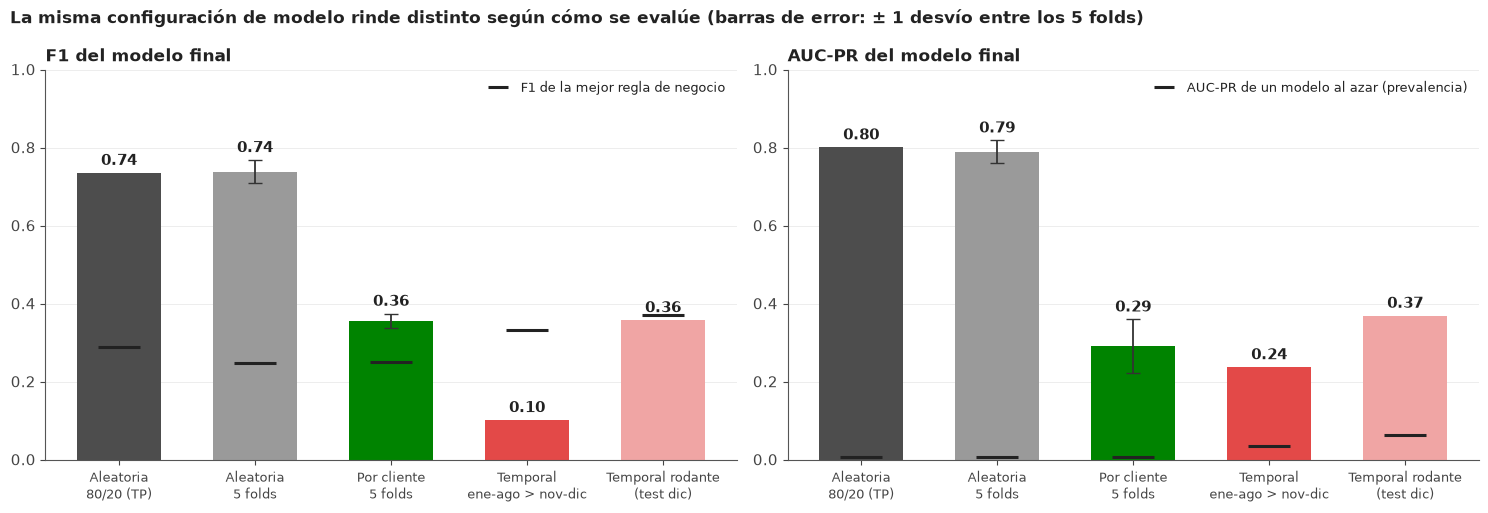

In [42]:
m_tp = resultados[NOMBRE_FINAL]
f1_orac_tp = umbral_optimo_f1(y_test, y_proba_final)[1]
cols_t = ['fraudes test', 'prevalencia', 'precision', 'recall', 'F1', 'AUC-PR', 'F1 regla', 'F1 oráculo']
filas = {
    'Aleatoria 80/20 (la partición del TP)': {'fraudes test': int(y_test.sum()), 'prevalencia': float(y_test.mean()), 'precision': m_tp['precision'], 'recall': m_tp['recall'],
                                              'F1': m_tp['f1'], 'AUC-PR': m_tp['auc_pr'], 'F1 regla': resultados[mejor_regla]['f1'], 'F1 oráculo': f1_orac_tp, 'sd F1': np.nan, 'sd AUC-PR': np.nan},
    'Aleatoria, 5 folds (media)': {**res_azar[cols_t].mean().to_dict(), 'sd F1': res_azar['F1'].std(), 'sd AUC-PR': res_azar['AUC-PR'].std()},
    'Por cliente, 5 folds (media)': {**res_grupo[cols_t].mean().to_dict(), 'sd F1': res_grupo['F1'].std(), 'sd AUC-PR': res_grupo['AUC-PR'].std()},
    'Temporal (ene-ago -> nov-dic)': {**{c: res_temp[c] for c in cols_t}, 'sd F1': np.nan, 'sd AUC-PR': np.nan},
    'Estático ene-ago: test solo noviembre': {**{c: res_est_nov[c] for c in cols_t}, 'sd F1': np.nan, 'sd AUC-PR': np.nan},
    'Temporal rodante: test noviembre': {**{c: res_rod_nov[c] for c in cols_t}, 'sd F1': np.nan, 'sd AUC-PR': np.nan},
    'Estático ene-ago: test solo diciembre': {**{c: res_est_dic[c] for c in cols_t}, 'sd F1': np.nan, 'sd AUC-PR': np.nan},
    'Temporal rodante: test diciembre': {**{c: res_rod_dic[c] for c in cols_t}, 'sd F1': np.nan, 'sd AUC-PR': np.nan}}
tabla_robustez = pd.DataFrame(filas).T
tabla_robustez['AUC-PR / prevalencia'] = tabla_robustez['AUC-PR'] / tabla_robustez['prevalencia']
display(tabla_robustez.round(3))

# --- gráfico comparativo ---
sel = ['Aleatoria 80/20 (la partición del TP)', 'Aleatoria, 5 folds (media)', 'Por cliente, 5 folds (media)', 'Temporal (ene-ago -> nov-dic)', 'Temporal rodante: test diciembre']
etiquetas = ['Aleatoria\n80/20 (TP)', 'Aleatoria\n5 folds', 'Por cliente\n5 folds', 'Temporal\nene-ago > nov-dic', 'Temporal rodante\n(test dic)']
colores = ['#4d4d4d', '#9a9a9a', VERDE, ROJO, '#f0a5a4']      # azul y naranja quedan reservados para la clase
tb = tabla_robustez.loc[sel]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, met, sd, ref, titulo, ref_lab in [(axes[0], 'F1', 'sd F1', 'F1 regla', 'F1 del modelo final', 'F1 de la mejor regla de negocio'),
                                          (axes[1], 'AUC-PR', 'sd AUC-PR', 'prevalencia', 'AUC-PR del modelo final', 'AUC-PR de un modelo al azar (prevalencia)')]:
    vals = tb[met].values.astype(float); errs = np.nan_to_num(tb[sd].values.astype(float))
    ax.bar(range(len(sel)), vals, color=colores, width=0.62)
    ax.errorbar([i for i, e in enumerate(errs) if e > 0], [vals[i] for i, e in enumerate(errs) if e > 0], yerr=[e for e in errs if e > 0],
                fmt='none', ecolor='#333333', capsize=5, lw=1.3)      # barras de error solo en los esquemas de 5 folds
    for i, v in enumerate(vals):
        ax.text(i, v + errs[i] + 0.02, f"{v:.2f}", ha='center', fontsize=10.5, fontweight='bold')
    ax.scatter(range(len(sel)), tb[ref].values.astype(float), marker='_', s=900, color='#222222', linewidths=2.2, zorder=5)
    ax.set_xticks(range(len(sel))); ax.set_xticklabels(etiquetas, fontsize=9.5); ax.set_ylim(0, 1.0); ax.set_title(titulo); ax.grid(axis='x', visible=False)
    ax.legend(handles=[Line2D([0], [0], marker='_', color='#222222', lw=0, markersize=14, markeredgewidth=2.2, label=ref_lab)], loc='upper right', fontsize=9)
plt.suptitle('La misma configuración de modelo rinde distinto según cómo se evalúe (barras de error: ± 1 desvío entre los 5 folds)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** el mismo modelo, con los mismos hiperparámetros, da resultados muy distintos según cómo se lo evalúe.

- **Aleatoria:** F1 de 0,7357 y AUC-PR de 0,8011 en la partición del TP, y 0,739 (desvío entre folds 0,030) y 0,790 (0,029) promediando 5 folds aleatorios: la partición del TP no es una "tirada afortunada", es representativa de este esquema.
- **Por cliente:** el F1 baja a **0,357** (desvío 0,018) y el AUC-PR a **0,291** (desvío 0,069; sus 5 folds van de 0,187 a 0,345). La precision cae de 0,790 a 0,315 y el recall de 0,698 a 0,427. El AUC-PR pasa de 127 a 47 veces la prevalencia. Contra la mejor regla de negocio (F1 de 0,252 en estos folds) el modelo gana por ~0,1 de F1: le gana en los 5 folds, pero la ventaja es mucho menor que el 0,739 contra 0,249 que sugería la partición aleatoria.
- **Temporal** (entrena ene-ago, umbral sep-oct, test nov-dic): F1 de **0,102** y AUC-PR de 0,238, con una prevalencia en test de 0,034 (6,9 veces). El F1 es peor que el de la regla (0,331). Con un umbral "oráculo" elegido mirando el test el F1 sube a 0,343, que **empata** con la regla (0,331): el umbral elegido en sep-oct (0,003) es extremo y por eso el recall es de 0,061, pero ni siquiera el mejor umbral posible separa al modelo de la regla, así que lo que se degrada es **el ranking**, no solo el umbral.
- **Temporal rodante** (reentrenar todos los meses), comparado con el mismo modelo estático (ene-ago) **sobre el mismo mes**: en noviembre el AUC-PR casi no cambia (0,113 con el estático contra 0,120 con el rodante) y en diciembre sube de 0,323 a 0,369, una mejora moderada de 0,046 de la que no medimos la incertidumbre. En F1, diciembre pasa de 0,111 a 0,358 contra 0,371 de la regla (un empate práctico): casi todo el salto viene de que el umbral se elige con un mes más cercano, no del ranking (con el mejor umbral posible serían 0,432 y 0,451). Noviembre queda en 0,184 contra 0,207 de la regla.

**Lectura honesta:** el número que pide la consigna (F1 ≈ 0,74) es el **techo optimista** de lo que este modelo puede hacer. Frente a clientes que no vio, el modelo supera a la regla "dólares y e-commerce" por ~0,1 de F1 (0,357 contra 0,252); frente al futuro queda a la par (diciembre con reentrenamiento mensual: 0,358 contra 0,371) o muy por debajo (0,102 contra 0,331 sin reentrenar). No decimos que el modelo sea inútil (su AUC-PR sigue estando entre 5,2 y 47 veces por encima del azar), sino que **su ventaja real sobre una regla simple es mucho menor que la que muestra la partición aleatoria**. La comparación entre modelos de las secciones 5 y 6 se hizo con la partición aleatoria, como pide la consigna: para saber si el orden entre modelos se mantiene en estos escenarios habría que repetirlas con validación por cliente.

### 8.4 El pico de diciembre: dos hipótesis que con un solo año no se pueden separar

La caída de la evaluación temporal no se puede interpretar sin mirar *cuándo* ocurre el fraude en esta muestra.

,transacciones,fraudes,clientes_activos,clientes con fraude,tasa de fraude (%),fraudes por cliente afectado
Trx_Mes,,,,,,
1,15854,14,628,5,0.0900,2.8000
2,14466,2,628,2,0.0100,1.0000
3,16034,0,634,0,0.0000,NaN
4,15418,14,634,3,0.0900,4.6700
5,15854,11,632,4,0.0700,2.7500
6,16232,12,642,4,0.0700,3.0000
7,16620,0,649,0,0.0000,NaN
8,17204,8,654,2,0.0500,4.0000
9,16426,16,657,2,0.1000,8.0000


Clientes con al menos un fraude: 352 de 716 (49%)
  - primer fraude en nov-dic: 315 (89%) | en oct: 20 | entre ene y sep: 17 (5%)
Fraudes entre ene y sep: 77 (6.4% del año) | oct-dic: 1119 (93.6% del año) | solo diciembre: 851 (71.2% del año)


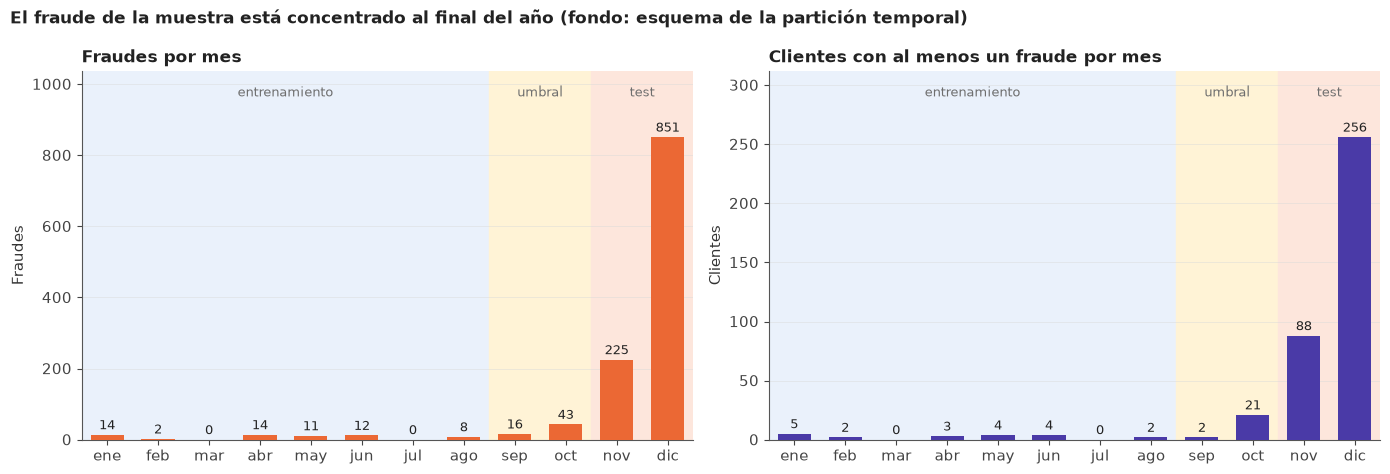

In [43]:
mensual = meta.assign(fraude=y).groupby('Trx_Mes').agg(transacciones=('fraude', 'size'), fraudes=('fraude', 'sum'), clientes_activos=('Cliente_Id', 'nunique'))
mensual['clientes con fraude'] = meta[y == 1].groupby('Trx_Mes')['Cliente_Id'].nunique().reindex(mensual.index).fillna(0).astype(int)
mensual['tasa de fraude (%)'] = mensual['fraudes'] / mensual['transacciones'] * 100
mensual['fraudes por cliente afectado'] = (mensual['fraudes'] / mensual['clientes con fraude'].replace(0, np.nan))
display(mensual.round(2))

primer = meta[y == 1].groupby('Cliente_Id')['Trx_Mes'].min()
print(f"Clientes con al menos un fraude: {len(primer)} de {meta['Cliente_Id'].nunique()} ({len(primer) / meta['Cliente_Id'].nunique() * 100:.0f}%)")
print(f"  - primer fraude en nov-dic: {(primer >= 11).sum()} ({(primer >= 11).mean() * 100:.0f}%) | en oct: {(primer == 10).sum()} | entre ene y sep: {(primer <= 9).sum()} ({(primer <= 9).mean() * 100:.0f}%)")
print(f"Fraudes entre ene y sep: {int(mensual.loc[1:9, 'fraudes'].sum())} ({mensual.loc[1:9, 'fraudes'].sum() / mensual['fraudes'].sum() * 100:.1f}% del año) | oct-dic: {int(mensual.loc[10:12, 'fraudes'].sum())} ({mensual.loc[10:12, 'fraudes'].sum() / mensual['fraudes'].sum() * 100:.1f}% del año) | solo diciembre: {int(mensual.loc[12, 'fraudes'])} ({mensual.loc[12, 'fraudes'] / mensual['fraudes'].sum() * 100:.1f}% del año)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, col, color, titulo, ylab in [(axes[0], 'fraudes', NARANJA, 'Fraudes por mes', 'Fraudes'), (axes[1], 'clientes con fraude', VIOLETA, 'Clientes con al menos un fraude por mes', 'Clientes')]:
    ymax = mensual[col].max() * 1.22
    ax.axvspan(0.5, 8.5, color='#eaf1fb', zorder=0); ax.axvspan(8.5, 10.5, color='#fff3d6', zorder=0); ax.axvspan(10.5, 12.5, color='#fde6dc', zorder=0)
    ax.bar(mensual.index, mensual[col], color=color, width=0.65, zorder=3)
    for mm, v in mensual[col].items():
        ax.text(mm, v + ymax * 0.015, f"{int(v)}", ha='center', fontsize=9, zorder=4)
    ax.text(4.5, ymax * 0.93, 'entrenamiento', ha='center', fontsize=9, color=GRIS); ax.text(9.5, ymax * 0.93, 'umbral', ha='center', fontsize=9, color=GRIS); ax.text(11.5, ymax * 0.93, 'test', ha='center', fontsize=9, color=GRIS)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(['ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic'])
    ax.set_ylim(0, ymax); ax.set_xlim(0.5, 12.5); ax.set_ylabel(ylab); ax.set_title(titulo); ax.grid(axis='x', visible=False)
plt.suptitle('El fraude de la muestra está concentrado al final del año (fondo: esquema de la partición temporal)', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** el fraude de la muestra está concentrado al final del año: **entre enero y septiembre hay 77 fraudes (6,4% del año), nunca más de 16 por mes**, mientras que octubre tiene 43, noviembre 225 y diciembre **851** (el 71,2% del año, con 256 clientes afectados y siendo el mes con menos transacciones, 13.689). Entre octubre y diciembre se concentran 1.119 casos, el 93,6% del año. El número de clientes activos es estable a lo largo del año (entre 628 y 684), así que no es un tema de volumen. De los 352 clientes que sufrieron fraude, 315 (89%) tuvieron su primer fraude en noviembre o diciembre y solo 17 (5%) entre enero y septiembre.

Hay **dos explicaciones posibles que con un único año no se pueden separar**: **(A)** un episodio real y estacional de fraude a fin de año (por ejemplo, una campaña de ataques); **(B)** un efecto de cómo se armó la muestra: si los clientes se seleccionaron por haber sido afectados en noviembre-diciembre y luego se trajo todo su año, los meses anteriores muestran la tasa "de fondo" y el pico de diciembre refleja el criterio de selección. Los dos escenarios predicen exactamente la misma figura. **No afirmamos que haya *concept drift* confirmado**; lo que sí podemos decir es que el modelo temporal se entrenó con solo 61 fraudes (enero-agosto) y se evaluó sobre 1.076, en un período en el que el fraude es mucho más frecuente (prevalencia de 3,4% contra 0,6% en la muestra), y que con estos datos no se puede validar la estabilidad en el tiempo. Cualquiera sea la causa, es la razón por la cual hace falta más historia (varios años) antes de desplegar.

### 8.5 Incertidumbre del F1 y del AUC-PR: remuestreando transacciones vs. remuestreando clientes

El bootstrap de la sección 6.3 remuestrea *transacciones* como si fueran independientes. Pero las transacciones de un mismo cliente no lo son (el episodio de fraude), así que ese intervalo probablemente sea demasiado angosto. Repetimos el bootstrap remuestreando **clientes enteros** (cluster bootstrap) sobre el test de la partición del TP.

Cluster bootstrap en 1 s | clientes en test: 699


,estimación,IC95% por transacción,ancho,IC95% por cliente,ancho,cuánto más ancho
métrica,,,,,,
F1,0.7360,"[0.690, 0.779]",0.0890,"[0.676, 0.786]",0.1100,1.2300
AUC-PR,0.8010,"[0.754, 0.845]",0.0900,"[0.741, 0.852]",0.1110,1.2290
recall,0.6990,"[0.640, 0.757]",0.1170,"[0.625, 0.765]",0.1400,1.2030
precision,0.7770,"[0.723, 0.833]",0.1100,"[0.708, 0.836]",0.1280,1.1580


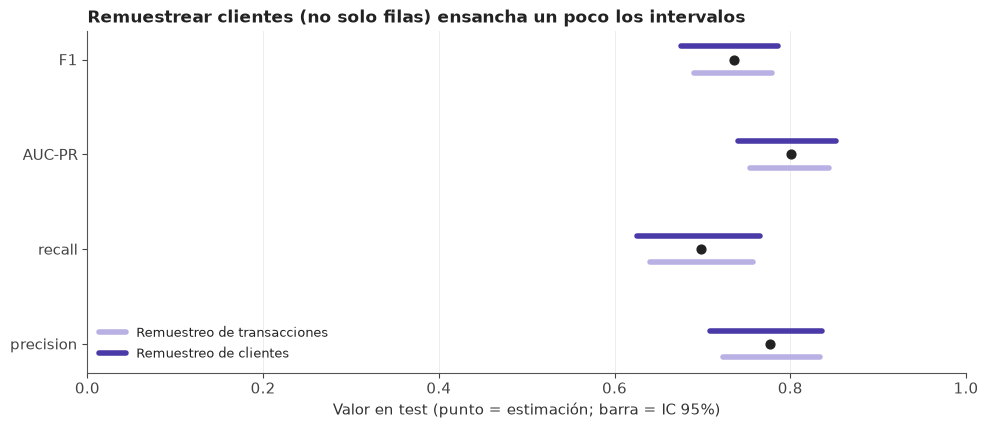

In [44]:
t0 = time.time()
g_te = meta.loc[X_test.index, 'Cliente_Id'].values
draws_cl = bootstrap(y_test, {NOMBRE_FINAL: (y_proba_final, y_pred_final)}, B=1000, grupos=g_te)[NOMBRE_FINAL]
draws_fila = draws[NOMBRE_FINAL]
assert not draws_cl.isna().any().any()
print(f"Cluster bootstrap en {time.time() - t0:.0f} s | clientes en test: {len(np.unique(g_te))}")

filas = []
for met, nom in [('f1', 'F1'), ('auc_pr', 'AUC-PR'), ('recall', 'recall'), ('precision', 'precision')]:
    lo_f, hi_f = draws_fila[met].quantile([0.025, 0.975]); lo_c, hi_c = draws_cl[met].quantile([0.025, 0.975])
    filas.append({'métrica': nom, 'estimación': resultados[NOMBRE_FINAL][met], 'IC95% por transacción': f"[{lo_f:.3f}, {hi_f:.3f}]", 'ancho': hi_f - lo_f,
                  'IC95% por cliente': f"[{lo_c:.3f}, {hi_c:.3f}]", 'ancho ': hi_c - lo_c, 'cuánto más ancho': (hi_c - lo_c) / (hi_f - lo_f)})
ic_cluster = pd.DataFrame(filas).set_index('métrica')
display(ic_cluster.round(3))

fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (met, nom) in enumerate([('f1', 'F1'), ('auc_pr', 'AUC-PR'), ('recall', 'recall'), ('precision', 'precision')][::-1]):
    for off, d, color, lab in [(-0.14, draws_fila, '#b9b0e3', 'Remuestreo de transacciones'), (0.14, draws_cl, VIOLETA, 'Remuestreo de clientes')]:
        lo, hi = d[met].quantile([0.025, 0.975])
        ax.plot([lo, hi], [i + off, i + off], color=color, lw=4, solid_capstyle='round', label=lab if i == 0 else None)
    ax.scatter(resultados[NOMBRE_FINAL][met], i, color='#222222', s=40, zorder=5)
ax.set_yticks(range(4)); ax.set_yticklabels(['precision', 'recall', 'AUC-PR', 'F1']); ax.set_xlim(0, 1)
ax.set_xlabel('Valor en test (punto = estimación; barra = IC 95%)'); ax.set_title('Remuestrear clientes (no solo filas) ensancha un poco los intervalos'); ax.legend(loc='lower left'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**Comentario:** al remuestrear clientes enteros (cluster bootstrap) los intervalos se ensanchan, pero **menos de lo que esperábamos**: el del F1 pasa de [0,690, 0,779] (ancho 0,089) a [0,676, 0,786] (ancho 0,110, 1,23 veces más ancho); el del AUC-PR de [0,754, 0,845] a [0,741, 0,852] (1,229 veces); el del recall 1,203 veces y el de la precision 1,158 veces. Es decir, tratar a las transacciones de un mismo cliente como un bloque agrega entre un 16% y un 23% de incertidumbre, no la duplica. La conclusión sobre el margen de error de la sección 6.3 se mantiene, con una pequeña corrección: lo razonable es leer el F1 de la partición del TP como **0,74 con un margen de ± 0,05**.

Ojo con lo que este ejercicio *no* mide: el cluster bootstrap cuantifica el ruido de muestreo, pero **no corrige el sesgo** de que los clientes del test también estén en el entrenamiento. Eso es lo que muestran las evaluaciones por cliente y temporal de arriba.

### 8.6 ¿Qué variables sostienen el resultado? Quitar las "huellas" del cliente y las del calendario

La importancia por permutación de la sección 6.5 mostró que el modelo se apoya mucho en variables que describen **al cliente más que a la transacción**: sus hábitos (día, hora y rubro favoritos, proporción de operaciones virtuales), su edad, su historial de gasto, y los componentes PCA (que mezclan varias de esas variables con el mes). Un perfil de cliente así funciona como una **huella digital**: si el mismo cliente aparece en train y en test, el modelo puede reconocerlo. Para comprobarlo, reentrenamos con **solo las variables de la transacción** (moneda, importe, presencia, hora, tiempo desde la anterior, canal y rubro) y repetimos las tres evaluaciones.

Además, probamos si el calendario "escondido" en las variables (el mes dentro del PCA y el contador `Cliente_CantTransacciones`, que crece a lo largo del año) explica algo de lo que pasa en la evaluación temporal.

Variantes evaluadas en 154 s


,F1 aleatoria,AUC-PR aleatoria,F1 por cliente,AUC-PR por cliente,F1 temporal,AUC-PR temporal
Todas las variables (32),0.7390,0.7900,0.3570,0.2910,0.1020,0.2380
Solo variables de la transacción (14),0.3400,0.3420,0.2360,0.2070,0.1470,0.2350
Sin PCA (30),NaN,NaN,NaN,NaN,0.1240,0.2390
Sin PCA ni contador de transacciones (29),NaN,NaN,NaN,NaN,0.0230,0.2410


F1 oráculo (solo diagnóstico, umbral elegido mirando test) en el esquema temporal: todas las variables 0.343 | solo transacción 0.358 | sin PCA 0.358 | sin PCA ni contador 0.354
Umbral elegido en sep-oct (esquema temporal): todas las variables 0.003 | solo transacción 0.007
Ganancia de usar las 32 variables en vez de las 14 de la transacción (F1 | AUC-PR): aleatoria +0.398 | +0.448 ; por cliente +0.121 | +0.084 ; temporal -0.045 | +0.002
F1 de la mejor regla de negocio: aleatoria 5 folds 0.249 | por cliente 0.252 | temporal 0.331
Desvío entre folds (F1 | AUC-PR), solo transacción: aleatoria 0.018 | 0.023 ; por cliente 0.042 | 0.045
Desvío entre folds (F1 | AUC-PR), todas las variables: aleatoria 0.030 | 0.029 ; por cliente 0.018 | 0.069


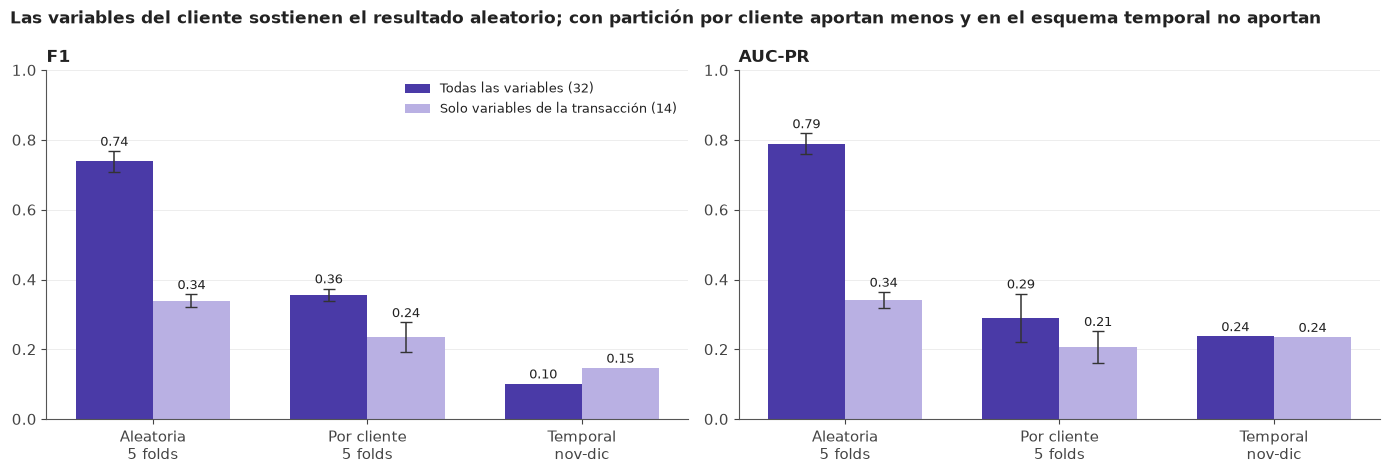

In [45]:
t0 = time.time()
cols_transaccion = ['Trx_Moneda', 'Trx_Importe', 'Trx_Importe_log', 'Es_Outlier_Importe', 'Presencia_Cliente', 'Hora_sin', 'Hora_cos', 'Tiempo_Entre_Trx_Horas'] + \
                   [c for c in features_arboles if c.startswith(('TipoTerminal_Agrupamiento', 'Categoria_Rubro_'))]
sin_pca = [c for c in features_arboles if not c.startswith('PCA_')]
sin_pca_ni_contador = [c for c in sin_pca if c != 'Cliente_CantTransacciones']

res_azar_t = correr_folds(False, cols_transaccion)
res_grupo_t = correr_folds(True, cols_transaccion)
res_temp_t = evaluar_particion(idx_tr_t, idx_te_t, idx_val=idx_val_t, cols=cols_transaccion)
res_temp_sp = evaluar_particion(idx_tr_t, idx_te_t, idx_val=idx_val_t, cols=sin_pca)
res_temp_spc = evaluar_particion(idx_tr_t, idx_te_t, idx_val=idx_val_t, cols=sin_pca_ni_contador)
print(f"Variantes evaluadas en {time.time() - t0:.0f} s")

def fila_variante(ra=None, rg=None, rt=None):
    f = {}
    for pref, r in [('aleatoria', ra), ('por cliente', rg)]:
        f[f'F1 {pref}'] = r['F1'].mean() if r is not None else np.nan
        f[f'AUC-PR {pref}'] = r['AUC-PR'].mean() if r is not None else np.nan
    f['F1 temporal'] = rt['F1'] if rt is not None else np.nan
    f['AUC-PR temporal'] = rt['AUC-PR'] if rt is not None else np.nan
    return f

variantes = {f'Todas las variables ({len(features_arboles)})': fila_variante(res_azar, res_grupo, res_temp),
             f'Solo variables de la transacción ({len(cols_transaccion)})': fila_variante(res_azar_t, res_grupo_t, res_temp_t),
             f'Sin PCA ({len(sin_pca)})': fila_variante(rt=res_temp_sp),
             f'Sin PCA ni contador de transacciones ({len(sin_pca_ni_contador)})': fila_variante(rt=res_temp_spc)}
tabla_variantes = pd.DataFrame(variantes).T
display(tabla_variantes.round(3))
print(f"F1 oráculo (solo diagnóstico, umbral elegido mirando test) en el esquema temporal: todas las variables {res_temp['F1 oráculo']:.3f} | solo transacción {res_temp_t['F1 oráculo']:.3f} | sin PCA {res_temp_sp['F1 oráculo']:.3f} | sin PCA ni contador {res_temp_spc['F1 oráculo']:.3f}")
print(f"Umbral elegido en sep-oct (esquema temporal): todas las variables {res_temp['umbral']:.3f} | solo transacción {res_temp_t['umbral']:.3f}")
gan = tabla_variantes.iloc[0] - tabla_variantes.iloc[1]          # todas las variables menos solo las de la transacción
print(f"Ganancia de usar las 32 variables en vez de las {len(cols_transaccion)} de la transacción (F1 | AUC-PR): aleatoria {gan['F1 aleatoria']:+.3f} | {gan['AUC-PR aleatoria']:+.3f} ; "
      f"por cliente {gan['F1 por cliente']:+.3f} | {gan['AUC-PR por cliente']:+.3f} ; temporal {gan['F1 temporal']:+.3f} | {gan['AUC-PR temporal']:+.3f}")
print(f"F1 de la mejor regla de negocio: aleatoria 5 folds {res_azar['F1 regla'].mean():.3f} | por cliente {res_grupo['F1 regla'].mean():.3f} | temporal {res_temp['F1 regla']:.3f}")
print(f"Desvío entre folds (F1 | AUC-PR), solo transacción: aleatoria {res_azar_t['F1'].std():.3f} | {res_azar_t['AUC-PR'].std():.3f} ; por cliente {res_grupo_t['F1'].std():.3f} | {res_grupo_t['AUC-PR'].std():.3f}")
print(f"Desvío entre folds (F1 | AUC-PR), todas las variables: aleatoria {res_azar['F1'].std():.3f} | {res_azar['AUC-PR'].std():.3f} ; por cliente {res_grupo['F1'].std():.3f} | {res_grupo['AUC-PR'].std():.3f}")

# --- gráfico: todas las variables vs solo variables de la transacción, en los tres esquemas ---
esquemas = ['aleatoria', 'por cliente', 'temporal']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sd_todas = {'F1': [res_azar['F1'].std(), res_grupo['F1'].std(), 0], 'AUC-PR': [res_azar['AUC-PR'].std(), res_grupo['AUC-PR'].std(), 0]}
sd_trans = {'F1': [res_azar_t['F1'].std(), res_grupo_t['F1'].std(), 0], 'AUC-PR': [res_azar_t['AUC-PR'].std(), res_grupo_t['AUC-PR'].std(), 0]}
for ax, met in zip(axes, ['F1', 'AUC-PR']):
    xx = np.arange(3); w = 0.36
    for k, (fila, color, lab, sds) in enumerate([(tabla_variantes.iloc[0], VIOLETA, 'Todas las variables (32)', sd_todas), (tabla_variantes.iloc[1], '#b9b0e3', f'Solo variables de la transacción ({len(cols_transaccion)})', sd_trans)]):
        vals = np.array([fila[f'{met} {e}'] for e in esquemas], dtype=float)
        ax.bar(xx + (k - 0.5) * w, vals, w, color=color, label=lab)
        ax.errorbar([xi for xi, e in zip(xx + (k - 0.5) * w, sds[met]) if e > 0], [v for v, e in zip(vals, sds[met]) if e > 0], yerr=[e for e in sds[met] if e > 0],
                    fmt='none', ecolor='#333333', capsize=4, lw=1.1)      # barras de error solo en los esquemas de 5 folds
        for xi, v, e in zip(xx + (k - 0.5) * w, vals, sds[met]):
            ax.text(xi, v + e + 0.015, f"{v:.2f}", ha='center', fontsize=9.5)
    ax.set_xticks(xx); ax.set_xticklabels(['Aleatoria\n5 folds', 'Por cliente\n5 folds', 'Temporal\nnov-dic']); ax.set_ylim(0, 1.0); ax.set_title(met); ax.grid(axis='x', visible=False)
axes[0].legend(loc='upper right', fontsize=9)
plt.suptitle('Las variables del cliente sostienen el resultado aleatorio; con partición por cliente aportan menos y en el esquema temporal no aportan', x=0.01, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Comentario:** esta tabla cierra el análisis.

1. **Con partición aleatoria, las variables del cliente más que duplican el resultado.** Pasar de las 14 variables de la transacción a las 32 sube el F1 de 0,340 a 0,739 y el AUC-PR de 0,342 a 0,790 (ganancias de unos 0,40 y 0,45).
2. **Cuando el cliente no se vio antes, esa ganancia se achica mucho, aunque no desaparece**: en la partición por cliente el F1 va de 0,236 a 0,357 y el AUC-PR de 0,207 a 0,291 (ganancias de 0,121 y 0,084: alrededor de un tercio de la ganancia del F1 y menos de una quinta parte de la del AUC-PR). Lo que queda es mayor que el desvío entre folds en el F1 (0,042 con las variables de la transacción y 0,018 con todas) y del orden del desvío en el AUC-PR (0,045 y 0,069). Las variables del cliente funcionan como una "firma" que permite reconocerlo, y la mayor parte de lo que aportan depende de que el cliente esté en el entrenamiento.
3. **En el esquema temporal tampoco aportan**: el AUC-PR es de 0,238 con todas las variables y de 0,235 solo con las de la transacción. El F1 es mayor con las de la transacción (0,147 contra 0,102) pero muy inferior al de la regla (0,331) en los dos casos: los umbrales elegidos en sep-oct son extremos (0,003 y 0,007) y con el umbral "oráculo" los F1 serían 0,343 y 0,358, es decir, la diferencia entre variantes viene del umbral, no del ranking.
4. **El "calendario escondido" no explica el colapso temporal.** Sacar los componentes PCA (que incluían el mes) deja el AUC-PR temporal en 0,239 y el F1 en 0,124; sacar además el contador de transacciones, en 0,241 y 0,023. El AUC-PR es prácticamente igual al original (0,238); el F1 se mueve entre 0,023 y 0,124 solo por el umbral (con el "oráculo" las cuatro variantes quedan entre 0,343 y 0,358). La falla temporal no viene de esas variables: el entrenamiento tiene solo 61 fraudes, de un período en el que el fraude casi no aparece, y con un solo año no podemos decir si eso refleja un cambio real o el modo en que se armó la muestra (sección 8.4).

Cuando esto se junta con la importancia por permutación (sección 6.5, donde la edad del cliente aparece como relevante), la lectura es clara para la partición por cliente: **buena parte del rendimiento aleatorio del modelo es memoria de clientes**. Por eso decimos que el número de la consigna es un techo. Esa explicación **no alcanza** para el esquema temporal (puntos 3 y 4).

# 9. Consideraciones éticas y de uso responsable

Hasta acá evaluamos el modelo como un problema técnico: qué tan bien separa el fraude de lo que no es fraude. Pero cada alerta es la operación de una persona que queda frenada, y cada fraude que se escapa es plata que alguien pierde. En esta sección auditamos **este** modelo con esa mirada, a partir de cinco preguntas:

1. **Equidad:** ¿se equivoca parecido con todos los grupos de clientes, o los errores se concentran en algunos?
2. **Costo humano de los errores:** ¿qué significa para el cliente un falso positivo y un falso negativo, y quién carga con cada uno?
3. **Validez:** ¿la población con la que entrenamos se parece a aquella en la que se usaría el modelo?
4. **Privacidad:** ¿usamos los datos personales que hacen falta, y no más?
5. **Explicabilidad:** ¿podemos explicarle una alerta al analista que la revisa y al cliente afectado?

Cerramos con un *model card* resumido (Mitchell et al., 2019), la ficha estándar para documentar para qué sirve un modelo y para qué no.

**Marco.** Usamos los cinco principios que Floridi y Cowls (2019) proponen para la IA: beneficencia, no maleficencia, autonomía, justicia y explicabilidad. Los traemos solo donde ayudan a decidir: la **no maleficencia** y la **justicia** ordenan la discusión sobre errores y equidad; la **autonomía** y la **explicabilidad**, la de bloqueos y explicaciones. En la Argentina, la *Guía para entidades públicas y privadas en materia de Transparencia y Protección de Datos Personales para una Inteligencia Artificial responsable* de la AAIP (2024) recomienda, entre otras cosas, hacer evaluaciones de impacto y cumplir con el principio de explicabilidad ([AAIP](https://www.argentina.gob.ar/noticias/guia-de-la-aaip-para-usar-la-inteligencia-artificial-de-manera-responsable)).

> **Alcance.** Los números de equidad, costo humano y explicabilidad salen del conjunto de test con partición aleatoria, que, como vimos en la sección 8, da una imagen **optimista** del modelo; las conclusiones de equidad heredan esa limitación. Los datos de validez (9.3) y de privacidad (9.4) salen de la muestra completa o del archivo crudo, y así se indica en cada caso. Las referencias normativas sirven para ubicar las preguntas; no son asesoramiento legal, y en un despliegue real las respondería el área de Legales/Compliance.

In [46]:
# --- Insumos: solo variables del contrato (X_test, y_test, y_pred_final, y_proba_final, umbral_final, meta, SEED) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython.display import display

assert PALETA[0] == '#2a78d6' and PALETA[1] == '#eb6834'   # PALETA se define en la sección 0 del notebook
COLOR_NO_FRAUDE, COLOR_FRAUDE = PALETA[0], PALETA[1]
COLOR_GRUPOS = PALETA[2]  # una sola serie por panel: los grupos se leen en el eje x
GRIS_TEXTO, GRIS_REF = '#333333', '#8a8a8a'
N_BOOT_ETICA = 1000
rng_etica = np.random.default_rng(SEED)

# Alineación: todo se cruza por el índice original del CSV
assert X_test.index.equals(y_test.index), 'X_test e y_test tienen que compartir el índice'
assert len(y_pred_final) == len(y_test) == len(y_proba_final), 'Predicciones y test con distinto largo'
assert X_test.index.isin(meta.index).all(), '`meta` tiene que cubrir todas las filas de test'

ev = pd.DataFrame({
    'cliente': meta.loc[X_test.index, 'Cliente_Id'].to_numpy(),
    'sexo': meta.loc[X_test.index, 'Cliente_Sexo'].astype(str).str.capitalize().to_numpy(),
    'edad': X_test['Cliente_Edad'].to_numpy(),
    'y': np.asarray(y_test).astype(int),
    'alerta': np.asarray(y_pred_final).astype(int),
    'score': np.asarray(y_proba_final, dtype=float),
}, index=X_test.index)
if not ((ev['score'] >= umbral_final).astype(int) == ev['alerta']).all():
    print('ATENCIÓN: y_pred_final no coincide con y_proba_final >= umbral_final; revisar el contrato.')
ev['tp'] = (ev['alerta'] == 1) & (ev['y'] == 1)
ev['fp'] = (ev['alerta'] == 1) & (ev['y'] == 0)
ev['fn'] = (ev['alerta'] == 0) & (ev['y'] == 1)

cli_test = ev.groupby('cliente').agg(edad=('edad', 'first'), fraudes=('y', 'sum'))
n_victimas_test = int((cli_test['fraudes'] > 0).sum())
print(f"Test: {len(ev):,} operaciones de {len(cli_test)} clientes; {int(ev['y'].sum())} fraudes de solo "
      f"{n_victimas_test} clientes distintos ({ev['y'].sum() / n_victimas_test:.1f} fraudes por cliente afectado).")
print(f"Umbral {umbral_final:.3f}: {int(ev['alerta'].sum())} alertas | recall {ev['tp'].sum() / ev['y'].sum():.1%} | "
      f"FPR {ev['fp'].sum() / (ev['y'] == 0).sum():.2%} | precisión {ev['tp'].sum() / max(ev['alerta'].sum(), 1):.1%}")
print(f"Edad de los clientes del test: media {cli_test['edad'].mean():.1f} años; "
      f"{(cli_test['edad'] >= 65).mean():.0%} tiene 65 años o más y {(cli_test['edad'] >= 80).mean():.0%} tiene 80 o más.")

Test: 38,504 operaciones de 699 clientes; 239 fraudes de solo 141 clientes distintos (1.7 fraudes por cliente afectado).
Umbral 0.266: 215 alertas | recall 69.9% | FPR 0.13% | precisión 77.7%
Edad de los clientes del test: media 51.6 años; 23% tiene 65 años o más y 4% tiene 80 o más.


**Comentario:** en test hay 239 fraudes, pero pertenecen a solo 141 clientes (1,7 fraudes por cliente afectado). Este dato condiciona todo lo que sigue: cuando comparemos grupos, la cantidad de información real se parece más a la cantidad de **clientes** con fraude que a la de fraudes. Con el umbral final (0,266) el modelo genera 215 alertas, con un recall de 69,9%, una tasa de falsos positivos de 0,13% y una precisión de 77,7%. La edad media de los clientes del test es de 51,6 años, el 23% tiene 65 años o más y el 4% tiene 80 o más, así que la pregunta por los adultos mayores no es marginal.

## 9.1 Equidad: ¿los errores se reparten parejo?

El modelo usa `Cliente_Edad` como variable de entrada, así que corresponde preguntarse si trata distinto a los clientes según su edad. También miramos `Cliente_Sexo`, que el TP2 descartó porque casi no se asociaba con el fraude (Cramér's V ≈ 0,006, valor calculado en el TP2, no en este notebook). Notemos que el motivo del descarte fue **predictivo**, no de equidad, y que **no usar una variable no garantiza tratar igual a los grupos que define**: otras variables pueden funcionar como *proxies* (gasto, canal, horarios) y los errores pueden caer distinto en cada grupo aunque el modelo nunca vea el sexo. Por eso la equidad se mide en los **resultados**, no en la lista de variables.

Para cada grupo calculamos, sobre test:

| Métrica | Pregunta que responde | Qué representa para el cliente |
|---|---|---|
| Tasa de alertas | ¿Qué proporción de sus operaciones marca el modelo? | Cuánta revisión recae sobre el grupo |
| Recall (TPR) | De sus fraudes, ¿cuántos detectamos? | **Protección** |
| Tasa de falsos positivos (FPR) | De sus operaciones legítimas, ¿cuántas marcamos por error? | **Fricción** injustificada |
| Precisión | De sus alertas, ¿cuántas eran fraude? | Cuánto "vale" una alerta en ese grupo |

**Intervalos por cliente.** Los fraudes no son independientes: un mismo cliente suele tener varios, muchas veces del mismo episodio. Un intervalo de Wilson calculado sobre transacciones los trataría como observaciones independientes y daría intervalos más angostos de lo que corresponde, como si tuviéramos más información de la que realmente tenemos. Por eso usamos un **bootstrap por cliente**: remuestreamos clientes (con todas sus operaciones) dentro de cada grupo, 1.000 veces.

**Tramos de edad.** Partimos de 18–30, 31–45, 46–60 y 61+. Si algún tramo queda con menos de 30 fraudes o menos de 15 clientes con fraude en test, cualquier diferencia sería casi puro ruido; en ese caso pasamos a 18–35, 36–50, 51–65 y 66+, que además deja a los mayores de 65 en un tramo propio.

In [47]:
# --- Herramientas de equidad: métricas por grupo con IC95% por bootstrap de clientes ---
METRICAS_EQUIDAD = {'tasa_alertas': 'Tasa de alertas', 'recall': 'Recall (fraudes detectados)',
                    'fpr': 'Falsos positivos (FPR)', 'precision': 'Precisión de las alertas'}
NOMBRE_CORTO = {'tasa_alertas': 'tasa de alertas', 'recall': 'recall', 'fpr': 'FPR', 'precision': 'precisión'}


def _metricas(S):
    """S: array (..., 5) con las sumas [operaciones, fraudes, alertas, TP, FP]."""
    n, pos, al, tp, fp = (S[..., i] for i in range(5))
    with np.errstate(divide='ignore', invalid='ignore'):
        return {'tasa_fraude': pos / n, 'tasa_alertas': al / n, 'recall': tp / pos,
                'fpr': fp / (n - pos), 'precision': tp / al}


def tabla_equidad(ev, col, orden, n_boot=N_BOOT_ETICA, rng=rng_etica):
    """Métricas por grupo + IC95% remuestreando CLIENTES (con todas sus operaciones) dentro de cada grupo."""
    por_cli = (ev.groupby([col, 'cliente'])
                 .agg(n=('y', 'size'), pos=('y', 'sum'), al=('alerta', 'sum'), tp=('tp', 'sum'), fp=('fp', 'sum')))
    filas, reps = [], {}
    for g in orden:
        A = por_cli.xs(g, level=col).to_numpy(dtype=float)
        idx = rng.integers(0, len(A), size=(n_boot, len(A)))
        reps[g] = _metricas(A[idx].sum(axis=1))
        punto = _metricas(A.sum(axis=0))
        fila = {'grupo': g, 'operaciones': int(A[:, 0].sum()), 'clientes': len(A), 'fraudes': int(A[:, 1].sum()),
                'clientes_con_fraude': int((A[:, 1] > 0).sum()), 'alertas': int(A[:, 2].sum()),
                'tasa_fraude': punto['tasa_fraude']}
        for m in METRICAS_EQUIDAD:
            fila[m] = punto[m]
            fila[m + '_lo'], fila[m + '_hi'] = np.nanpercentile(reps[g][m], [2.5, 97.5])
        filas.append(fila)
    return pd.DataFrame(filas).set_index('grupo'), reps


def brechas(tabla, reps):
    """Diferencia entre el grupo más alto y el más bajo de cada métrica, con IC95% bootstrap.
    Los grupos tienen clientes disjuntos, así que sus réplicas son independientes."""
    filas = []
    for m, nombre in METRICAS_EQUIDAD.items():
        g_max, g_min = tabla[m].idxmax(), tabla[m].idxmin()
        lo, hi = np.nanpercentile(reps[g_max][m] - reps[g_min][m], [2.5, 97.5])
        filas.append({'métrica': nombre, 'grupo más alto': g_max, 'grupo más bajo': g_min,
                      'diferencia (pp)': 100 * (tabla.loc[g_max, m] - tabla.loc[g_min, m]),
                      'IC95% inf (pp)': 100 * lo, 'IC95% sup (pp)': 100 * hi,
                      '¿distinguible del ruido?': 'sí' if lo > 0 else 'no'})
    return pd.DataFrame(filas).set_index('métrica')


def formatear(tabla):
    """Versión legible de la tabla de equidad: valor [IC95%] en porcentaje."""
    out = tabla[['operaciones', 'clientes', 'fraudes', 'clientes_con_fraude', 'alertas']].copy()
    out['tasa de fraude'] = (100 * tabla['tasa_fraude']).map('{:.2f}%'.format)
    for m, nombre in METRICAS_EQUIDAD.items():
        dec = 2 if m in ('fpr', 'tasa_alertas') else 1
        out[nombre + ' [IC95%]'] = [f'{100 * v:.{dec}f}% [{100 * l:.{dec}f}–{100 * h:.{dec}f}]'
                                    for v, l, h in zip(tabla[m], tabla[m + '_lo'], tabla[m + '_hi'])]
    return out


def graficar_equidad(tabla, tabla_brechas, sujeto):
    """Un panel por métrica: barras = valor en test, bigotes = IC95% por cliente, línea = valor global."""
    glob = _metricas(np.array([len(ev), ev['y'].sum(), ev['alerta'].sum(), ev['tp'].sum(), ev['fp'].sum()], float))
    fig, axes = plt.subplots(1, len(METRICAS_EQUIDAD), figsize=(17, 4.8))
    x = np.arange(len(tabla))
    etiquetas = [f'{g}\n{f} fraudes' for g, f in zip(tabla.index, tabla['fraudes'])]
    for ax, (m, nombre) in zip(axes, METRICAS_EQUIDAD.items()):
        val, lo, hi = (100 * tabla[c].to_numpy() for c in (m, m + '_lo', m + '_hi'))
        ax.bar(x, val, color=COLOR_GRUPOS, width=0.6)
        ax.errorbar(x, val, yerr=[val - lo, hi - val], fmt='none', ecolor=GRIS_TEXTO, capsize=4, lw=1.2)
        ax.axhline(100 * glob[m], color=GRIS_REF, ls='--', lw=1)
        ax.set_xlim(-0.5, len(tabla) - 0.5 + 0.6)  # margen derecho para la etiqueta de la línea global
        ax.annotate('global', xy=(len(tabla) - 0.45, 100 * glob[m]), xytext=(0, 3), textcoords='offset points',
                    ha='left', fontsize=9, color=GRIS_REF)
        ax.set_xticks(x)
        ax.set_xticklabels(etiquetas, fontsize=9)
        ax.set_title(nombre, fontsize=11, color=GRIS_TEXTO)
        ax.yaxis.set_major_formatter(PercentFormatter(decimals=2 if m in ('fpr', 'tasa_alertas') else 0))
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)
        for lado in ('top', 'right'):
            ax.spines[lado].set_visible(False)
    supera = [NOMBRE_CORTO[k] for k, nombre in METRICAS_EQUIDAD.items()
              if tabla_brechas.loc[nombre, '¿distinguible del ruido?'] == 'sí']
    conclusion = (f'la diferencia entre extremos supera el ruido en {", ".join(supera)}' if supera
                  else 'ninguna diferencia entre grupos supera el ruido del bootstrap')
    fig.suptitle(f'{sujeto}: {conclusion}\n(barras = valor en test; bigotes = IC95% por cliente; '
                 'línea punteada = valor global)', fontsize=12, color='black')
    fig.tight_layout()
    plt.show()

In [48]:
# --- Equidad por tramo de edad ---
TRAMOS_PROPUESTOS = ([17, 30, 45, 60, np.inf], ['18–30', '31–45', '46–60', '61+'])
TRAMOS_ALTERNATIVOS = ([17, 35, 50, 65, np.inf], ['18–35', '36–50', '51–65', '66+'])
MIN_FRAUDES_TRAMO, MIN_CLIENTES_FRAUDE_TRAMO = 30, 15


def asignar_tramos(cortes, etiquetas):
    tramo = pd.Series(pd.cut(ev['edad'], bins=cortes, labels=etiquetas).astype(str), index=ev.index)
    es_fraude = ev['y'] == 1
    conteo = pd.DataFrame({
        'operaciones': tramo.value_counts(),
        'clientes': ev.groupby(tramo)['cliente'].nunique(),
        'fraudes': ev.groupby(tramo)['y'].sum(),
        'clientes_con_fraude': ev[es_fraude].groupby(tramo[es_fraude])['cliente'].nunique(),
    }).reindex(etiquetas).fillna(0).astype(int)
    return tramo, conteo


tramo, conteo_tramos = asignar_tramos(*TRAMOS_PROPUESTOS)
print('Tramos propuestos (test):')
display(conteo_tramos)
pocos = conteo_tramos.index[(conteo_tramos['fraudes'] < MIN_FRAUDES_TRAMO) |
                            (conteo_tramos['clientes_con_fraude'] < MIN_CLIENTES_FRAUDE_TRAMO)].tolist()
if pocos:
    print(f'-> {", ".join(pocos)}: menos de {MIN_FRAUDES_TRAMO} fraudes o de {MIN_CLIENTES_FRAUDE_TRAMO} '
          'clientes con fraude. Usamos los tramos alternativos:')
    tramo, conteo_tramos = asignar_tramos(*TRAMOS_ALTERNATIVOS)
    ORDEN_TRAMOS = TRAMOS_ALTERNATIVOS[1]
    display(conteo_tramos)
else:
    ORDEN_TRAMOS = TRAMOS_PROPUESTOS[1]
    print('-> Todos los tramos tienen fraudes suficientes: mantenemos los propuestos.')
ev['tramo'] = tramo

tabla_edad, reps_edad = tabla_equidad(ev, 'tramo', ORDEN_TRAMOS)
brechas_edad = brechas(tabla_edad, reps_edad)
print('\nMétricas por tramo de edad (IC95% por bootstrap de clientes):')
display(formatear(tabla_edad))
print('Brecha entre el tramo con el valor más alto y el más bajo (puntos porcentuales):')
display(brechas_edad.round(2))

Tramos propuestos (test):


,operaciones,clientes,fraudes,clientes_con_fraude
edad,,,,
18–30,3262,71,16,8
31–45,10016,187,57,40
46–60,14646,223,79,44
61+,10580,218,87,49


-> 18–30: menos de 30 fraudes o de 15 clientes con fraude. Usamos los tramos alternativos:


,operaciones,clientes,fraudes,clientes_con_fraude
edad,,,,
18–35,6615,133,34,21
36–50,12398,212,74,42
51–65,12448,201,69,44
66+,7043,153,62,34



Métricas por tramo de edad (IC95% por bootstrap de clientes):


,operaciones,clientes,fraudes,clientes_con_fraude,alertas,tasa de fraude,Tasa de alertas [IC95%],Recall (fraudes detectados) [IC95%],Falsos positivos (FPR) [IC95%],Precisión de las alertas [IC95%]
grupo,,,,,,,,,,
18–35,6615,133,34,21,20,0.51%,0.30% [0.13–0.52],50.0% [30.4–66.7],0.05% [0.00–0.12],85.0% [66.7–100.0]
36–50,12398,212,74,42,77,0.60%,0.62% [0.41–0.86],75.7% [62.5–86.7],0.17% [0.09–0.26],72.7% [61.3–83.2]
51–65,12448,201,69,44,61,0.55%,0.49% [0.32–0.69],71.0% [56.1–83.0],0.10% [0.05–0.16],80.3% [68.3–90.1]
66+,7043,153,62,34,57,0.88%,0.81% [0.48–1.19],72.6% [55.8–85.0],0.17% [0.08–0.28],78.9% [64.0–89.8]


Brecha entre el tramo con el valor más alto y el más bajo (puntos porcentuales):


,grupo más alto,grupo más bajo,diferencia (pp),IC95% inf (pp),IC95% sup (pp),¿distinguible del ruido?
métrica,,,,,,
Tasa de alertas,66+,18–35,0.5100,0.1000,0.9100,sí
Recall (fraudes detectados),36–50,18–35,25.6800,4.1600,48.5900,sí
Falsos positivos (FPR),66+,18–35,0.1300,0.0200,0.2500,sí
Precisión de las alertas,18–35,36–50,12.2700,-8.9000,32.8400,no


**Comentario:** con los tramos propuestos, 18–30 queda con 16 fraudes de 8 clientes, así que pasamos a los tramos alternativos (18–35, 36–50, 51–65 y 66+). La columna *tasa de fraude* muestra que la tasa base varía entre tramos (de 0,51% en 18–35 a 0,88% en 66+). Esto importa para leer el resto: si la tasa base difiere, es esperable que la **tasa de alertas** y la **precisión** también difieran, sin que eso implique un trato injusto. Las métricas que comparan errores en igualdad de condiciones son el **recall** (calculado solo entre fraudes) y la **FPR** (calculada solo entre operaciones legítimas): son las que mejor responden "¿se equivoca más con unos que con otros?".

En la tabla de brechas, la diferencia entre el tramo más alto y el más bajo supera el ruido en la tasa de alertas (0,51 puntos porcentuales; IC95% [0,10, 0,91]), el recall (25,68 pp; [4,16, 48,59]) y la FPR (0,13 pp; [0,02, 0,25]), pero no en la precisión (12,27 pp; [-8,90, 32,84]). Dos advertencias: (1) elegimos los extremos después de mirar los datos, lo que infla un poco la brecha, así que la tomamos como señal de alarma y no como prueba (las de FPR y recall apenas superan el ruido: el extremo inferior de sus intervalos es 0,02 pp y 4,16 pp); (2) con entre 21 y 44 clientes con fraude por tramo (21, 42, 44 y 34), los intervalos de recall tienen entre 24 y 36 puntos de ancho, lo esperable: con estos datos podemos detectar brechas grandes, no sutiles.

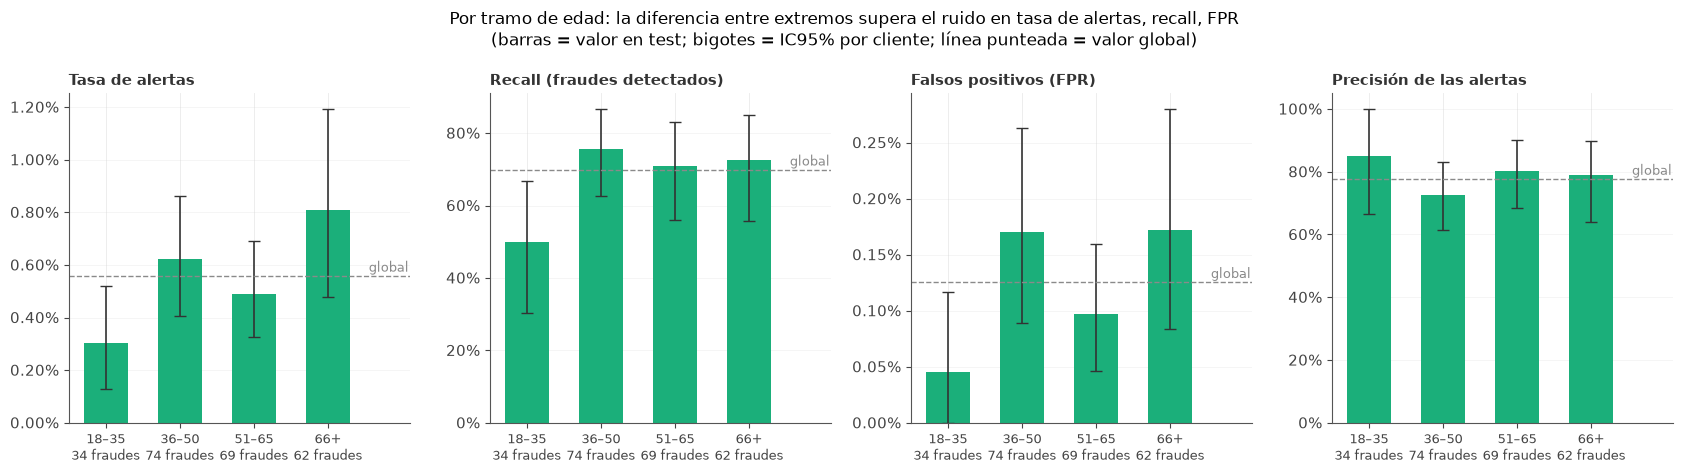

In [49]:
graficar_equidad(tabla_edad, brechas_edad, 'Por tramo de edad')

**Comentario:** el tramo **18–35** tiene el recall más bajo (50,0% [30,4–66,7], contra 75,7% [62,5–86,7] en 36–50), la FPR más baja (0,05% [0,00–0,12]) y la menor tasa de alertas (0,30%): el modelo molesta poco a los más jóvenes, pero también los protege menos, con un intervalo muy ancho (34 fraudes de 21 clientes) cuyo límite superior (66,7%) queda por debajo del recall global (69,9%). El tramo **66+** tiene la tasa de alertas más alta (0,81% contra 0,30% en 18–35), en parte porque su tasa de fraude también es la más alta (0,88% contra 0,51%), y una FPR de 0,17% [0,08–0,28], igual a la de 36–50 (0,17% [0,09–0,26]) y mayor que la de 18–35. Su recall (72,6% [55,8–85,0]) es parecido al global: los adultos mayores reciben protección y, a la vez, **más fricción que los más jóvenes**, que es justo el dilema que planteamos más abajo. Lo que **no** podemos concluir es que el modelo sea equitativo: en la precisión la diferencia no supera el ruido, pero con entre 21 y 44 clientes con fraude por tramo eso significa que no tenemos evidencia de una brecha, no que tengamos evidencia de igualdad.

,operaciones,clientes,fraudes,clientes_con_fraude,alertas,tasa de fraude,Tasa de alertas [IC95%],Recall (fraudes detectados) [IC95%],Falsos positivos (FPR) [IC95%],Precisión de las alertas [IC95%]
grupo,,,,,,,,,,
Femenino,23957,451,143,89,117,0.60%,0.49% [0.36–0.63],65.7% [55.2–74.6],0.10% [0.06–0.14],80.3% [72.7–87.1]
Masculino,14547,248,96,52,98,0.66%,0.67% [0.48–0.92],76.0% [65.3–85.3],0.17% [0.10–0.26],74.5% [63.5–84.2]


,grupo más alto,grupo más bajo,diferencia (pp),IC95% inf (pp),IC95% sup (pp),¿distinguible del ruido?
métrica,,,,,,
Tasa de alertas,Masculino,Femenino,0.1900,-0.0600,0.4800,no
Recall (fraudes detectados),Masculino,Femenino,10.3100,-3.8800,23.7300,no
Falsos positivos (FPR),Masculino,Femenino,0.0800,-0.0100,0.1700,no
Precisión de las alertas,Femenino,Masculino,5.8500,-6.6900,18.1100,no


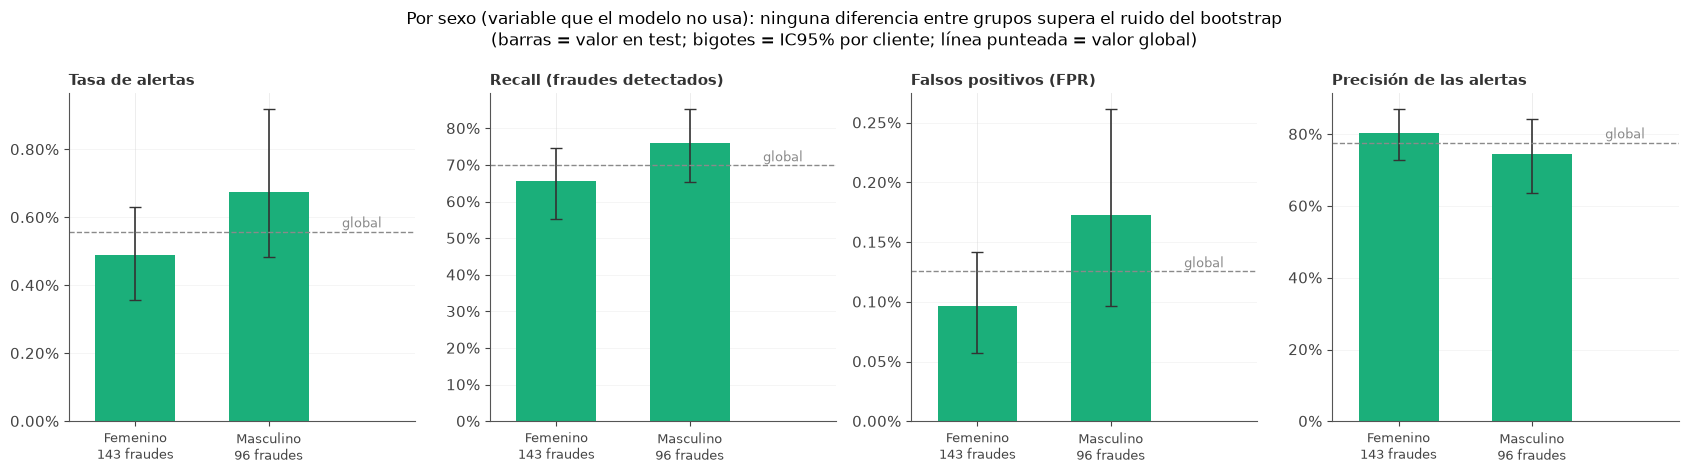

In [50]:
# --- Equidad por sexo: variable que el modelo NO usa ---
ORDEN_SEXO = sorted(ev['sexo'].unique())
tabla_sexo, reps_sexo = tabla_equidad(ev, 'sexo', ORDEN_SEXO)
brechas_sexo = brechas(tabla_sexo, reps_sexo)
display(formatear(tabla_sexo))
display(brechas_sexo.round(2))
graficar_equidad(tabla_sexo, brechas_sexo, 'Por sexo (variable que el modelo no usa)')

**Comentario:** entre **Femenino** y **Masculino**, el recall es 65,7% [55,2–74,6] contra 76,0% [65,3–85,3], y la FPR 0,10% [0,06–0,14] contra 0,17% [0,10–0,26]. Los puntos van en la misma dirección en todas las métricas de alerta (más alertas, más recall y más falsas alarmas para los varones), pero **ninguna brecha supera el ruido**: la diferencia de recall es de 10,31 puntos porcentuales con un IC95% de [-3,88, 23,73] y la de FPR de 0,08 pp, [-0,01, 0,17]. Con 89 mujeres y 52 varones con fraude no podemos separarlas del azar, lo que no es evidencia de igualdad. Si apareciera alguna brecha, no se explicaría por el sexo en sí (el modelo no lo ve) sino por variables correlacionadas con él. Lo miramos en la celda siguiente.

Variable más asociada al sexo: Cliente_ProporcionVirtual (|d| = 0.28, efecto chico). Las 5 con mayor |d| (d > 0: mayor en Femenino):
Cliente_ProporcionVirtual    0.2800
Cliente_GastoPromedio       -0.2700
Presencia_Cliente           -0.2600
Es_Outlier_Importe          -0.2000
Trx_Importe                 -0.2000
Variables del modelo con |d| >= 0,5: 0 de 32


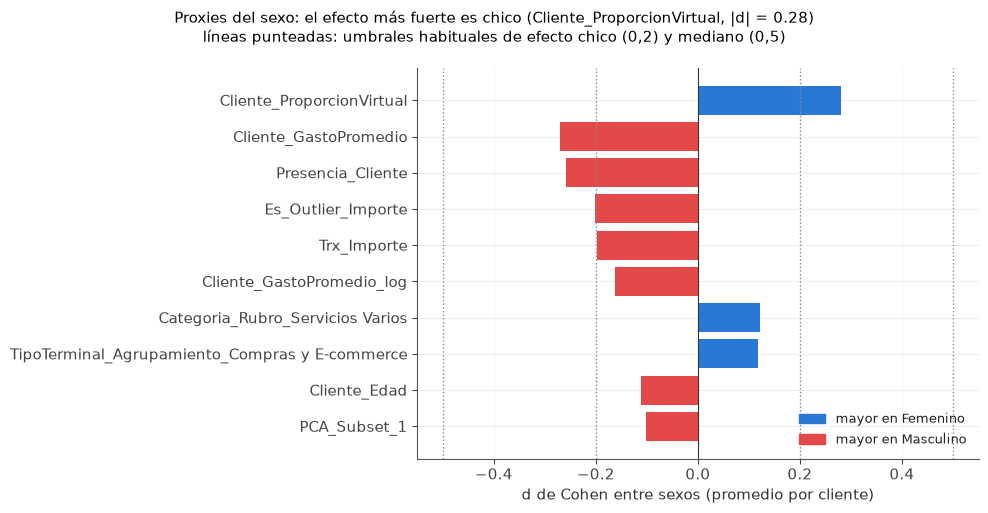

In [51]:
# --- ¿Qué variables del modelo llevan información sobre el sexo? d de Cohen a nivel cliente ---
def d_cohen(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan


perfil_cliente = X_test.select_dtypes(['number', 'bool']).astype(float).groupby(ev['cliente']).mean()
sexo_cliente = ev.groupby('cliente')['sexo'].first().reindex(perfil_cliente.index)
g1, g2 = ORDEN_SEXO[:2]
d_sexo = pd.Series({c: d_cohen(perfil_cliente.loc[sexo_cliente == g1, c], perfil_cliente.loc[sexo_cliente == g2, c])
                    for c in perfil_cliente.columns}).dropna()
top_proxies = d_sexo.reindex(d_sexo.abs().sort_values(ascending=False).index).head(10)
d_max = top_proxies.abs().max()
magnitud = 'despreciable' if d_max < 0.2 else 'chico' if d_max < 0.5 else 'mediano' if d_max < 0.8 else 'grande'
print(f'Variable más asociada al sexo: {top_proxies.abs().idxmax()} (|d| = {d_max:.2f}, efecto {magnitud}). Las 5 con mayor |d| (d > 0: mayor en {g1}):')
print(top_proxies.head(5).round(2).to_string())
print(f'Variables del modelo con |d| >= 0,5: {int((d_sexo.abs() >= 0.5).sum())} de {len(d_sexo)}')

fig, ax = plt.subplots(figsize=(10, 5.2))
orden_plot = top_proxies.iloc[::-1]
ax.barh(orden_plot.index, orden_plot.values, color=[PALETA[0] if v > 0 else PALETA[7] for v in orden_plot])
ax.axvline(0, color=GRIS_TEXTO, lw=0.8)
for ref in (-0.5, -0.2, 0.2, 0.5):
    ax.axvline(ref, color=GRIS_REF, ls=':', lw=1)
ax.set_xlabel('d de Cohen entre sexos (promedio por cliente)')
ax.legend(handles=[Patch(color=PALETA[0], label=f'mayor en {g1}'), Patch(color=PALETA[7], label=f'mayor en {g2}')],
          frameon=False, loc='lower right')
fig.suptitle(f'Proxies del sexo: el efecto más fuerte es {magnitud} ({top_proxies.abs().idxmax()}, |d| = {d_max:.2f})\n'
             'líneas punteadas: umbrales habituales de efecto chico (0,2) y mediano (0,5)', fontsize=11, color='black')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
fig.tight_layout()
plt.show()

**Comentario:** calculamos, para cada variable del modelo, cuánto difiere su promedio por cliente entre sexos, medido en desvíos estándar (d de Cohen). La variable más asociada es `Cliente_ProporcionVirtual` (más alta en las mujeres), con un efecto **chico** (|d| = 0,28); le siguen `Cliente_GastoPromedio` (-0,27), `Presencia_Cliente` (-0,26) y, con -0,20, `Es_Outlier_Importe` y `Trx_Importe`, todas más altas en los varones. Ninguna de las 32 variables llega a |d| = 0,5: **ninguna funciona por sí sola como un proxy fuerte del sexo**. Dos límites honestos: (1) variables individualmente débiles pueden, **combinadas**, permitir adivinar el sexo bastante mejor que el azar; medirlo requiere entrenar un clasificador auxiliar que prediga el sexo a partir de las variables del modelo, y queda como pendiente; (2) por eso mismo, la protección real no es sacar la variable sino **monitorear los resultados por grupo**, como hicimos arriba.

### ¿Con qué criterio de equidad juzgamos al modelo?

No hay una única definición de "equitativo", y cuando la tasa de fraude difiere entre grupos **no se pueden cumplir todas a la vez**: la igualdad de precisión entre grupos (paridad predictiva, emparentada con la calibración por grupo) y la igualdad de recall y FPR (*equalized odds*) son incompatibles, salvo con un clasificador perfecto (Kleinberg, Mullainathan y Raghavan, 2016; Chouldechova, 2017). Elegir es una decisión normativa, no técnica. Para este caso proponemos:

- **Descartar la paridad demográfica** (igual tasa de alertas en todos los grupos): si los estafadores apuntan más a ciertos clientes, forzar la misma tasa de alertas implicaría proteger menos justamente a quienes más lo necesitan.
- **Priorizar un recall parejo** (*igualdad de oportunidades*, Hardt, Price y Srebro, 2016): cada víctima, de cualquier edad o sexo, debería tener la misma chance de que detectemos su fraude.
- **Vigilar la FPR por grupo**: la fricción sobre clientes legítimos es el costo que el banco impone directamente, y no debería concentrarse en un grupo.
- **Aceptar que la precisión difiera** entre grupos con distinta tasa de fraude, y documentarlo.

**El dilema de la edad.** Usar `Cliente_Edad` puede **proteger** a los adultos mayores si son un blanco más frecuente del fraude (más recall para ellos), y al mismo tiempo **cargarlos con más fricción** (más falsas alarmas). Las dos cosas pueden ser ciertas a la vez, y en nuestros datos se ve un poco de cada una: el tramo 66+ tiene la tasa de fraude más alta (0,88%), un recall parecido al global (72,6% contra 69,9%) y una FPR mayor que la de 18–35 (0,17% contra 0,05%). Lo que inclina la balanza es qué pasa después de la alerta: si se resuelve con un contacto ágil, la fricción extra es un costo razonable a cambio de más protección; si implica bloquear la tarjeta, la carga cae sobre el grupo con menos alternativas digitales para destrabarla, y la balanza se invierte. No es una preocupación abstracta: la Ley 23.592 menciona expresamente el sexo entre los motivos de discriminación, y la Convención Interamericana sobre la Protección de los Derechos Humanos de las Personas Mayores (aprobada por la Ley 27.360) consagra en su art. 5 la igualdad y no discriminación por razones de edad. Un experimento que dejamos para la próxima iteración: **reentrenar sin `Cliente_Edad` y también sin `PCA_Subset_1/2`** (el PCA del TP2 se calculó con la edad entre sus variables, así que sacar solo la edad dejaría que el modelo la recupere por esa vía), y comparar el F1 global y el recall/FPR por tramo. Si el desempeño casi no cambia, no hay razón para usar la edad; si cambia, mantenerla debería quedar documentado con este análisis. Por la misma razón, la importancia por permutación de la edad que vimos en la sección 6.5 **subestima** cuánto usa el modelo la edad.

## 9.2 Costo humano de los errores

Las métricas cuentan todos los errores igual, pero no pesan lo mismo:

- **Falso positivo:** una operación legítima marcada como sospechosa. Según cómo se use la alerta, el cliente puede quedarse con la tarjeta bloqueada en la caja del supermercado, sin poder sacar efectivo o sin poder pagar un servicio, y encima sentirse tratado como sospechoso. Si se repite, deja de usar el canal o se va del banco. Para un jubilado que retira su haber en el cajero, un bloqueo el día de cobro puede significar quedarse sin plata para la semana.
- **Falso negativo:** un fraude que no detectamos. El cliente pierde plata y, muchas veces, también tiempo y tranquilidad: reclamos, denuncias, la incertidumbre de no saber si se la devuelven. Quién absorbe la pérdida (el cliente o el banco) depende de la política de la entidad y de la normativa de protección de usuarios del BCRA; es una consulta para Compliance, no algo que resuelva el modelo.

Para los adultos mayores, muy presentes en esta cartera, los dos errores suelen pesar más: tienen menos canales alternativos para destrabar un bloqueo y, si pierden plata, menos margen para recuperarla. Por eso medimos los errores también **por persona**: cuántos clientes recibieron al menos una falsa alarma y cuántas víctimas tuvieron al menos un fraude no detectado. Acá la unidad es el cliente, y los clientes son independientes entre sí, así que el intervalo de Wilson sí es adecuado.

,clientes,con_falsa_alarma,falsas_alarmas,victimas,victimas_con_fn,victimas_sin_aviso,% clientes con ≥1 falsa alarma,% víctimas con ≥1 fraude no detectado
tramo,,,,,,,,
18–35,133,2,3,21,15,11,1.5000,71.4000
36–50,212,17,21,42,17,12,8.0000,40.5000
51–65,201,11,12,44,16,14,5.5000,36.4000
66+,153,11,12,34,15,12,7.2000,44.1000
Total,699,41,48,141,63,49,5.9000,44.7000


Clientes con >=1 falsa alarma [IC95% de Wilson]: 18–35 1.5% [0.4-5.3] | 36–50 8.0% [5.1-12.5] | 51–65 5.5% [3.1-9.5] | 66+ 7.2% [4.1-12.4]
Víctimas con >=1 fraude no detectado [IC95% de Wilson]: 18–35 71.4% [50.0-86.2] | 36–50 40.5% [27.0-55.5] | 51–65 36.4% [23.8-51.1] | 66+ 44.1% [28.9-60.5]
48 falsas alarmas en test, repartidas en 41 clientes (5.9% de los clientes del test); el más afectado acumuló 3.
49 de 141 víctimas (34.8%) no recibieron ninguna alerta por ninguno de sus fraudes.
Aproximadamente 1 de cada 4.5 alertas es una operación legítima.


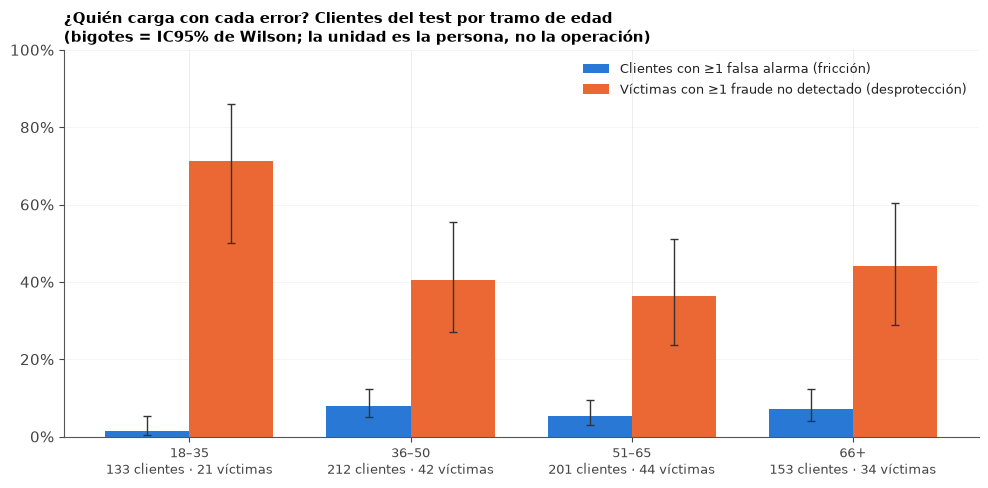

In [52]:
# --- Exposición a errores por persona, por tramo de edad ---
def wilson(k, n, z=1.96):
    k, n = np.asarray(k, float), np.asarray(n, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        p = k / n
        centro = (p + z ** 2 / (2 * n)) / (1 + z ** 2 / n)
        medio = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / (1 + z ** 2 / n)
    return centro - medio, centro + medio


por_cliente = ev.groupby('cliente').agg(tramo=('tramo', 'first'), fraudes=('y', 'sum'), tp=('tp', 'sum'),
                                        fp=('fp', 'sum'), fn=('fn', 'sum'))
por_cliente['con_falsa_alarma'] = por_cliente['fp'] > 0
por_cliente['victima'] = por_cliente['fraudes'] > 0
por_cliente['victima_con_fn'] = por_cliente['fn'] > 0
por_cliente['victima_sin_aviso'] = por_cliente['victima'] & (por_cliente['tp'] == 0)

exposicion = (por_cliente.groupby('tramo')
              .agg(clientes=('fraudes', 'size'), con_falsa_alarma=('con_falsa_alarma', 'sum'),
                   falsas_alarmas=('fp', 'sum'), victimas=('victima', 'sum'),
                   victimas_con_fn=('victima_con_fn', 'sum'), victimas_sin_aviso=('victima_sin_aviso', 'sum'))
              .reindex(ORDEN_TRAMOS).astype(int))
exposicion.loc['Total'] = exposicion.sum()
exposicion['% clientes con ≥1 falsa alarma'] = (100 * exposicion['con_falsa_alarma'] / exposicion['clientes']).round(1)
exposicion['% víctimas con ≥1 fraude no detectado'] = (100 * exposicion['victimas_con_fn'] / exposicion['victimas']).round(1)
display(exposicion)

for k, n, nombre in [('con_falsa_alarma', 'clientes', 'Clientes con >=1 falsa alarma'), ('victimas_con_fn', 'victimas', 'Víctimas con >=1 fraude no detectado')]:
    lo_w, hi_w = wilson(exposicion.loc[ORDEN_TRAMOS, k], exposicion.loc[ORDEN_TRAMOS, n])
    print(f'{nombre} [IC95% de Wilson]: ' + ' | '.join(
        f'{t} {100 * a / b:.1f}% [{100 * l:.1f}-{100 * h:.1f}]'
        for t, a, b, l, h in zip(ORDEN_TRAMOS, exposicion.loc[ORDEN_TRAMOS, k], exposicion.loc[ORDEN_TRAMOS, n], lo_w, hi_w)))

fp_por_cliente = por_cliente.loc[por_cliente['fp'] > 0, 'fp']
n_alertas, n_fp = int(ev['alerta'].sum()), int(ev['fp'].sum())
print(f'{n_fp} falsas alarmas en test, repartidas en {len(fp_por_cliente)} clientes '
      f'({len(fp_por_cliente) / len(por_cliente):.1%} de los clientes del test); '
      f'el más afectado acumuló {int(fp_por_cliente.max()) if len(fp_por_cliente) else 0}.')
print(f"{int(por_cliente['victima_sin_aviso'].sum())} de {int(por_cliente['victima'].sum())} víctimas ({por_cliente['victima_sin_aviso'].sum() / por_cliente['victima'].sum():.1%}) "
      'no recibieron ninguna alerta por ninguno de sus fraudes.')
if n_fp:
    print(f'Aproximadamente 1 de cada {n_alertas / n_fp:.1f} alertas es una operación legítima.')

sub = exposicion.loc[ORDEN_TRAMOS]
fig, ax = plt.subplots(figsize=(10, 5))
x, ancho = np.arange(len(ORDEN_TRAMOS)), 0.38
series = [('con_falsa_alarma', 'clientes', COLOR_NO_FRAUDE, 'Clientes con ≥1 falsa alarma (fricción)'),
          ('victimas_con_fn', 'victimas', COLOR_FRAUDE, 'Víctimas con ≥1 fraude no detectado (desprotección)')]
for i, (k, n, color, etiqueta) in enumerate(series):
    p = 100 * sub[k].to_numpy() / sub[n].to_numpy()
    lo, hi = wilson(sub[k], sub[n])
    pos = x + (i - 0.5) * ancho
    ax.bar(pos, p, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, p, yerr=[p - 100 * lo, 100 * hi - p], fmt='none', ecolor=GRIS_TEXTO, capsize=3, lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n{c} clientes · {v} víctimas' for t, c, v in zip(ORDEN_TRAMOS, sub['clientes'], sub['victimas'])],
                   fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylim(0, min(100, 1.35 * ax.get_ylim()[1]))
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper right')
ax.set_title('¿Quién carga con cada error? Clientes del test por tramo de edad\n'
             '(bigotes = IC95% de Wilson; la unidad es la persona, no la operación)', fontsize=11, color='black')
fig.tight_layout()
plt.show()

**Comentario:** en test, las 48 falsas alarmas recaen sobre 41 clientes (5,9% de los clientes del test), y 49 de 141 víctimas (34,8%) no recibieron ninguna alerta por ninguno de sus fraudes. Por tramo, la proporción de clientes con al menos una falsa alarma va de 1,5% en 18–35 [0,4–5,3] a 8,0% en 36–50 [5,1–12,5] (7,2% en 66+ [4,1–12,4]): el tramo más joven tiene la menor fricción, aunque su intervalo apenas se separa del de 36–50, y los otros tres tienen intervalos que se solapan. Del lado de la desprotección, la proporción de víctimas con al menos un fraude no detectado va de 36,4% en 51–65 [23,8–51,1] a 71,4% en 18–35 [50,0–86,2]: los más jóvenes quedan más desprotegidos, aunque con solo 21 víctimas el intervalo es muy ancho. Para dimensionarlo: (1) el test es ~20% de las operaciones; en producción el modelo puntuaría **todas**, así que la exposición anual por cliente sería bastante mayor que la que vemos acá; (2) la fricción no se reparte de forma uniforme: el cliente más afectado acumuló 3 falsas alarmas en el test.

**Propuesta de uso: el modelo prioriza, una persona decide.** Con una precisión de 77,7%, aproximadamente 1 de cada 4,5 alertas es una operación legítima. Bloquear automáticamente sería trasladarle ese error completo al cliente. Proponemos:

1. **Alerta → revisión humana**, no bloqueo automático. El analista confirma con el cliente por un canal verificado (llamada desde el número oficial, notificación en la app con confirmación) antes de tomar cualquier medida.
2. **Retención temporal solo en el extremo** (score muy alto *y* monto alto), con contacto inmediato y un plazo corto de resolución; nunca un bloqueo definitivo sin intervención humana.
3. **Un canal no digital para destrabar** (teléfono atendido por personas, sucursal), pensado para los clientes con menos autonomía digital. Es una aplicación concreta de la ética del cuidado: diseñar la respuesta mirando la vulnerabilidad de quien recibe la decisión.
4. **Registrar el resultado de cada revisión** (fraude confirmado / falsa alarma) para medir la precisión real en producción y la FPR por grupo.

Va en línea con la Comunicación "A" 8471 del BCRA (27/08/2026), que incorpora la gestión del riesgo de fraude a los lineamientos de gestión de riesgos de las entidades: pide un proceso "que permita minimizar la probabilidad y el impacto de eventos de fraude, proteger a los clientes y a la organización", canales para que los clientes reporten y protocolos de actuación documentados (puntos 1 a 4 vigentes desde el 01/12/2026; [texto](https://www.bcra.gob.ar/archivos/Pdfs/comytexord/A8471.pdf)).

## 9.3 Validez: ¿para qué población vale este modelo?

Un modelo puede ser preciso y equitativo en el test y aun así hacer daño si se usa sobre una población distinta. En nuestros datos hay tres señales de que la muestra **no se parece a una cartera típica**:

- **Casi la mitad de los clientes sufrió fraude** en el año (352 de 716, 49%; salida de la sección 8.4). En una cartera bancaria real esa proporción sería muchísimo menor.
- **El fraude está concentrado en el tiempo:** diciembre concentra el 71,2% de los fraudes del año, y octubre a diciembre el 93,6% (salida de la sección 8.4).
- **La cartera es mayoritariamente de una provincia:** el 85,3% de los clientes (611 de 716) tiene un código postal de Córdoba (5000–5999; salida de la celda siguiente). Los demás se reparten en otros códigos y, sin una tabla de localidades, no podemos asignarlos a una provincia.

El pico de diciembre admite dos hipótesis que con un solo año no podemos separar: **(A)** un episodio real o estacional de fraude, o **(B)** que la muestra se haya armado seleccionando clientes afectados a fin de año y trayendo todo su historial. Si fuera (B), la tasa de fraude de la muestra estaría inflada por diseño y el modelo habría aprendido, en parte, "cómo se ve el final del historial de un cliente estafado". La consecuencia ética es concreta: **el umbral se eligió contra una tasa de fraude que quizás no existe en producción**. Si la tasa real es menor, la precisión cae y cada fraude detectado viene acompañado de muchas más falsas alarmas: más fricción para clientes legítimos y más fatiga para los analistas, que terminan revisando alertas en piloto automático.

Lo cuantificamos: manteniendo el recall y la FPR del test, calculamos la precisión esperada si el fraude fuera menos frecuente, con precisión = π·TPR / (π·TPR + (1 − π)·FPR), donde π es la proporción de operaciones que son fraude.

In [53]:
# --- Composición geográfica de la cartera (solo agregados; no se imprimen filas) ---
cp_cliente = meta.drop_duplicates('Cliente_Id').set_index('Cliente_Id')['Cliente_CodigoPostal'].astype(int)
n_cli_total, n_cordoba = len(cp_cliente), int(cp_cliente.between(5000, 5999).sum())
print(f"Clientes con código postal de Córdoba (5000-5999): {n_cordoba} de {n_cli_total} ({n_cordoba / n_cli_total:.1%}).")
print('Clientes por primer dígito del código postal:', cp_cliente.floordiv(1000).value_counts().sort_index().to_dict())
print(f"Clientes con más de un código postal en el archivo: {int((meta.groupby('Cliente_Id')['Cliente_CodigoPostal'].nunique() > 1).sum())}.")

Clientes con código postal de Córdoba (5000-5999): 611 de 716 (85.3%).
Clientes por primer dígito del código postal: {1: 1, 2: 89, 4: 1, 5: 611, 6: 14}
Clientes con más de un código postal en el archivo: 0.


Diciembre: 6.9% de las operaciones del test, 69.0% de los fraudes y 70.2% de las alertas.


,proporción de fraude,precisión esperada,falsas alarmas por fraude detectado,alertas cada 100.000 operaciones
como en la muestra,0.621%,77.7%,0.3000,558
2 veces menos fraude,0.310%,63.4%,0.6000,342
5 veces menos fraude,0.124%,40.9%,1.4000,212
10 veces menos fraude,0.062%,25.7%,2.9000,169
20 veces menos fraude,0.031%,14.7%,5.8000,147
50 veces menos fraude,0.012%,6.5%,14.5000,134


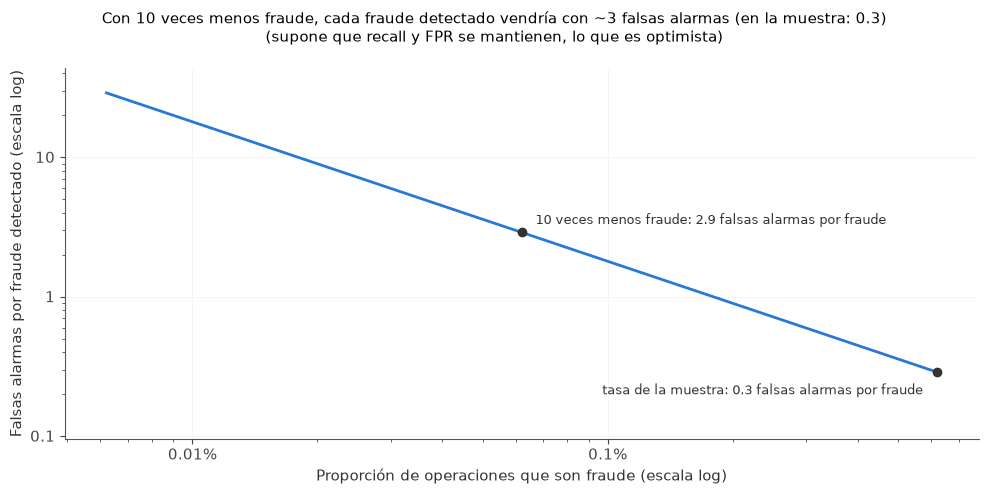

In [54]:
# --- Validez: concentración temporal en test y sensibilidad a la tasa de fraude ---
fechas = meta.loc[X_test.index, 'Trx_Fecha']
if not pd.api.types.is_datetime64_any_dtype(fechas):
    fechas = pd.to_datetime(fechas.astype(str), format='%y%m%d')
es_dic = (fechas.dt.month == 12).to_numpy()
print(f"Diciembre: {es_dic.mean():.1%} de las operaciones del test, {ev.loc[es_dic, 'y'].sum() / ev['y'].sum():.1%} "
      f"de los fraudes y {ev.loc[es_dic, 'alerta'].sum() / max(ev['alerta'].sum(), 1):.1%} de las alertas.")

tpr_g = ev['tp'].sum() / ev['y'].sum()
fpr_g = ev['fp'].sum() / (ev['y'] == 0).sum()
prev_test = ev['y'].mean()


def escenario(prev):
    detectados, falsas = prev * tpr_g, (1 - prev) * fpr_g
    return {'proporción de fraude': f'{100 * prev:.3f}%',
            'precisión esperada': f'{100 * detectados / (detectados + falsas):.1f}%',
            'falsas alarmas por fraude detectado': round(falsas / detectados, 1),
            'alertas cada 100.000 operaciones': round(1e5 * (detectados + falsas))}


escenarios = pd.DataFrame({('como en la muestra' if k == 1 else f'{k} veces menos fraude'): escenario(prev_test / k)
                           for k in (1, 2, 5, 10, 20, 50)}).T
display(escenarios)

prevs = np.geomspace(prev_test / 100, prev_test, 200)
ratio = (1 - prevs) * fpr_g / (prevs * tpr_g)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(100 * prevs, ratio, color=COLOR_NO_FRAUDE, lw=2)
ratios_marcados = {}
for k, texto, desplazamiento, alineacion in ((1, 'tasa de la muestra', (-10, -16), 'right'),
                                             (10, '10 veces menos fraude', (10, 6), 'left')):
    p = prev_test / k
    ratios_marcados[k] = (1 - p) * fpr_g / (p * tpr_g)
    ax.scatter(100 * p, ratios_marcados[k], color=GRIS_TEXTO, zorder=3)
    ax.annotate(f'{texto}: {ratios_marcados[k]:.1f} falsas alarmas por fraude', (100 * p, ratios_marcados[k]),
                xytext=desplazamiento, textcoords='offset points', ha=alineacion, fontsize=9, color=GRIS_TEXTO)
ax.set_ylim(ratio.min() / 3, ratio.max() * 1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}%'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_xlabel('Proporción de operaciones que son fraude (escala log)')
ax.set_ylabel('Falsas alarmas por fraude detectado (escala log)')
ax.grid(which='major', alpha=0.3)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
fig.suptitle(f'Con 10 veces menos fraude, cada fraude detectado vendría con ~{ratios_marcados[10]:.0f} falsas alarmas '
             f'(en la muestra: {ratios_marcados[1]:.1f})\n(supone que recall y FPR se mantienen, lo que es optimista)',
             fontsize=11, color='black')
fig.tight_layout()
plt.show()

**Comentario:** en test, diciembre es el 6,9% de las operaciones pero concentra el 69,0% de los fraudes y el 70,2% de las alertas: las alertas se concentran donde está el fraude, que en esta muestra es fin de año. Con la tasa de fraude de la muestra, cada fraude detectado viene con 0,3 falsas alarmas; si el fraude real fuera 10 veces menos frecuente serían 2,9, y la precisión bajaría de 77,7% a 25,7%. Y el cálculo es **optimista**: supone que el recall y la FPR se mantienen, cuando la evaluación temporal de la sección 8 mostró que también se degradan fuera del período de entrenamiento.

**Qué hacemos con esto:** antes de cualquier uso real, el modelo debería recalibrarse y su umbral volver a elegirse con datos de la cartera completa (no de una muestra enriquecida en fraude) y de un período posterior. Y el umbral debería fijarse según la **capacidad real de revisión** del equipo de analistas, no maximizando un F1 calculado sobre una tasa de fraude que quizás no existe.

## 9.4 Privacidad y minimización de datos

**Marco.** La norma vigente es la Ley 25.326 de Protección de Datos Personales ([texto actualizado](https://servicios.infoleg.gob.ar/infolegInternet/anexos/60000-64999/64790/texact.htm)); hay varios proyectos de reforma en el Congreso, todavía sin sanción ([Diputados](https://www.diputados.gob.ar/prensa/noticia/DIPUTADOS-INICIO-EL-DEBATE-PARA-MODIFICAR-LA-LEY-DE-PROTECCION-DE-DATOS-PERSONALES/)). Tres artículos ordenan el análisis:

- **Art. 4 inc. 1 (minimización):** los datos deben ser "ciertos, adecuados, pertinentes y no excesivos en relación al ámbito y finalidad para los que se hubieren obtenido".
- **Art. 4 inc. 3 (finalidad):** no pueden usarse "para finalidades distintas o incompatibles con aquellas que motivaron su obtención". Detectar fraude sobre la cuenta del propio cliente es plausiblemente compatible con la relación contractual; usar estos mismos perfiles para marketing o scoring crediticio sería **otra finalidad** y requeriría otro análisis.
- **Art. 2 (disociación):** un dato está disociado cuando la información "no pueda asociarse a persona determinada o determinable". Si se puede, sigue siendo un dato personal, con las obligaciones de seguridad y confidencialidad de los arts. 9 y 10.

**Qué datos personales usa el modelo.** De forma directa, solo la **edad** (derivada de la fecha de nacimiento). Pero también usa un **perfil de comportamiento** de cada cliente: gasto promedio, horario y día favoritos, rubro favorito, proporción de compras virtuales, regularidad. Eso es *perfilamiento*: no identifica a nadie por sí solo, pero describe los hábitos de una persona.

**Qué se descartó y por qué.** El TP2 dejó afuera sexo, estado civil, código postal, ciudad de la terminal y segmento. El resultado es coherente con la minimización, pero los **motivos fueron técnicos** (baja asociación con el target, alta cardinalidad), no de privacidad. No es un detalle menor: si mañana el sexo o el código postal mejoraran el F1, el criterio usado hasta acá los volvería a incluir. Proponemos dejar escrita la minimización como criterio propio: una variable personal entra al modelo solo si mejora el desempeño de forma relevante **y** su uso es compatible con la finalidad y defendible ante el cliente.

**¿Anonimizado o seudonimizado?** El dataset se describe como anonimizado: el nombre y el documento fueron reemplazados por un `Cliente_Id`. Pero el archivo crudo trae fecha de nacimiento exacta, sexo y código postal, la combinación clásica de cuasi-identificadores: Sweeney (2000) estimó que el código postal, la fecha de nacimiento y el sexo alcanzan para identificar de forma única a alrededor del 87% de la población de Estados Unidos. Medimos el riesgo con *k*-anonimato: para cada combinación de cuasi-identificadores, cuántos clientes la comparten. Un cliente con *k* = 1 es único en la muestra, y por lo tanto más fácil de reidentificar cruzando con otra fuente.

In [55]:
# --- Riesgo de reidentificación: k-anonimato por combinación de cuasi-identificadores ---
def riesgo_k(tabla_cli, cols, poblacion):
    clave = tabla_cli[cols].astype(str).agg('|'.join, axis=1)
    k = clave.map(clave.value_counts())
    return {'cuasi-identificadores': ' + '.join(cols), 'población': poblacion, 'clientes': len(tabla_cli),
            'únicos (k = 1)': int((k == 1).sum()), '% únicos': f'{(k == 1).mean():.1%}',
            'k < 5': int((k < 5).sum()), '% k < 5': f'{(k < 5).mean():.1%}'}


qi_test = ev.groupby('cliente').agg(edad=('edad', 'first'), sexo=('sexo', 'first'))
filas_k = [riesgo_k(qi_test, ['edad'], 'clientes del test'), riesgo_k(qi_test, ['edad', 'sexo'], 'clientes del test')]
extra = [c for c in ('Cliente_FechaNacimiento', 'Cliente_CodigoPostal') if c in meta.columns]
if extra:
    qi_crudo = meta.drop_duplicates('Cliente_Id').set_index('Cliente_Id')
    if 'Cliente_FechaNacimiento' in extra:
        filas_k.append(riesgo_k(qi_crudo, ['Cliente_FechaNacimiento'], 'todos los clientes (crudo)'))
    filas_k.append(riesgo_k(qi_crudo, extra + ['Cliente_Sexo'], 'todos los clientes (crudo)'))
else:
    print('`meta` no trae fecha de nacimiento ni código postal: medimos solo con los cuasi-identificadores del modelo.')
display(pd.DataFrame(filas_k).set_index('cuasi-identificadores'))

,población,clientes,únicos (k = 1),% únicos,k < 5,% k < 5
cuasi-identificadores,,,,,,
edad,clientes del test,699,4,0.6%,46,6.6%
edad + sexo,clientes del test,699,16,2.3%,178,25.5%
Cliente_FechaNacimiento,todos los clientes (crudo),716,686,95.8%,716,100.0%
Cliente_FechaNacimiento + Cliente_CodigoPostal + Cliente_Sexo,todos los clientes (crudo),716,716,100.0%,716,100.0%


**Comentario:** con lo que usa el modelo, 16 clientes del test (2,3%) son únicos por edad + sexo y el 25,5% (178 clientes) queda en grupos de menos de 5; solo por edad, 4 (0,6%) son únicos. Pero el archivo crudo trae más: con la fecha de nacimiento exacta, el 95,8% de los 716 clientes (686) es único, y sumando sexo y código postal, el 100%. En términos del art. 2 de la Ley 25.326, el archivo crudo está **seudonimizado, no disociado**: sigue siendo información sobre personas determinables y hay que tratarlo como dato personal.

**Medidas concretas, también para este TP:**
- No subir `Muestra.del` ni el dataset curado a repositorios públicos, y **no imprimir filas con datos de legajo** (fecha de nacimiento, sexo, código postal) en notebooks que se publican.
- Para el modelo alcanza con la edad en años (o en tramos): la fecha exacta de nacimiento no hace falta fuera del paso que calcula la edad.
- En un despliegue real: acceso restringido por rol a los perfiles de comportamiento, un plazo de retención definido y una evaluación de impacto como la que recomienda la guía de la AAIP.

## 9.5 Explicabilidad y derecho a explicación

Hay dos públicos con necesidades distintas:

- **El analista que revisa la alerta** necesita saber *qué tiene de raro esta operación* para decidir rápido y bien. Si solo ve un score, o confía ciegamente en el modelo o lo ignora.
- **El cliente afectado** necesita entender por qué le frenaron una operación y cómo resolverlo. Acá hay una tensión real: explicar demasiado (umbrales, variables exactas) le enseña al estafador cómo pasar desapercibido. Un criterio razonable es explicar **categorías de motivo** ("la operación es inusual respecto de tus hábitos de monto, canal u horario") sin revelar la regla.

**Qué ofrece hoy el modelo.** El modelo final es un XGBoost, que no se lee como una regla. Lo que tenemos son explicaciones **globales**: la importancia por permutación de la sección 6.5 (en el modelo sin PCA, lo que más pesa son los hábitos del cliente, con una caída de AUC-PR de 0,3349, y el rubro, con 0,3052, seguidos por el historial de cantidad de transacciones, con 0,1437) y el árbol de profundidad 3 de la sección 4.2, que resume el patrón en reglas simples (por ejemplo, "en dólares, a menos de 72 segundos de la operación anterior y por e-commerce": 71,52% de fraude). Eso explica cómo se comporta el modelo **en promedio**, no por qué marcó **esta** operación: una importancia global alta para los hábitos del cliente no le dice al analista si una alerta se disparó por el monto, el horario o el canal.

Como mínimo, el analista puede recibir una **ficha de alerta** con el contexto de la operación en lenguaje de negocio. La armamos para tres alertas del test. Ojo: la ficha muestra *datos* de la operación, **no** el razonamiento del modelo.

In [56]:
# --- Ficha de alerta: contexto de negocio para el analista (no es una explicación del modelo) ---
COLS_TERMINAL = [c for c in X_test.columns if c.startswith('TipoTerminal_Agrupamiento_')]


def ficha_alerta(i):
    f = X_test.loc[i]
    ficha = {'Score del modelo': f"{ev.at[i, 'score']:.3f} (umbral {umbral_final:.3f})"}
    if 'Trx_Importe' in f.index:
        moneda = 'US$' if f.get('Trx_Moneda', 0) == 1 else '$'
        ficha['Importe'] = f"{moneda} {f['Trx_Importe']:,.2f}".replace(',', '_').replace('.', ',').replace('_', '.')
    if 'Presencia_Cliente' in f.index:
        ficha['Canal'] = 'Presencial' if f['Presencia_Cliente'] == 1 else 'No presencial'
    if COLS_TERMINAL:
        ficha['Tipo de terminal'] = next((c.replace('TipoTerminal_Agrupamiento_', '') for c in COLS_TERMINAL
                                          if f[c] == 1), 'Canales de Cajeros y Home Banking')  # base del One-Hot
    if 'Cliente_Desvio_Importe_Abs' in f.index:
        ficha['Desvío del importe vs. su gasto habitual'] = f"{f['Cliente_Desvio_Importe_Abs']:.1f} desvíos estándar"
    if 'Tiempo_Entre_Trx_Horas' in f.index:
        horas = f['Tiempo_Entre_Trx_Horas']
        ficha['Tiempo desde su operación anterior'] = ('menos de 1 minuto' if horas < 1 / 60 else f'{60 * horas:.0f} minutos' if horas < 1
                                                       else f'{horas:.1f} horas')
    if 'Cliente_CantTransacciones' in f.index:
        ficha['Operaciones previas del cliente'] = int(f['Cliente_CantTransacciones'])
    ficha['Resultado real (etiqueta)'] = 'Fraude' if ev.at[i, 'y'] == 1 else 'Legítima'
    return ficha


alertas_ord = ev[ev['alerta'] == 1].sort_values('score', ascending=False, kind='mergesort')
if len(alertas_ord):
    casos = {'Alerta de score más alto': alertas_ord.index[0]}
    falsas = alertas_ord[alertas_ord['y'] == 0]
    if len(falsas):
        casos['Falsa alarma de score más alto'] = falsas.index[0]
    casos['Alerta más cercana al umbral'] = alertas_ord.index[-1]
    display(pd.DataFrame({nombre: ficha_alerta(i) for nombre, i in casos.items()}))
else:
    print('El modelo no generó alertas en test con este umbral.')

,Alerta de score más alto,Falsa alarma de score más alto,Alerta más cercana al umbral
Score del modelo,1.000 (umbral 0.266),0.996 (umbral 0.266),0.269 (umbral 0.266)
Importe,"US$ 2,07","$ 197.529,42","$ 180.262,90"
Canal,No presencial,No presencial,No presencial
Tipo de terminal,Compras y E-commerce,Compras y E-commerce,Compras y E-commerce
Desvío del importe vs. su gasto habitual,0.5 desvíos estándar,0.0 desvíos estándar,0.1 desvíos estándar
Tiempo desde su operación anterior,menos de 1 minuto,32 minutos,4.5 horas
Operaciones previas del cliente,284,145,489
Resultado real (etiqueta),Fraude,Legítima,Fraude


**Comentario:** las dos alertas de score más alto son compras no presenciales por e-commerce, con un importe cercano al gasto habitual del cliente (0,0 a 0,5 desvíos estándar): la primera es un fraude (US$ 2,07, a menos de un minuto de la operación anterior) y la segunda una falsa alarma ($ 197.529,42, a 32 minutos de la anterior; es un importe mayor a $ 190.052,50 en pesos por e-commerce, justo el tipo de operación que el árbol de la sección 4.2 asocia con 24,93% de fraude). En la ficha se parecen mucho, y esa es la lección: **el modelo marca el e-commerce no presencial con un score casi igual en un fraude y en una falsa alarma, y solo un contacto con el cliente puede distinguir un caso del otro**. La tercera ficha, la alerta más cercana al umbral (score 0,269 contra un umbral de 0,266), es una compra por e-commerce de $ 180.262,90 a 4,5 horas de la operación anterior y con un importe a 0,1 desvíos de su gasto habitual, y resultó ser un fraude: ahí el modelo está en la duda y la ficha muestra poco que oriente. La ficha orienta al analista, pero no reemplaza una explicación. Lo que falta:

1. **Explicaciones locales por alerta** (por ejemplo, valores SHAP) traducidas a dos o tres *códigos de motivo* legibles ("monto 8 veces mayor a su gasto habitual", "primera compra en dólares"). Son un **apoyo** para el analista, no una justificación automática: describen al modelo, no a la realidad, y pueden ser inestables.
2. **Registrar la decisión del analista y su motivo**, para auditar después si el modelo y las personas se equivocan en los mismos casos.
3. **Un circuito de reclamo** para el cliente, con plazos, que no dependa de entender el modelo.
4. **Saber cómo se construyó la etiqueta `Es_Fraude`.** Si depende de que el cliente reclame, los fraudes que nadie reclama (por ejemplo, de clientes que no revisan sus movimientos) quedan registrados como legítimos y el modelo aprende a no verlos. Es una pregunta para la mentoría.

**Referencias normativas.** La Ley 25.326 garantiza el derecho de acceso a los propios datos (art. 14), pero su art. 20, sobre decisiones basadas solo en tratamiento informatizado, alcanza a decisiones judiciales y actos administrativos, no a las de un banco. El Convenio 108+ del Consejo de Europa, aprobado por la Argentina mediante la [Ley 27.699](https://servicios.infoleg.gob.ar/infolegInternet/anexos/375000-379999/375738/norma.htm), reconoce el derecho a no quedar sujeto a decisiones significativas basadas solo en un tratamiento automatizado y a conocer su razonamiento; pero el Protocolo todavía no entró en vigor (a junio de 2026 tenía 34 de las 38 ratificaciones necesarias, según el [Consejo de Europa](https://rm.coe.int/t-pd-2026-50rapabr-en/48802c2217)). En la Unión Europea, el art. 22 del RGPD limita esas decisiones y su considerando 71 admite el monitoreo y la prevención del fraude con garantías (intervención humana, explicación e impugnación); el AI Act deja fuera del alto riesgo a los sistemas de detección de fraude financiero, que sí alcanza al scoring crediticio (Anexo III, punto 5.b). En todos los casos la dirección es la misma: **revisión humana y posibilidad de explicar e impugnar**, lo que proponemos en la sección 9.2.

## 9.6 Model card resumido

| Campo | Contenido |
|---|---|
| **Modelo** | XGBoost ajustado (500 árboles de profundidad 8, `learning_rate` 0,1, `subsample` 0,7, `colsample_bytree` 1, `reg_lambda` 1, `scale_pos_weight` 12,646). Umbral de decisión: 0,2661, elegido con predicciones out-of-fold de train, sin mirar test. Grupo 2, TP3 DiploDatos 2026. |
| **Uso previsto** | Ordenar operaciones de clientes según su riesgo de fraude para que un analista las **revise** antes de tomar cualquier medida. |
| **Usuarios previstos** | Equipo de prevención de fraude. El score no se le muestra al cliente. |
| **Usos no previstos** | Bloqueo automático o definitivo sin revisión humana. Scoring crediticio, límites, precios o segmentación comercial (otra finalidad: art. 4 inc. 3 de la Ley 25.326). Evaluación de empleados. Aplicarlo a otras carteras, regiones o años sin revalidarlo. |
| **Datos** | 192.516 operaciones de 716 clientes de un banco, año 2025, seudonimizadas. Cartera mayoritariamente de Córdoba (85,3% de los clientes con código postal 5000–5999). Fraude: 0,62% de las operaciones, pero 49% de los clientes afectados y 71% de los fraudes en diciembre (sección 8.4): muestra probablemente enriquecida en fraude. Partición aleatoria estratificada 80/20 por operación (un mismo cliente aparece en train y en test). |
| **Variables personales** | Edad y perfil de comportamiento del cliente (gasto, horarios, canal, rubro). Sin sexo, estado civil, código postal, ciudad ni segmento (descartados en el TP2 por motivos técnicos). |
| **Métricas (test)** | F1 0,7357 (IC95% [0,690, 0,779]), precisión 0,7767, recall 0,6987, AUC-PR 0,8011. |
| **Límites de las métricas** | La partición aleatoria es optimista: en la partición por cliente el F1 cae a 0,357 y en la evaluación temporal a 0,102 (la regla de negocio logra 0,252 y 0,331 en esos esquemas). El F1 global esconde diferencias por segmento (de 0,444 en operaciones presenciales a 0,837 en dólares). Diferencias de F1 menores a ~0,05 entre modelos no son distinguibles con estos datos. |
| **Equidad** | Por tramo de edad: la brecha entre extremos supera el ruido en la tasa de alertas, el recall y la FPR (el tramo 18–35 tiene el recall más bajo, 50,0% con un IC95% de [30,4–66,7], y la FPR más baja, 0,05%; los tramos 36–50 y 66+ tienen la FPR más alta, 0,17%). Por sexo: ninguna brecha supera el ruido (recall de 65,7% en mujeres y 76,0% en varones). Proxies del sexo individualmente débiles (|d| máximo de 0,28). Poder estadístico limitado: entre 21 y 44 clientes con fraude por tramo de edad y entre 52 y 89 por sexo. |
| **Riesgos principales** | Fricción para clientes legítimos (1 de cada 4,5 alertas es legítima con la tasa de la muestra, y más con una tasa real menor). Fraudes no detectados en los segmentos donde el modelo rinde peor (presencial). Etiqueta `Es_Fraude` de origen desconocido. |
| **Privacidad** | Datos seudonimizados, no disociados (cuasi-identificadores en el crudo). Acceso restringido; no publicar datos de legajo. |
| **Monitoreo propuesto** | Mensual: tasa de alertas, precisión de las alertas revisadas, fraudes reclamados que no tuvieron alerta, recall y FPR por tramo de edad y por sexo, drift de las variables principales. Ajuste del umbral según la capacidad de revisión. Revisión integral al menos anual, en línea con la revisión anual del programa antifraude que pide la Com. "A" 8471 del BCRA. |
| **Responsables** | A definir por el banco: el área de Prevención de Fraude como dueña del modelo, con un contacto designado para los reclamos de los clientes. |

## 9.7 Qué nos llevamos de esta sección

- **Equidad:** por edad, los más jóvenes (18–35) quedan menos protegidos (recall de 50,0%, con un intervalo muy ancho) y con la menor fricción, mientras que los adultos mayores (66+) reciben una protección parecida a la global (recall de 72,6%) pero cargan con más falsas alarmas que los más jóvenes (FPR de 0,17% contra 0,05% en 18–35, igual a la de 36–50); por sexo, ninguna brecha supera el ruido, sin que eso pruebe igualdad. No tener `Cliente_Sexo` en el modelo no nos eximió de medir: la equidad se verifica en los resultados.
- **Uso:** con esta precisión, el modelo sirve para **priorizar revisión humana**, no para bloquear. Cada falsa alarma la paga un cliente legítimo.
- **Validez:** la muestra tiene mucho más fraude que una cartera real, y concentrado en diciembre; el umbral y la precisión no se trasladan a producción sin recalibrar.
- **Privacidad:** el modelo usa pocos datos personales, pero los datos de origen son seudonimizados y reidentificables, y hay que tratarlos como datos personales.
- **Pendientes:** reentrenar sin `Cliente_Edad` y sin los componentes PCA (que también contienen la edad) y comparar la equidad; averiguar cómo se construyó `Es_Fraude`; sumar explicaciones locales por alerta.

# 10. Conclusiones

**¿Qué modelo elegimos y por qué?** **XGBoost ajustado**, con umbral de decisión 0,2661. Fue el de mayor AUC-PR out-of-fold en entrenamiento (0,7719) y su ventaja sobre el Random Forest (el segundo, con 0,6683) no es ruido: la diferencia es de 0,1036, con un IC 95% por cliente de [0,0715, 0,1393] y positiva en los 5 folds. Hay que leerlo con el presupuesto de búsqueda que usamos (8 configuraciones para el Random Forest y 10 para XGBoost, ambos con el mejor valor en el borde del rango explorado). En la partición de evaluación logra precision 0,7767, recall 0,6987, F1 0,7357 y AUC-PR 0,8011, contra F1 de 0,2894 de la mejor regla de negocio, 0,4974 de la regresión logística y 0,664 del Random Forest. Confirma lo que había recomendado el TP2: los modelos de boosting son los que mejor aprovechan las variables no lineales de este dataset.

**Trade-off precision/recall en términos de negocio.** Con el umbral final se generan 215 alertas cada 38.504 transacciones (0,56%): 167 son fraude y 48 son falsas alarmas, y quedan 72 fraudes sin detectar. En otras palabras, de cada 10 alertas unas 8 son fraude y se detectan unos 70 de cada 100 fraudes. Si el equipo tiene capacidad para revisar más, bajar el umbral aumenta el recall a costa de precision: con el 1% de las transacciones revisadas se detecta el 84,52% de los fraudes (precision 0,523). Y si dejar pasar un fraude cuesta mucho más que una llamada de más, el umbral óptimo baja bastante (con un costo 20 veces mayor del fraude no detectado, el óptimo es 0,017 y ahorra un 39,38% de costo respecto del umbral de F1). Es una decisión del negocio, no del modelo.

**Sobreajuste.** Los árboles profundos memorizan el entrenamiento (el árbol sin restricciones tiene AUC-PR de 1,000 en train contra 0,3232 en test; XGBoost, 1,00 contra 0,80). El ajuste de hiperparámetros con validación cruzada lo modera (la curva de validación del árbol tiene su máximo en profundidad 6 y después cae) pero no lo elimina: todas las configuraciones probadas de Random Forest y XGBoost quedan por debajo de la diagonal train = validación.

**Desbalance.** Con 160 transacciones legítimas por fraude, el accuracy es inútil (0,9938 sin detectar nada) y la AUC-ROC engañosa (0,98 incluso para modelos mediocres). Los pesos de clase y SMOTE no mejoran el ranking: solo mueven el punto de operación, que se controla igual con el umbral. El submuestreo empeora el modelo.

**¿Qué tan confiable es esta evaluación?** Menos de lo que parece. (1) **Ruido de muestreo:** con 239 fraudes en test el margen de error del F1 es de ± 0,05. (2) **Los fraudes vienen en ráfagas por cliente** y la partición aleatoria reparte cada ráfaga entre train y test: todos los fraudes de test son de clientes que también están en train, y el 83,3% tiene otro fraude del mismo cliente en train. (3) Cuando el cliente no se vio antes, el F1 cae a 0,357 y el AUC-PR a 0,291 (la regla de negocio logra 0,252 en esos folds). Con una partición temporal, el F1 es 0,102 y el AUC-PR 0,238 (la regla logra 0,331); reentrenar cada mes mejora el ranking solo en diciembre (AUC-PR de 0,369 contra 0,323 del modelo estático en ese mes, y 0,120 contra 0,113 en noviembre) y deja el F1 de diciembre a la par de la regla (0,358 contra 0,371). (4) **Dos causas distintas.** Sin las variables que describen al cliente, el F1 aleatorio baja de 0,739 a 0,340: **parte del rendimiento aleatorio es memoria de clientes**. La caída temporal no se explica por esas variables, y con un solo año de datos no podemos decir si refleja un cambio real del fraude o la forma en que se armó la muestra.

**Lo que deja la sección de ética (sección 9).**
- **Uso:** el modelo sirve para **priorizar alertas para revisión humana, no para bloquear**. Con una precisión de 0,7767, 1 de cada 4,5 alertas es una operación legítima, y un bloqueo automático le trasladaría ese error completo al cliente. Proponemos alerta → revisión humana, retención temporal solo en el extremo y un canal no digital para destrabar.
- **Validez:** la tasa de fraude de la muestra está probablemente inflada (49% de los clientes afectados, 71,2% de los fraudes en diciembre) y el umbral se eligió contra ella: con 10 veces menos fraude real la precisión bajaría de 77,7% a 25,7% y cada fraude detectado vendría con 2,9 falsas alarmas. Antes de producción hay que recalibrar y reelegir el umbral con la cartera completa y un período posterior, y fijarlo según la capacidad de revisión.
- **Equidad (con cautela estadística):** por edad, el tramo 18–35 tiene el recall más bajo (50,0%, IC 95% [30,4–66,7], contra 75,7% en 36–50) y los tramos 36–50 y 66+ la FPR más alta (0,17%, contra 0,05% en 18–35); el 66+ tiene un recall parecido al global (72,6% contra 69,9%). La brecha entre extremos supera el ruido en tasa de alertas, recall y FPR, pero con entre 21 y 44 clientes con fraude por tramo y extremos elegidos después de mirar los datos es una señal de alarma, no una prueba. Por sexo, ninguna brecha supera el ruido (recall de 65,7% en mujeres y 76,0% en varones), lo que tampoco prueba igualdad.
- **Minimización de datos como criterio propio:** el TP2 descartó sexo, código postal y estado civil por motivos técnicos, no de privacidad. Proponemos fijar que una variable personal entre al modelo solo si mejora el desempeño de forma relevante y su uso es compatible con la finalidad. Los datos de origen son seudonimizados, no disociados: con la fecha de nacimiento exacta, el 95,8% de los clientes del archivo crudo es único.
- **Pregunta abierta:** cómo se construyó `Es_Fraude`. Si depende de que el cliente reclame, el fraude no reclamado queda registrado como legítimo y el modelo aprende a no verlo.

**Limitaciones.** El fraude está muy concentrado en el tiempo (1.119 de 1.196 casos entre octubre y diciembre, y solo 61 en enero-agosto): no podemos distinguir un episodio estacional real de un efecto del armado de la muestra, y con un solo año no hay forma de validar la estabilidad en el tiempo. El modelo es débil en operaciones presenciales (F1 de 0,444, 34 fraudes). Los scores subestiman el riesgo en el rango bajo y medio (no están calibrados). Los PCA del TP2 se ajustaron con todo el dataset (transductivos, aunque sin usar el target) y no aportan de forma significativa (AUC-PR de test de 0,8011 con PCA y 0,7783 sin PCA). La comparación entre modelos se hizo con un presupuesto de búsqueda acotado y los AUC-PR out-of-fold de los modelos ajustados son levemente optimistas. Y los costos de error de la sección 7.4 son supuestos, no datos del banco.

**Próximos pasos.**
- **Más historia:** al menos 2 o 3 años de transacciones, para separar estacionalidad de cambios reales y validar en el tiempo.
- **Validación honesta:** usar partición por cliente (`StratifiedGroupKFold`) y temporal también para *comparar y ajustar* los modelos, no solo para auditar el final.
- **Variables que no sean una huella:** reemplazar los atributos estáticos del cliente (edad, hábitos favoritos) por medidas de *desvío respecto del comportamiento propio* (por ejemplo, cuánto se aparta esta transacción del patrón habitual del cliente) y por señales de ráfagas (el árbol de profundidad 3 ya mostraba que el tiempo desde la transacción anterior es clave).
- **Fraude presencial:** incorporar señales geográficas y del comercio.
- **Producción:** monitoreo mensual del AUC-PR y de la tasa de alertas, reentrenamiento periódico, recalibración del umbral con costos reales y calibración de los scores.
- **Equidad:** reentrenar sin `Cliente_Edad` y sin los componentes PCA (que también contienen la edad) y comparar el F1 global y el recall y la FPR por tramo; medir con un clasificador auxiliar cuánto sexo se puede inferir de las variables del modelo.
- **Probar otros modelos de boosting** (LightGBM, CatBoost) y SMOTENC, que maneja variables binarias.

In [57]:
print(f"Tiempo total de ejecución del notebook: {(time.time() - T_INICIO) / 60:.1f} minutos")

Tiempo total de ejecución del notebook: 12.9 minutos
